<h1>PHÂN TÍCH DỮ LIỆU KHÁM PHÁ – RỦI RO VỠ NỢ HOME CREDIT</h1>

<h2>Giới thiệu</h2><b>Home Credit</b> là nhà cung cấp tài chính tiêu dùng quốc tế hoạt động
ở các quốc gia 9. Nó cung cấp điểm cho vay bán hàng, cho vay tiền mặt và quay vòng
cho vay đối với những người vay chưa được phục vụ đầy đủ. Thuật ngữ người vay không xứng đáng ở đây đề cập đến
cho những người kiếm được thu nhập thường xuyên từ công việc hoặc doanh nghiệp của họ, nhưng có
ít hoặc không có lịch sử tín dụng và khó có thể nhận được tín dụng từ
các tổ chức cho vay truyền thống.Họ tin rằng lịch sử tín dụng nên
không phải là rào cản để người vay thực hiện ước mơ của họ.<br><br>
Qua hơn 22 năm theo dõi hồ sơ, họ đã tích lũy được một lượng lớn
dữ liệu hành vi của người vay mà họ tận dụng để cung cấp tài chính
hỗ trợ cho những khách hàng đó. Họ đã xây dựng các mô hình dự đoán giúp
họ để phân tích hiệu quả rủi ro liên quan đến một khách hàng nhất định và cũngước tính số tiền tín dụng an toàn sẽ được cho khách hàng vay, ngay cả khi không có tín dụng
lịch sử.
<br><br>

<h2>Bộ dữ liệu</h2>

<h3>Tổng quan dữ liệu</h3>

<b>Home Credit Group</b> cung cấp bộ dữ liệu lớn để hỗ trợ xây dựng mô hình dự đoán rủi ro vỡ nợ. Các bảng quan hệ chứa thông tin nhân khẩu học, lịch sử tín dụng tại tổ chức khác và lịch sử tại Home Credit. Đây là dữ liệu mất cân bằng vì số khách hàng vỡ nợ ít hơn nhiều số khách hàng không vỡ nợ.<br><br>
Bộ dữ liệu có thể tải từ Kaggle: <a href=https://www.kaggle.com/c/home-credit-default-risk/data>Home Credit Default Risk Dataset</a><br><br>

<h3>Thông số dữ liệu</h3>
<pre>Có tổng cộng 10 tệp CSV:
HomeCredit_columns_description.csv - 36.51 KB
POS_CASH_balance.csv - 374.51 MB
application_test.csv - 25.34 MB
application_train.csv - 158.44 MB
bureau.csv - 162.14 MB
bureau_balance.csv - 358.19 MB
credit_card_balance.csv - 404.91 MB
installments_payments.csv - 689.62 MB
previous_application.csv - 386.21 MB
sample_submission.csv - 523.63 KB</pre>

<h3>Cấu trúc của bảng quan hệ

<br><br><h4>Mô tả ngắn gọn từng bảng</h4>
<h5>application_{train|test}.csv</h5><ul><li>Bảng chính gồm tập huấn luyện có TARGET và tập kiểm tra không có TARGET; mỗi dòng là một hồ sơ vay.</li></ul>
<h5>bureau.csv</h5><ul><li>Các khoản tín dụng trước đây tại tổ chức khác được báo cáo cho Cục Thông tin Tín dụng.</li></ul>
<h5>bureau_balance.csv</h5><ul><li>Số dư hằng tháng của từng khoản tín dụng trong bureau.</li></ul>
<h5>POS_CASH_balance.csv</h5><ul><li>Số dư hằng tháng của khoản vay POS và vay tiền mặt trước đây tại Home Credit.</li></ul>
<h5>credit_card_balance.csv</h5><ul><li>Số dư hằng tháng của thẻ tín dụng trước đây tại Home Credit.</li></ul>
<h5>previous_application.csv</h5><ul><li>Các hồ sơ vay Home Credit trước đây.</li></ul>
<h5>installments_payments.csv</h5><ul><li>Lịch sử trả nợ của các khoản tín dụng trước đây.</li></ul>
<h5>HomeCredit_columns_description.csv</h5><ul><li>Mô tả các cột trong các tệp dữ liệu.</li></ul>
Nguồn: Home Credit Group (<a href=https://www.kaggle.com/c/home-credit-default-risk/data>Kaggle</a>)

<h2>Các bước tương tự</h2>

### Đang tải các thư viện và mô-đun

Hãy bắt đầu bằng cách tải các thư viện và mô-đun thiết yếu. Chúng tôi cũng sẽ đặt giới hạn hiển thị cột tối đa và hàng tối đa thành Không cho Pandas DataFrames để có thể xem toàn bộ DataFrame.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
    
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime


<h3>Định nghĩa các hàm tiện ích</h3>

Toàn bộ sổ ghi chép đã được tạo ở dạng mô-đun. Mỗi khối mã định kỳ đã được đưa vào chức năng để loại bỏ mã dự phòng.

In [4]:
def load_all_tables(directory_path = '', verbose = True):
    
    '''
    Function to load all the tables required
    
    Input:
        directory_path: str, default = ''
            Path of directory in which tables are stored in
        verbose: bool, default = True
            Whether to keep verbosity or not
        
    '''
    
    if verbose:
        print("Loading all the tables...")
        start = datetime.now()
    
    #making all the variables global to be used anywhere in the notebook
    global application_train, application_test, bureau, bureau_balance, cc_balance, installments_payments, POS_CASH_balance, previous_application
    
    application_train = pd.read_csv(directory_path + 'application_train.csv')
    if verbose:
        print("Loaded 1 table.")
       
    application_test = pd.read_csv(directory_path + 'application_test.csv')
    if verbose:
        print("Loaded 2 tables.")

    bureau = pd.read_csv(directory_path + 'bureau.csv')
    if verbose:
        print("Loaded 3 tables.")

    bureau_balance = pd.read_csv(directory_path + 'bureau_balance.csv')
    if verbose:
        print("Loaded 4 tables.")

    cc_balance = pd.read_csv(directory_path + 'credit_card_balance.csv')
    if verbose:
        print("Loaded 5 tables.")

    installments_payments = pd.read_csv(directory_path + 'installments_payments.csv')
    if verbose:
        print("Loaded 6 tables.")

    POS_CASH_balance = pd.read_csv(directory_path + 'POS_CASH_balance.csv')
    if verbose:
        print("Loaded 7 tables.")

    previous_application = pd.read_csv(directory_path + 'previous_application.csv')
    if verbose:
        print("Loaded 8 tables.")
        print("Done.")
        print(f'Time Taken to load 8 tables = {datetime.now() - start}')

In [5]:
from pathlib import Path
import pandas as pd

def load_all_tables(verbose=True):
    # Dùng đúng thư mục data/raw nằm trong dự án.
    project_root = Path(r"C:\Users\NHAT THU\KLTN\Personalized-Federated-Heterogeneous-Graph-Learning-for-Credit-Risk-Prediction-")
    data_dir = project_root / "data" / "raw"

    if not data_dir.exists():
        raise FileNotFoundError(f"Không tìm thấy thư mục dữ liệu: {data_dir.resolve()}")

    global application_train, application_test
    global bureau, bureau_balance, cc_balance
    global installments_payments, POS_CASH_balance
    global previous_application

    application_train = pd.read_csv(data_dir / "application_train.csv")
    application_test = pd.read_csv(data_dir / "application_test.csv")
    bureau = pd.read_csv(data_dir / "bureau.csv")
    bureau_balance = pd.read_csv(data_dir / "bureau_balance.csv")
    cc_balance = pd.read_csv(data_dir / "credit_card_balance.csv")
    installments_payments = pd.read_csv(data_dir / "installments_payments.csv")
    POS_CASH_balance = pd.read_csv(data_dir / "POS_CASH_balance.csv")
    previous_application = pd.read_csv(data_dir / "previous_application.csv")

    if verbose:
        print(f"Đã tải dữ liệu từ: {data_dir.resolve()}")

In [6]:
def nan_df_create(data):
    
    '''
    Function to create a dataframe of percentage of NaN values for each column of the dataframe
    
    Inputs:
        data: 
            DataFrame
    
    Returns:
        DataFrame of NaN percentages
    '''
    
    nan_percentages = data.isna().sum() * 100 / len(data)
    df = pd.DataFrame({'column' : nan_percentages.index, 'percent' : nan_percentages.values})
    
    #sorting the dataframe by decreasing order of percentage of NaN values
    df.sort_values(by = 'percent', ascending = False, inplace = True)
    
    return df

In [7]:
def plot_nan_percent(df_nan, title_name, tight_layout = True, figsize = (20,8), grid = False, rotation = 90):
    
    '''
    Function to plot Bar Plots of NaN percentages for each Column with missing values
    
    Inputs:
        df_nan: 
            DataFrame of NaN percentages
        title_name: 
            Name of table to be displayed in title of plot
        tight_layout: bool, default = True
            Whether to keep tight layout or not
        figsize: tuple, default = (20,8)
            Figure size of plot    
        grid: bool, default = False
            Whether to draw gridlines to plot or not
        rotation: int, default = 0
            Degree of rotation for x-tick labels

    '''
    
    #checking if there is any column with NaNs or not.
    if df_nan.percent.sum() != 0:
        print(f"Number of columns having NaN values: {df_nan[df_nan['percent'] != 0].shape[0]} columns")
        
        #plotting the Bar-Plot for NaN percentages (only for columns with Non-Zero percentage of NaN values)
        plt.figure(figsize = figsize, tight_layout = tight_layout)
        sns.barplot(x= 'column', y = 'percent', data = df_nan[df_nan['percent'] > 0])
        plt.xticks(rotation = rotation)
        plt.xlabel('Column Name')
        plt.ylabel('Percentage of NaN values')
        plt.title(f'Percentage of NaN values in {title_name}')
        if grid:
            plt.grid()
        plt.show()
    else:
        print(f"The dataframe {title_name} does not contain any NaN values.")

In [8]:
class correlation_matrix:
    '''
    Class to plot heatmap of Correlation Matrix and print Top Correlated Features with Target.
    Contains three methods:
        1. init method
        2. plot_correlation_matrix method
        3. target_top_corr method
    '''
    
    def __init__(self, data, columns_to_drop, figsize = (25,23), mask_upper = True, tight_layout = True, 
                  linewidth = 0.1, fontsize = 10, cmap = 'Blues'):  
        '''  
        Function to initialize the class members. 
        
        Inputs:
            data: DataFrame
                The DataFrame from which to build correlation matrix
            columns_to_drop: list
                Columns which have to be dropped while building the correlation matrix (for example the Loan ID)
            figsize: tuple, default = (25,23)
                Size of the figure to be plotted
            mask_upper: bool, default = True
                Whether to plot only the lower triangle of heatmap or plot full.
            tight_layout: bool, default = True
                Whether to keep tight layout or not
            linewidth: float/int, default = 0.1
                The linewidth to use for heatmap
            fontsize: int, default = 10
                The font size for the X and Y tick labels
            cmap: str, default = 'Blues'
                The colormap to be used for heatmap

        Returns:
            None
        '''
        
        self.data = data
        self.columns_to_drop = columns_to_drop
        self.figsize = figsize
        self.mask_upper = mask_upper
        self.tight_layout = tight_layout
        self.linewidth = linewidth
        self.fontsize = fontsize
        self.cmap = cmap 
                 
    def plot_correlation_matrix(self):
        '''
        Function to plot the Correlation Matrix Heatmap
        
        Inputs:
            self
        
        Returns:
            None
        '''
        
        print('-' * 100)
        #building the correlation dataframe
        self.corr_data = self.data.drop(self.columns_to_drop + ['TARGET'], axis = 1).corr()

        if self.mask_upper:
            #masking the heatmap to show only lower triangle. This is to save the RAM.
            mask_array = np.ones(self.corr_data.shape)
            mask_array = np.triu(mask_array)
        else:
            mask_array = np.zeros(self.corr_data.shape)

        plt.figure(figsize = self.figsize, tight_layout = self.tight_layout)
        sns.heatmap(self.corr_data, annot = False, mask = mask_array, linewidth = self.linewidth, cmap = self.cmap)
        plt.xticks(rotation = 90, fontsize = self.fontsize)
        plt.yticks(fontsize = self.fontsize)
        plt.title("Correlation Heatmap for Numerical features")
        plt.show()
        print("-"*100)
    
    def target_top_corr(self, target_top_columns = 10):
        '''
        Function to return the Top Correlated features with the Target
        
        Inputs:
            self
            target_top_columns: int, default = 10
                The number of top correlated features with target to display
            
        Returns:
            Top correlated features DataFrame.
        '''
        
        phik_target_arr = np.zeros(self.corr_data.shape[1])
        #calculating the Phik-Correlation with Target
        for index, column in enumerate(self.corr_data.columns):
            phik_target_arr[index] = self.data[['TARGET', column]].phik_matrix().iloc[0,1]
        #getting the top correlated columns and their values
        top_corr_target_df = pd.DataFrame({'Column Name': self.corr_data.columns, 'Phik-Correlation' : phik_target_arr})
        top_corr_target_df = top_corr_target_df.sort_values(by = 'Phik-Correlation', ascending = False)
        
        return top_corr_target_df.iloc[:target_top_columns]

In [9]:
def plot_phik_matrix(data, categorical_columns, figsize = (20,20), mask_upper = True, tight_layout = True, linewidth = 0.1, fontsize = 10, cmap = 'Blues', show_target_top_corr = True, target_top_columns = 10):
    
    '''
    Function to Phi_k matrix for categorical features
    
    Inputs:
        data: DataFrame
            The DataFrame from which to build correlation matrix
        categorical_columns: list
            List of categorical columns whose PhiK values are to be plotted
        figsize: tuple, default = (25,23)
            Size of the figure to be plotted
        mask_upper: bool, default = True
            Whether to plot only the lower triangle of heatmap or plot full.
        tight_layout: bool, default = True
            Whether to keep tight layout or not
        linewidth: float/int, default = 0.1
            The linewidth to use for heatmap
        fontsize: int, default = 10
            The font size for the X and Y tick labels
        cmap: str, default = 'Blues'
            The colormap to be used for heatmap
        show_target_top_corr: bool, default = True
            Whether to show top/highly correlated features with Target.
        target_top_columns: int, default = 10
            The number of top correlated features with target to display
    '''
    
    #first fetching only the categorical features
    data_for_phik = data[categorical_columns].astype('object')
    phik_matrix = data_for_phik.phik_matrix()
    
    print('-'*100)
    
    if mask_upper:
        mask_array = np.ones(phik_matrix.shape)
        mask_array = np.triu(mask_array)
    else:
        mask_array = np.zeros(phik_matrix.shape)
        
    plt.figure(figsize = figsize, tight_layout = tight_layout)
    sns.heatmap(phik_matrix, annot = False, mask = mask_array, linewidth = linewidth, cmap = cmap)
    plt.xticks(rotation = 90, fontsize = fontsize)
    plt.yticks(rotation = 0, fontsize = fontsize)
    plt.title("Phi-K Correlation Heatmap for Categorical Features")
    plt.show()
    print("-"*100)

    if show_target_top_corr:
        #Seeing the top columns with highest correlation with the target variable in application_train
        print("Categories with highest values of Phi-K Correlation value with Target Variable are:")
        phik_df = pd.DataFrame({'Column Name' : phik_matrix.TARGET.index[1:], 'Phik-Correlation' : phik_matrix.TARGET.values[1:]})
        phik_df = phik_df.sort_values(by = 'Phik-Correlation', ascending = False)
        display(phik_df.head(target_top_columns))
        print("-"*100) 

In [10]:
def plot_categorical_variables_bar(data, column_name, figsize = (18,6), percentage_display = True, plot_defaulter = True, rotation = 0, horizontal_adjust = 0, fontsize_percent = 'xx-small'):
    
    '''
    Function to plot Categorical Variables Bar Plots
    
    Inputs:
        data: DataFrame
            The DataFrame from which to plot
        column_name: str
            Column's name whose distribution is to be plotted
        figsize: tuple, default = (18,6)
            Size of the figure to be plotted
        percentage_display: bool, default = True
            Whether to display the percentages on top of Bars in Bar-Plot
        plot_defaulter: bool
            Whether to plot the Bar Plots for Defaulters or not
        rotation: int, default = 0
            Degree of rotation for x-tick labels
        horizontal_adjust: int, default = 0
            Horizontal adjustment parameter for percentages displayed on the top of Bars of Bar-Plot
        fontsize_percent: str, default = 'xx-small'
            Fontsize for percentage Display
        
    '''
    
    print(f"Total Number of unique categories of {column_name} = {len(data[column_name].unique())}")
    
    plt.figure(figsize = figsize, tight_layout = False)
    sns.set(style = 'whitegrid', font_scale = 1.2)
    
    #plotting overall distribution of category
    plt.subplot(1,2,1)
    data_to_plot = data[column_name].value_counts().sort_values(ascending = False)
    ax = sns.barplot(x = data_to_plot.index, y = data_to_plot, palette = 'Set1')
    
    if percentage_display:
        total_datapoints = len(data[column_name].dropna())
        for p in ax.patches:
            ax.text(p.get_x() + horizontal_adjust, p.get_height() + 0.005 * total_datapoints, '{:1.02f}%'.format(p.get_height() * 100 / total_datapoints), fontsize = fontsize_percent)
        
    plt.xlabel(column_name, labelpad = 10)
    plt.title(f'Distribution of {column_name}', pad = 20)
    plt.xticks(rotation = rotation)
    plt.ylabel('Counts')
    
    #plotting distribution of category for Defaulters
    if plot_defaulter:
        percentage_defaulter_per_category = (data[column_name][data.TARGET == 1].value_counts() * 100 / data[column_name].value_counts()).dropna().sort_values(ascending = False)

        plt.subplot(1,2,2)
        sns.barplot(x = percentage_defaulter_per_category.index, y = percentage_defaulter_per_category, palette = 'Set2')
        plt.ylabel('Percentage of Defaulter per category')
        plt.xlabel(column_name, labelpad = 10)
        plt.xticks(rotation = rotation)
        plt.title(f'Percentage of Defaulters for each category of {column_name}', pad = 20)
    plt.show()

In [11]:
def plot_categorical_variables_pie(data, column_name, plot_defaulter = True, hole = 0):
    
    '''
    Function to plot categorical variables Pie Plots
    
    Inputs:
        data: DataFrame
            The DataFrame from which to plot
        column_name: str
            Column's name whose distribution is to be plotted
        plot_defaulter: bool
            Whether to plot the Pie Plot for Defaulters or not
        hole: int, default = 0
            Radius of hole to be cut out from Pie Chart
    '''
    
    if plot_defaulter:
        cols = 2
        specs = [[{'type' : 'domain'}, {'type' : 'domain'}]]
        titles = [f'Distribution of {column_name} for all Targets', f'Percentage of Defaulters for each category of {column_name}']
    else:
        cols = 1
        specs = [[{'type': 'domain'}]]
        titles = [f'Distribution of {column_name} for all Targets']
        
    values_categorical = data[column_name].value_counts()
    labels_categorical = values_categorical.index
    
    fig = make_subplots(rows = 1, cols = cols, 
                       specs = specs, 
                       subplot_titles = titles)
    
    fig.add_trace(go.Pie(values = values_categorical, labels = labels_categorical, hole = hole, 
                         textinfo = 'label+percent', textposition = 'inside'), row = 1, col = 1)
    
    if plot_defaulter:
        percentage_defaulter_per_category = data[column_name][data.TARGET == 1].value_counts() * 100 / data[column_name].value_counts()
        percentage_defaulter_per_category.dropna(inplace = True)
        percentage_defaulter_per_category = percentage_defaulter_per_category.round(2)
        
        fig.add_trace(go.Pie(values = percentage_defaulter_per_category, labels = percentage_defaulter_per_category.index, 
                             hole = hole, textinfo = 'label+value', hoverinfo = 'label+value'), row = 1, col = 2)
        
    fig.update_layout(title = f'Distribution of {column_name}')
    fig.show()

In [12]:
def print_unique_categories(data, column_name, show_counts = False):
    
    '''
    Function to print the basic stats such as unique categories and their counts for categorical variables
    
        Inputs:
        data: DataFrame
            The DataFrame from which to print statistics
        column_name: str
            Column's name whose stats are to be printed
        show_counts: bool, default = False
            Whether to show counts of each category or not

    '''
    
    print('-'*100)
    print(f"The unique categories of '{column_name}' are:\n{data[column_name].unique()}")
    print('-'*100)
    
    if show_counts:
        print(f"Counts of each category are:\n{data[column_name].value_counts()}")
        print('-'*100)

In [13]:
def plot_cdf(data, column_name, log_scale = False, figsize = (12,8)):
    
    '''
    Function to plot CDF of a continuour variable
    
    Inputs:
        data: DataFrame
            The DataFrame from which to plot
        column_name: str
            Column's name whose CDF is to be plotted
        log_scale: bool, default = True
            Whether to use log-scale (for widely varying values) or not
        figsize: tuple, default = (12,8)
            The size of figure to be plotted    
    '''
    
        
    percentile_values = data[[column_name]].dropna().sort_values(by = column_name)
    percentile_values['Percentile'] = [ele / (len(percentile_values) - 1) for ele in range(len(percentile_values))]

    plt.figure(figsize = figsize)
    if log_scale:
        plt.xscale('log')
        plt.xlabel(column_name + ' - (log-scale)')
    else:
        plt.xlabel(column_name)
    plt.plot(percentile_values[column_name], percentile_values['Percentile'], color = 'red')
    plt.ylabel('Probability')
    plt.title('CDF of {}'.format(column_name))
    plt.show()

In [14]:
def print_percentiles(data, column_name, percentiles = None):
    
    '''
    Function to print percentile values for given column
    
    Inputs:
        data: DataFrame
            The DataFrame from which to print percentiles
        column_name: str
            Column's name whose percentiles are to be printed
        percentiles: list, default = None
            The list of percentiles to print, if not given, default are printed
    '''
    
    print('-'*100)
    if not percentiles:
        percentiles = list(range(0,80,25)) + list(range(90,101,2))
    for i in percentiles:
        print(f'The {i}th percentile value of {column_name} is {np.percentile(data[column_name].dropna(), i)}')
    print("-"*100)

In [15]:
def plot_continuous_variables(data, column_name, plots = ['distplot', 'CDF', 'box', 'violin'], scale_limits = None, figsize = (20,8), histogram = True, log_scale = False):
    
    '''
    Function to plot continuous variables distribution
    
    Inputs:
        data: DataFrame
            The DataFrame from which to plot.
        column_name: str
            Column's name whose distribution is to be plotted.
        plots: list, default = ['distplot', 'CDF', box', 'violin']
            List of plots to plot for Continuous Variable.
        scale_limits: tuple (left, right), default = None
            To control the limits of values to be plotted in case of outliers.
        figsize: tuple, default = (20,8)
            Size of the figure to be plotted.
        histogram: bool, default = True
            Whether to plot histogram along with distplot or not.
        log_scale: bool, default = False
            Whether to use log-scale for variables with outlying points.
    '''

    data_to_plot = data.copy()
    if scale_limits:
        #taking only the data within the specified limits
        data_to_plot[column_name] = data[column_name][(data[column_name] > scale_limits[0]) & (data[column_name] < scale_limits[1])]

    number_of_subplots = len(plots)
    plt.figure(figsize = figsize)
    sns.set_style('whitegrid')
    
    for i, ele in enumerate(plots):
        plt.subplot(1, number_of_subplots, i + 1)
        plt.subplots_adjust(wspace=0.25)
        
        if ele == 'CDF':
            #making the percentile DataFrame for both positive and negative Class Labels
            percentile_values_0 = data_to_plot[data_to_plot.TARGET == 0][[column_name]].dropna().sort_values(by = column_name)
            percentile_values_0['Percentile'] = [ele / (len(percentile_values_0)-1) for ele in range(len(percentile_values_0))]
            
            percentile_values_1 = data_to_plot[data_to_plot.TARGET == 1][[column_name]].dropna().sort_values(by = column_name)
            percentile_values_1['Percentile'] = [ele / (len(percentile_values_1)-1) for ele in range(len(percentile_values_1))]
            
            plt.plot(percentile_values_0[column_name], percentile_values_0['Percentile'], color = 'red', label = 'Non-Defaulters')
            plt.plot(percentile_values_1[column_name], percentile_values_1['Percentile'], color = 'black', label = 'Defaulters')
            plt.xlabel(column_name)
            plt.ylabel('Probability')
            plt.title('CDF of {}'.format(column_name))
            plt.legend(fontsize = 'medium')
            if log_scale:
                plt.xscale('log')
                plt.xlabel(column_name + ' - (log-scale)')
            
        if ele == 'distplot':  
            sns.distplot(data_to_plot[column_name][data['TARGET'] == 0].dropna(),
                         label='Non-Defaulters', hist = False, color='red')
            sns.distplot(data_to_plot[column_name][data['TARGET'] == 1].dropna(),
                         label='Defaulters', hist = False, color='black')
            plt.xlabel(column_name)
            plt.ylabel('Probability Density')
            plt.legend(fontsize='medium')
            plt.title("Dist-Plot of {}".format(column_name))
            if log_scale:
                plt.xscale('log')
                plt.xlabel(f'{column_name} (log scale)')

        if ele == 'violin':  
            sns.violinplot(x='TARGET', y=column_name, data=data_to_plot)
            plt.title("Violin-Plot of {}".format(column_name))
            if log_scale:
                plt.yscale('log')
                plt.ylabel(f'{column_name} (log Scale)')

        if ele == 'box':  
            sns.boxplot(x='TARGET', y=column_name, data=data_to_plot)
            plt.title("Box-Plot of {}".format(column_name))
            if log_scale:
                plt.yscale('log')
                plt.ylabel(f'{column_name} (log Scale)')

    plt.show()

EDA (Phân tích dữ liệu khám phá)

Đối với quá trình phân tích dữ liệu, chúng ta sẽ thực hiện theo các bước sau:

- Với mỗi bảng dữ liệu, trước tiên chúng ta sẽ kiểm tra các thống kê cơ bản như: số lượng bản ghi trong bảng, số lượng đặc trưng (features), số lượng giá trị NaN (giá trị thiếu), v.v.
- Tiếp theo, chúng ta sẽ khám phá một số đặc trưng trong mối quan hệ với biến mục tiêu (target variable) ở từng bảng. Các biểu đồ được sử dụng gồm:
• Đối với các đặc trưng phân loại (Categorical Features), chủ yếu sử dụng biểu đồ cột (Bar Plots) và biểu đồ tròn (Pie Charts).
• Đối với các đặc trưng liên tục/số (Continuous/Numeric Features), sử dụng Box Plot, PDF (hàm mật độ xác suất), CDF (hàm phân phối tích lũy) và Violin Plot.
Cuối cùng, từ mỗi biểu đồ, chúng ta sẽ đưa ra các nhận xét và ghi lại những insight quan trọng được rút ra từ dữ liệu.

Ghi chú 1:

• Đối với các biến phân loại (Categorical Variables), chúng ta sẽ sử dụng biểu đồ cột (Bar Plot) và biểu đồ tròn (Pie Plot). Việc sử dụng Bar Plot hay Pie Plot sẽ dựa trên số lượng danh mục (category) khác nhau có trong một đặc trưng. Nếu một đặc trưng có quá nhiều danh mục, việc hiển thị chúng trên Pie Plot có thể trở nên khó quan sát, và Bar Plot sẽ thể hiện từng danh mục tốt hơn. Ngoài ra, Bar Plot cũng sẽ được ưu tiên khi tỷ lệ của tất cả các danh mục tương đối giống nhau, nhằm giúp nhận biết những khác biệt nhỏ giữa chúng.

• Trong toàn bộ notebook, chúng ta sẽ áp dụng chiến lược dưới đây khi trực quan hóa các đặc trưng phân loại:

• Đầu tiên, ở biểu đồ con thứ nhất (first subplot), chúng ta sẽ biểu diễn phân phối của từng danh mục trên toàn bộ dữ liệu.

• Tiếp theo, ở biểu đồ con thứ hai (second subplot), chúng ta sẽ biểu diễn tỷ lệ phần trăm khách hàng vỡ nợ (Defaulters) trong từng danh mục, tức là những quan sát có Target = 1.

• Ví dụ, giả sử một đặc trưng là Gender (Giới tính), gồm Male (Nam) và Female (Nữ). Ở biểu đồ con thứ nhất, chúng ta sẽ biểu diễn số lần xuất hiện của Male và Female trong tập dữ liệu.

```
Ở biểu đồ con thứ hai, trong tổng số Male có trong tập dữ liệu, chúng ta sẽ biểu diễn có bao nhiêu người hoặc bao nhiêu phần trăm Male bị Default (vỡ nợ/không trả được nợ). Tương tự, chúng ta cũng thực hiện điều này đối với Female.

Cách làm này được sử dụng bởi vì một số danh mục có thể chiếm ưu thế về số lượng so với các danh mục khác. Nếu chúng ta chỉ nhìn vào số lượng quan sát, đặc điểm Default của từng nhóm có thể không được nhận diện rõ ràng.
```


Ghi chú 2

Để phân tích các biến liên tục (continuous variables), chúng ta sẽ sử dụng bốn loại biểu đồ tùy theo từng trường hợp cần thiết, bao gồm: Distplot, CDF, Box Plot và Violin Plot.

DistPlots:
Distplot được sử dụng khi chúng ta muốn quan sát PDF (Probability Density Function – hàm mật độ xác suất) của một biến liên tục. PDF giúp chúng ta phân tích xem phần lớn dữ liệu tập trung ở khoảng giá trị nào.
CDF:
CDF (Cumulative Distribution Function – hàm phân phối tích lũy) có thể được sử dụng như một phần mở rộng của PDF để xác định bao nhiêu phần trăm điểm dữ liệu nằm dưới một ngưỡng giá trị nhất định. Điều này giúp chúng ta ước lượng tốt hơn về phân phối của phần lớn dữ liệu.
Box Plots:
Box Plot hữu ích khi chúng ta muốn phân tích toàn bộ phạm vi giá trị của một biến liên tục. Biểu đồ thể hiện các phân vị 25%, 50% và 75% trên cùng một biểu đồ. Ngoài ra, Box Plot cũng giúp chúng ta có cái nhìn ban đầu về sự xuất hiện của các giá trị ngoại lệ (outliers) trong tập dữ liệu.
Violin Plots:
Violin Plot kết hợp các đặc điểm của cả Distplot và Box Plot. Theo chiều dọc, nó tương tự Box Plot và thể hiện các phân vị (quantiles) cũng như phạm vi giá trị. Theo chiều ngang, nó thể hiện PDF của biến liên tục, qua đó cho thấy mật độ và hình dạng phân phối của dữ liệu.

### Đang tải tất cả các bảng

In [16]:
load_all_tables()

Đã tải dữ liệu từ: C:\Users\NHAT THU\KLTN\Personalized-Federated-Heterogeneous-Graph-Learning-for-Credit-Risk-Prediction-\data\raw


### application_train.csv và application_test.csv

### ## Mô tả:

Bảng application_train.csv bao gồm dữ liệu tĩnh liên quan đến Bên vay có nhãn. Mỗi hàng đại diện cho một đơn xin vay. <br>
application_test.csv chứa bộ dữ liệu thử nghiệm và tương tự như application_train.csv, ngoại trừ cột TARGET đã bị bỏ qua, điều này phải được dự đoán với sự trợ giúp của Mô hình dự đoán thống kê và học máy.

# ### Số liệu thống kê cơ bản

In [18]:
print('-'*100)
print(f'The shape of application_train.csv is: {application_train.shape}')
print('-'*100)
print(f'Number of duplicate values in application_train: {application_train.duplicated(subset=["SK_ID_CURR"]).sum()}')
print('-'*100)
print(f'Number of unique values in SK_ID_CURR: {application_train["SK_ID_CURR"].nunique()}')
display(application_train.head())


----------------------------------------------------------------------------------------------------
The shape of application_train.csv is: (307511, 122)
----------------------------------------------------------------------------------------------------
Number of duplicate values in application_train: 0
----------------------------------------------------------------------------------------------------
Number of unique values in SK_ID_CURR: 307511


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [19]:
print('-'*100)
print(f'The shape of application_test.csv is: {application_test.shape}')
print('-'*100)
print(f'Number of duplicate values in application_test: {application_test.duplicated(subset=["SK_ID_CURR"]).sum()}')
print('-'*100)
print(f'Number of unique values in SK_ID_CURR: {application_test["SK_ID_CURR"].nunique()}')
display(application_test.head())

----------------------------------------------------------------------------------------------------
The shape of application_test.csv is: (48744, 121)
----------------------------------------------------------------------------------------------------
Number of duplicate values in application_test: 0
----------------------------------------------------------------------------------------------------
Number of unique values in SK_ID_CURR: 48744


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
bureau_ids = set(bureau["SK_ID_BUREAU"].dropna().unique())
balance_ids = set(bureau_balance["SK_ID_BUREAU"].dropna().unique())

print(f"Số dòng bureau: {len(bureau):,}")
print(f"Số dòng bureau_balance: {len(bureau_balance):,}")

print(f"Số SK_ID_BUREAU trong bureau: {len(bureau_ids):,}")
print(f"Số SK_ID_BUREAU trong bureau_balance: {len(balance_ids):,}")

print(
    "FK trong bureau_balance không có cha trong bureau:",
    f"{len(balance_ids - bureau_ids):,}"
)

print(
    "Khoản vay bureau không có lịch sử balance:",
    f"{len(bureau_ids - balance_ids):,}"
)

coverage = len(bureau_ids & balance_ids) / len(bureau_ids) * 100
print(f"Tỷ lệ bureau có lịch sử balance: {coverage:.2f}%")

Số dòng bureau: 1,716,428
Số dòng bureau_balance: 27,299,925
Số SK_ID_BUREAU trong bureau: 1,716,428
Số SK_ID_BUREAU trong bureau_balance: 817,395
FK trong bureau_balance không có cha trong bureau: 43,041
Khoản vay bureau không có lịch sử balance: 942,074
Tỷ lệ bureau có lịch sử balance: 45.11%


1. application_train.csv:

File application_train.csv có khoảng 307 nghìn bản ghi và 122 đặc trưng (features). Các đặc trưng này chứa thông tin liên quan đến từng khách hàng/hồ sơ vay, chẳng hạn như tuổi, thu nhập, loại khoản vay, thông tin về nhà ở/căn hộ, v.v.
Có khoảng 307 nghìn giá trị SK_ID_CURR duy nhất, đại diện cho các hồ sơ vay (loan applications) duy nhất.
Trường TARGET biểu thị trạng thái vỡ nợ/khó khăn trong việc trả nợ của khoản vay:
TARGET = 0: Non-Defaulter – không gặp vấn đề trả nợ.
TARGET = 1: Defaulter – gặp khó khăn trong việc trả nợ.

2. application_test.csv:

File application_test.csv có khoảng 48,7 nghìn bản ghi và 121 đặc trưng. Các đặc trưng về cơ bản giống với application_train.csv, ngoại trừ việc không có cột TARGET.
Có khoảng 48,7 nghìn giá trị SK_ID_CURR duy nhất, tương ứng với các hồ sơ vay duy nhất.
Cột TARGET đã được loại bỏ và đây chính là giá trị cần được dự đoán bằng các mô hình thống kê dự đoán hoặc Machine Learning.

# ### Cột NaN và tỷ lệ phần trăm

Number of columns having NaN values: 67 columns


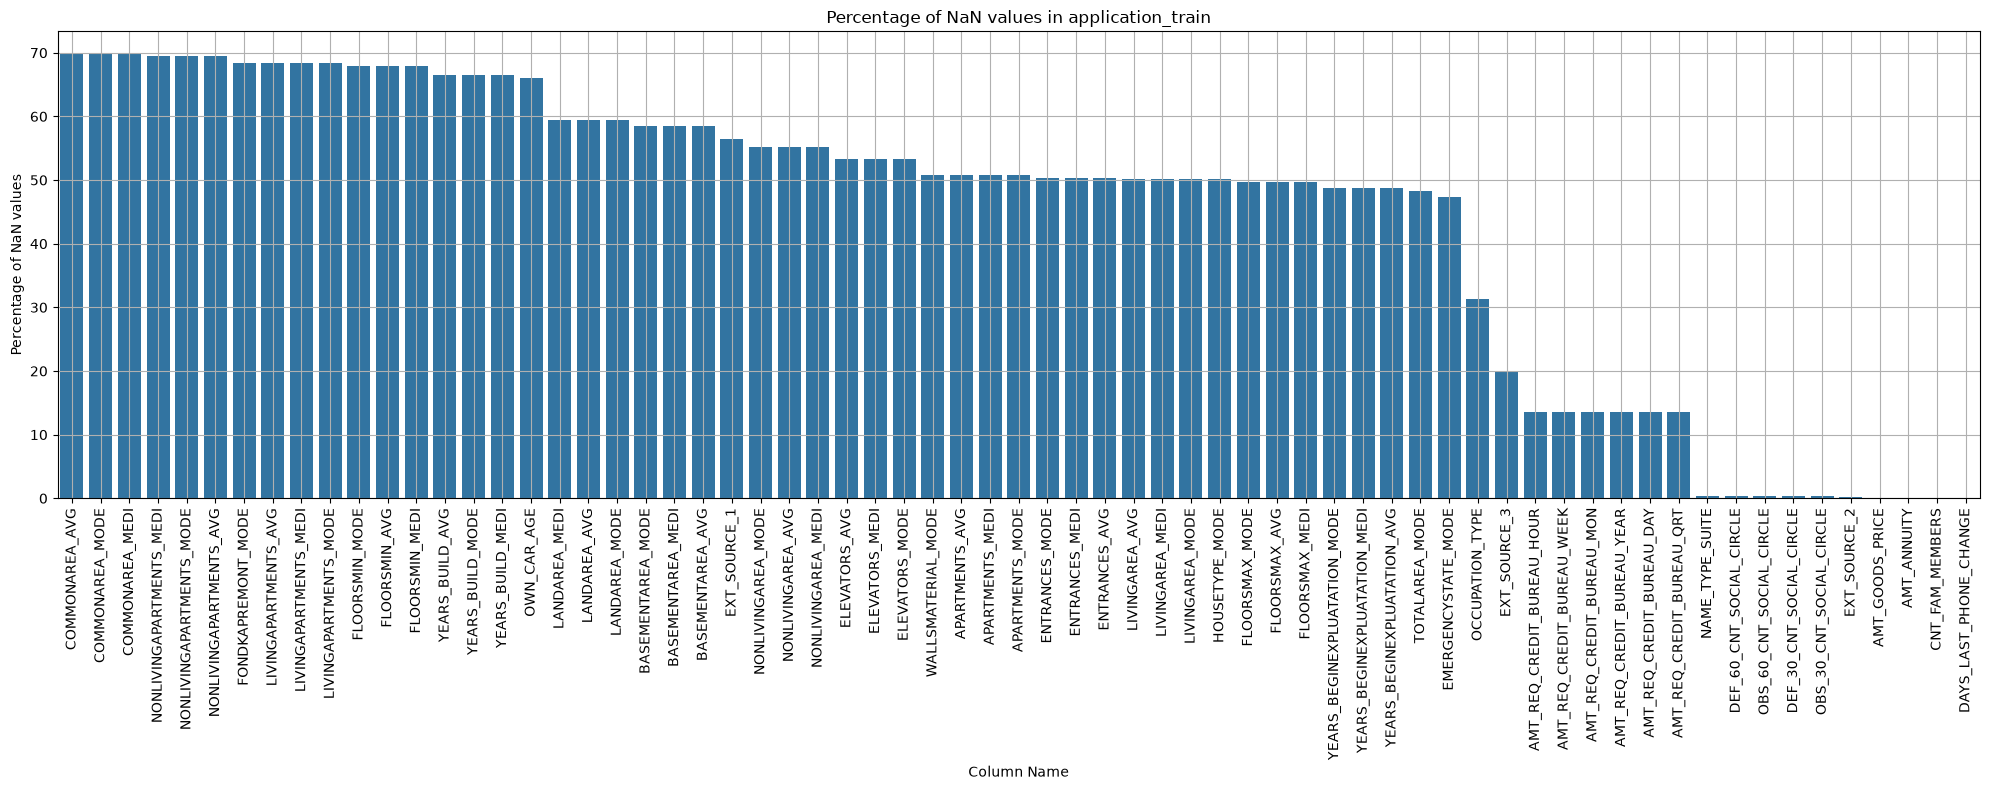

In [ ]:
plot_nan_percent(nan_df_create(application_train), 'application_train', grid = True)

Number of columns having NaN values: 64 columns


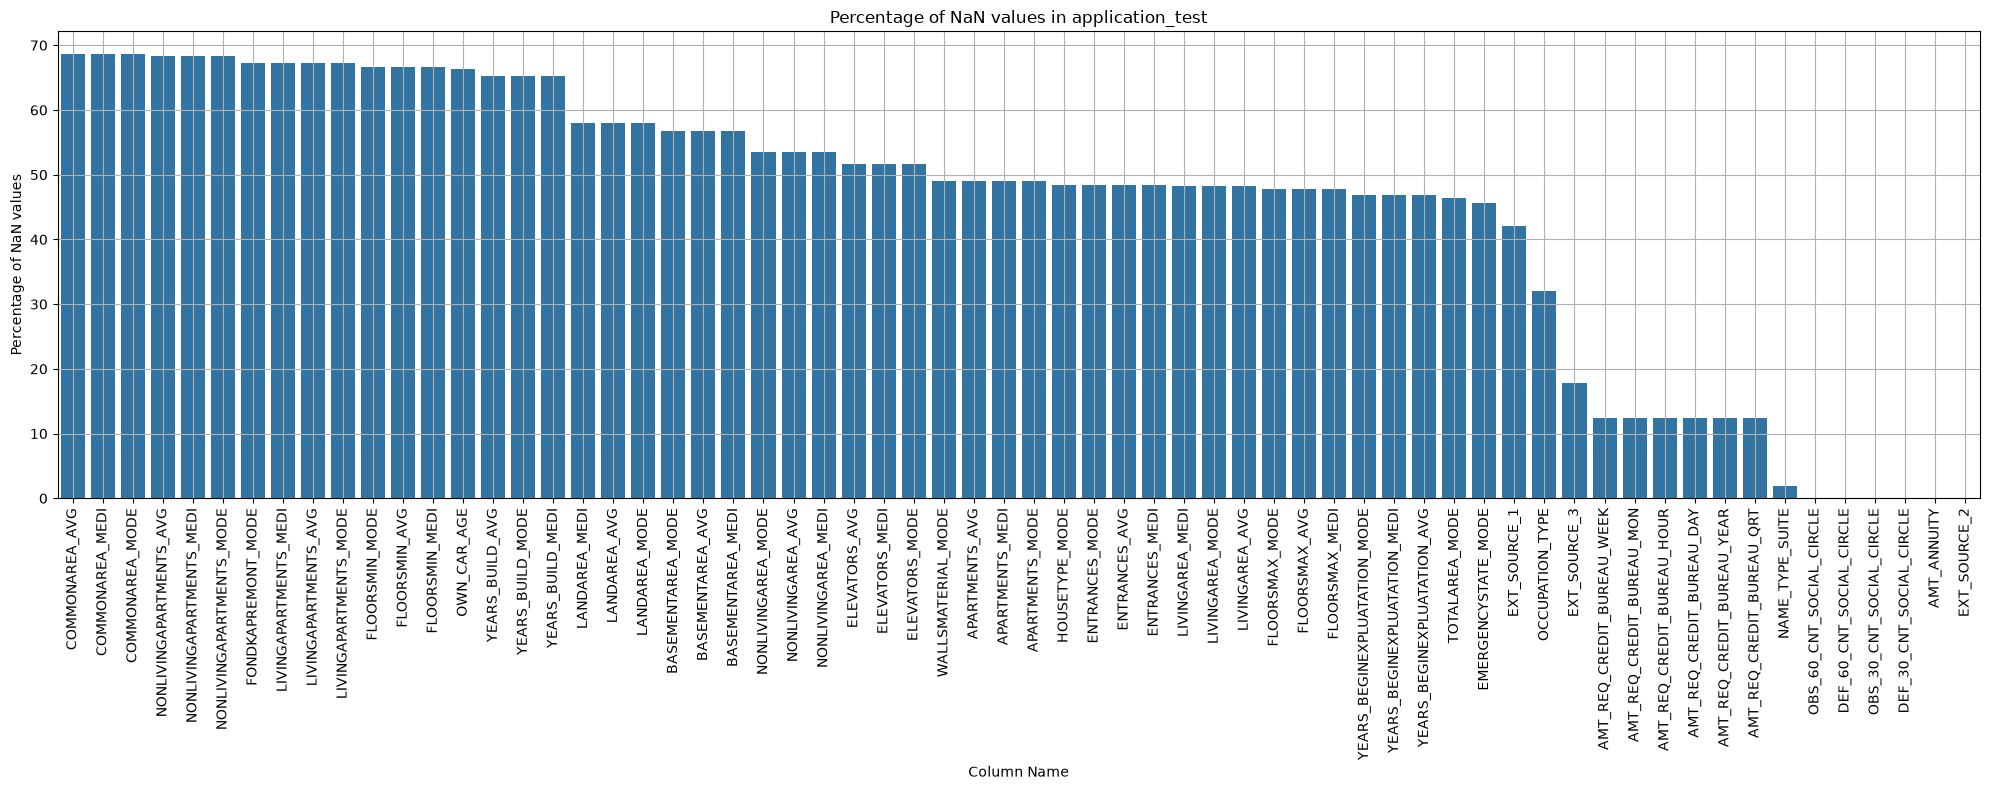

In [ ]:
plot_nan_percent(nan_df_create(application_test), 'application_test', grid = True)

##### Quan sát và Kết luận:

1. application_train.csv:

• Có thể thấy từ biểu đồ phía trên rằng trong tổng số 122 đặc trưng, có 67 cột chứa giá trị NaN (giá trị thiếu). Nếu chỉ có một hoặc hai cột chứa NaN, chúng ta có thể đơn giản loại bỏ các cột đó. Tuy nhiên, với số lượng cột có giá trị thiếu lớn như vậy, chúng ta không thể trực tiếp loại bỏ chúng vì điều này có thể dẫn đến mất mát một lượng thông tin rất lớn.

• Có thể thấy một số cột liên quan đến "COMMONAREA", "NONLIVINGAPARTMENT", v.v. có tỷ lệ giá trị thiếu gần 70%. Vì vậy, chúng ta cần tìm các kỹ thuật phù hợp để xử lý lượng lớn giá trị thiếu này và đánh giá phương pháp nào hoạt động tốt nhất đối với dữ liệu.

• Một điểm khác cần lưu ý là phần lớn các cột có hơn 50% giá trị thiếu đều liên quan đến các thông tin/thống kê về căn hộ của người vay. Có khả năng những thông tin này không được ghi nhận trong quá trình nhập dữ liệu và có thể là các trường thông tin không bắt buộc.

2. application_test.csv:

• Số lượng cột chứa giá trị NaN là 64, khá tương đồng với application_train.csv.

• Tỷ lệ giá trị NaN cũng khá tương đồng với tỷ lệ xuất hiện trong tập dữ liệu huấn luyện. Điều này cho thấy tập train và tập test có phân phối khá giống nhau về khía cạnh giá trị thiếu.


#### Phân phối biến mục tiêu

In [ ]:
import plotly.graph_objects as go

target_distribution = (
    application_train["TARGET"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

labels = ["Non-Defaulter", "Defaulter"]

fig = go.Figure(
    data=[
        go.Pie(
            values=target_distribution.values,
            labels=labels,
            textinfo="label+percent+value",
            pull=[0, 0.04]
        )
    ]
)

fig.update_layout(title="Distribution of Target Variable")
fig.show()

Từ phân phối của biến TARGET, một điều có thể nhanh chóng nhận thấy là tình trạng mất cân bằng dữ liệu (Data Imbalance). Chỉ có khoảng 8,07% tổng số khoản vay thuộc nhóm Default. Điều này có nghĩa Defaulters (nhóm gặp khó khăn trong việc trả nợ) là lớp thiểu số (minority class).
Ngược lại, khoảng 91,9% khoản vay thuộc nhóm không Default. Do đó, Non-Defaulters là lớp đa số (majority class).

Nhóm Defaulters được gán:

TARGET = 1

Trong khi nhóm Non-Defaulters được gán:

TARGET = 0
Đối với dataset mất cân bằng, trong quá trình xây dựng mô hình, chúng ta không thể luôn đưa dữ liệu trực tiếp vào một số thuật toán nhạy cảm với tình trạng mất cân bằng lớp mà không có biện pháp xử lý hoặc điều chỉnh phù hợp.
Tương tự, việc lựa chọn chỉ số đánh giá mô hình (Performance Metrics) cũng cần được cân nhắc. Với dataset mất cân bằng như vậy, Accuracy thường không phải là chỉ số phù hợp, vì nó có thể bị chi phối bởi lớp đa số. Thay vào đó, có thể sử dụng các chỉ số khác như ROC-AUC Score, Log-Loss, F1-Score và Confusion Matrix để đánh giá mô hình tốt hơn.
Một điểm quan trọng khác cần lưu ý là chỉ có một tỷ lệ nhỏ khách hàng thực sự Default và họ có thể thể hiện những hành vi hoặc đặc điểm khác biệt. Vì vậy, trong các bài toán như phát hiện gian lận (Fraud Detection), dự đoán Default và phát hiện bất thường (Anomaly Detection), chúng ta cũng cần chú ý đến outliers và không nên tự động loại bỏ chúng. Một số outlier có thể chính là những quan sát mang thông tin giúp phân biệt giữa Defaulter và Non-Defaulter.

#### Ma trận Phi-K

Chúng ta sẽ vẽ một heatmap (bản đồ nhiệt) thể hiện các giá trị của hệ số tương quan Phi-K (Phi-K Correlation Coefficient) giữa từng đặc trưng với các đặc trưng còn lại.

Hệ số Phi-K tương tự như hệ số tương quan (Correlation Coefficient) thông thường, nhưng điểm khác biệt là Phi-K có thể được sử dụng cho một cặp biến phân loại (categorical features) để kiểm tra xem hai biến phân loại có mức độ liên hệ với nhau hay không.

Giá trị lớn nhất của Phi-K là 1. Giá trị càng gần 1 cho thấy mức độ liên hệ giữa hai biến càng mạnh.

----------------------------------------------------------------------------------------------------


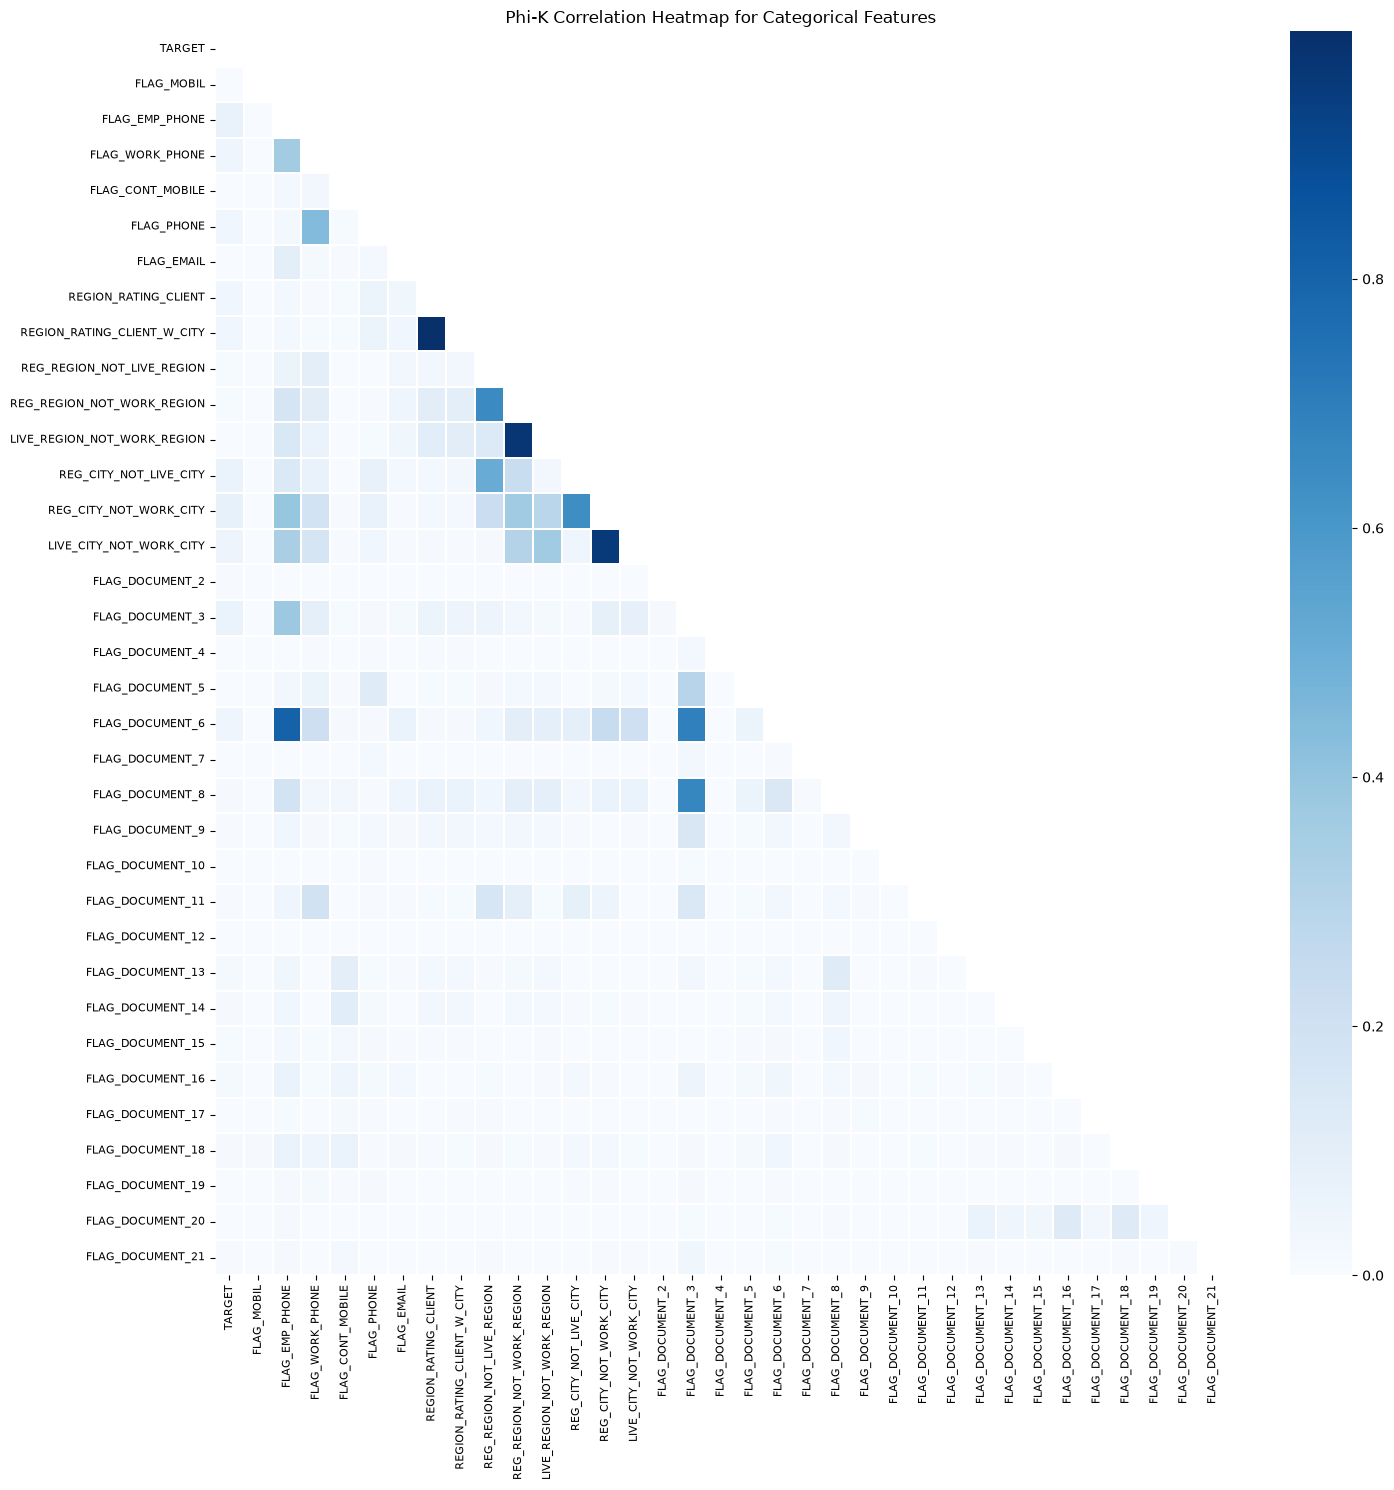

----------------------------------------------------------------------------------------------------
Categories with highest values of Phi-K Correlation value with Target Variable are:


,Column Name,Phik-Correlation
12,REG_CITY_NOT_WORK_CITY,0.079946
1,FLAG_EMP_PHONE,0.072087
11,REG_CITY_NOT_LIVE_CITY,0.069588
15,FLAG_DOCUMENT_3,0.069525
13,LIVE_CITY_NOT_WORK_CITY,0.050956
18,FLAG_DOCUMENT_6,0.044791
2,FLAG_WORK_PHONE,0.044678
4,FLAG_PHONE,0.037258
7,REGION_RATING_CLIENT_W_CITY,0.036699
6,REGION_RATING_CLIENT,0.035450


----------------------------------------------------------------------------------------------------


In [ ]:
categorical_columns = ['TARGET','FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE',
                                   'FLAG_PHONE', 'FLAG_EMAIL','REGION_RATING_CLIENT','REGION_RATING_CLIENT_W_CITY',
                                  'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
                                   'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 
                                'LIVE_CITY_NOT_WORK_CITY'] + ['FLAG_DOCUMENT_' + str(i) for i in range(2,22)] + application_train.dtypes[
                                    application_train.dtypes == 'object'].index.tolist()
plot_phik_matrix(application_train, categorical_columns, figsize = (15,15), fontsize = 8)

##### Quan sát và Kết luận:

1. Từ heatmap hệ số tương quan Phi-K ở trên, chúng ta có thể thấy rằng phần lớn các đặc trưng phân loại (categorical features) không có mối tương quan mạnh với nhau. Tuy nhiên, một số đặc trưng lại thể hiện mức độ tương quan cao.

2. Một số cặp/nhóm biến phân loại có mức tương quan cao bao gồm:
   • REGION_RATING_CLIENT_W_CITY và REGION_RATING_CLIENT – Điều này khá dễ hiểu vì hai biến này ít nhiều phản ánh những thông tin tương tự nhau.
   • LIVE_REGION_NOT_WORK_REGION và REG_REGION_NOT_WORK_REGION.
   • NAME_INCOME_TYPE, ORGANIZATION_TYPE và FLAG_EMP_PHONE.

3. Chúng ta cũng có thể thấy một mức độ tương quan nhất định giữa loại hình tổ chức nơi khách hàng làm việc (ORGANIZATION_TYPE) và loại thu nhập của khách hàng (NAME_INCOME_TYPE). Tương tự, OCCUPATION_TYPE (loại nghề nghiệp) cũng có tương quan với ORGANIZATION_TYPE.

4. Các biến OCCUPATION_TYPE, ORGANIZATION_TYPE, NAME_INCOME_TYPE và REG_CITY_NOT_WORK_CITY là một số biến phân loại có mức độ tương quan cao nhất với biến TARGET. Vì vậy, các biến này có thể đóng vai trò quan trọng trong bài toán phân loại và cần được thực hiện EDA sâu hơn.


# ### Ma trận tương quan của các tính năng

Chúng ta sẽ vẽ một heatmap (bản đồ nhiệt) thể hiện mức độ tương quan của từng đặc trưng số (numeric feature) với các đặc trưng số còn lại.

Cột SK_ID_CURR được loại khỏi quá trình phân tích vì đây chỉ là mã định danh của hồ sơ/khách hàng, do đó không mang ý nghĩa dự đoán trong phân tích tương quan.

Heatmap này sẽ giúp chúng ta:

Xác định các đặc trưng số có mức tương quan cao với nhau.
Đồng thời xác định những đặc trưng có mức tương quan cao với biến mục tiêu (TARGET), từ đó nhận diện các biến có khả năng hữu ích cho bài toán dự đoán.

In [20]:
columns_to_drop = ["SK_ID_CURR"] + list(
    set(categorical_columns) - {"TARGET"}
)

corr_data = (
    application_train
    .drop(columns=columns_to_drop + ["TARGET"], errors="ignore")
    .corr(numeric_only=True)
)

NameError: name 'categorical_columns' is not defined

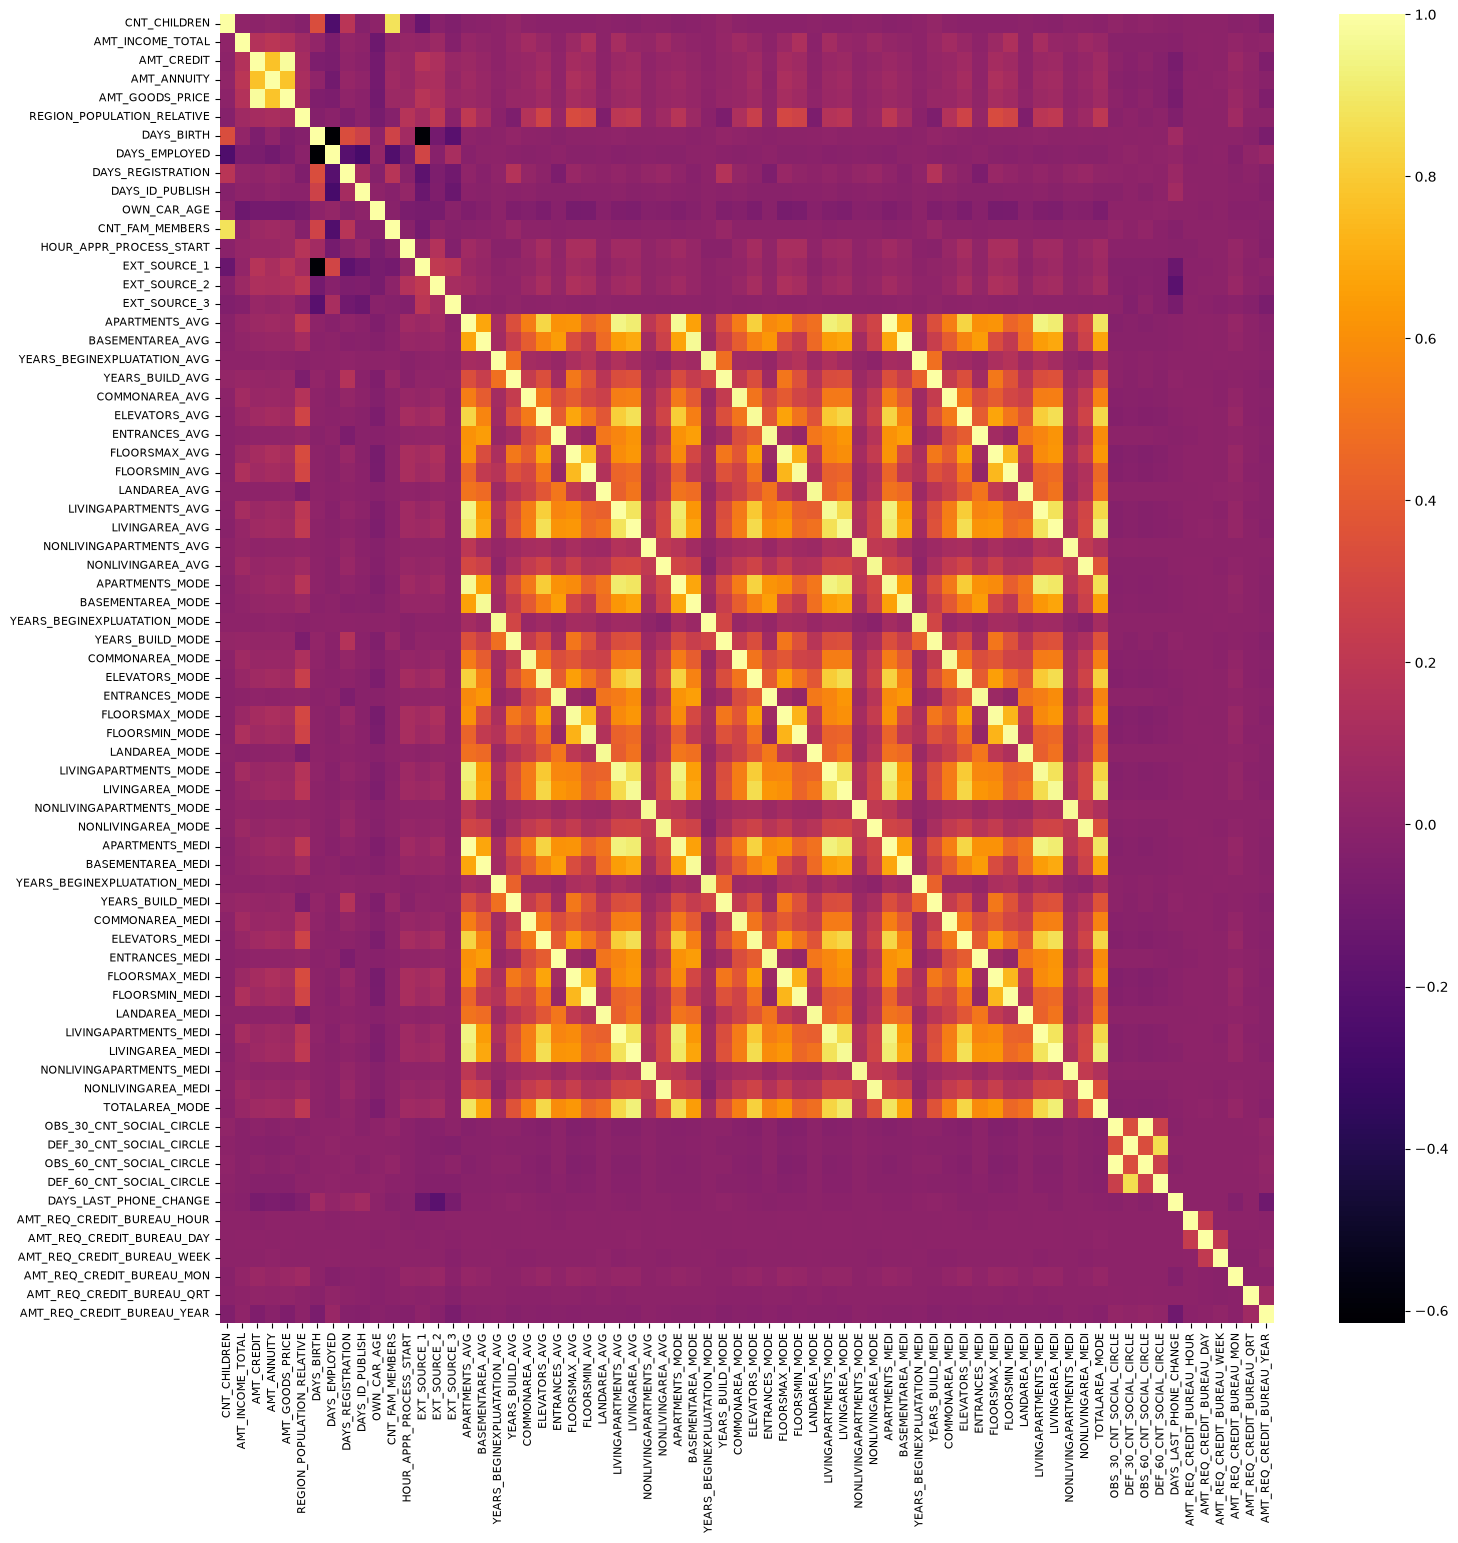

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(17, 17))
sns.heatmap(corr_data, cmap="inferno")
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

Quan sát và Kết luận
Heatmap thể hiện khá rõ giá trị hay mức độ tương quan của từng đặc trưng với tất cả các đặc trưng còn lại.
Có thể quan sát thấy phần lớn heatmap có màu tím, biểu thị mức tương quan rất thấp. Điều này cho thấy phần lớn các đặc trưng không có tương quan mạnh với nhau.

Tuy nhiên, ở khu vực giữa heatmap xuất hiện những vùng màu tương phản hơn, cho thấy mức tương quan cao giữa một số đặc trưng. Đây chủ yếu là các đặc trưng liên quan đến thông tin/thống kê về căn hộ (apartment statistics).

Nếu xem các đặc trưng trong application_train, có thể thấy thông tin về căn hộ được cung cấp dưới các dạng Mean (trung bình), Median (trung vị) và Mode (giá trị xuất hiện nhiều nhất). Vì vậy, có thể kỳ vọng các đặc trưng này sẽ có tương quan với nhau.

Ngoài ra, các đặc trưng thuộc cùng một nhóm cũng có thể tương quan với nhau. Ví dụ, các đặc trưng dạng Mean liên quan đến số lượng thang máy (Number of Elevators), diện tích sinh hoạt (Living Area), diện tích không dùng để ở (Non-Living Area), diện tích tầng hầm (Basement Area),... cũng có thể có tương quan với nhau.

Chúng ta cũng quan sát thấy mức tương quan cao giữa:
AMT_GOODS_PRICE và AMT_CREDIT.
DAYS_EMPLOYED và DAYS_BIRTH.
Chúng ta thường không muốn có quá nhiều đặc trưng tương quan cao với nhau, vì chúng có thể làm tăng độ phức tạp và thời gian tính toán của mô hình mà không bổ sung nhiều thông tin mới. Vì vậy, tác giả đề xuất loại bỏ một số đặc trưng có tương quan cao với nhau.
Trong số các đặc trưng, nhóm EXT_SOURCE cho thấy mức tương quan đáng chú ý với biến mục tiêu TARGET. Vì vậy, các đặc trưng này có thể đóng vai trò quan trọng trong bài toán phân loại.

# ### TRỰC QUAN % TỈ LỆ MISSING VALUE Ở CÁC BẢNG CÒN LẠI 

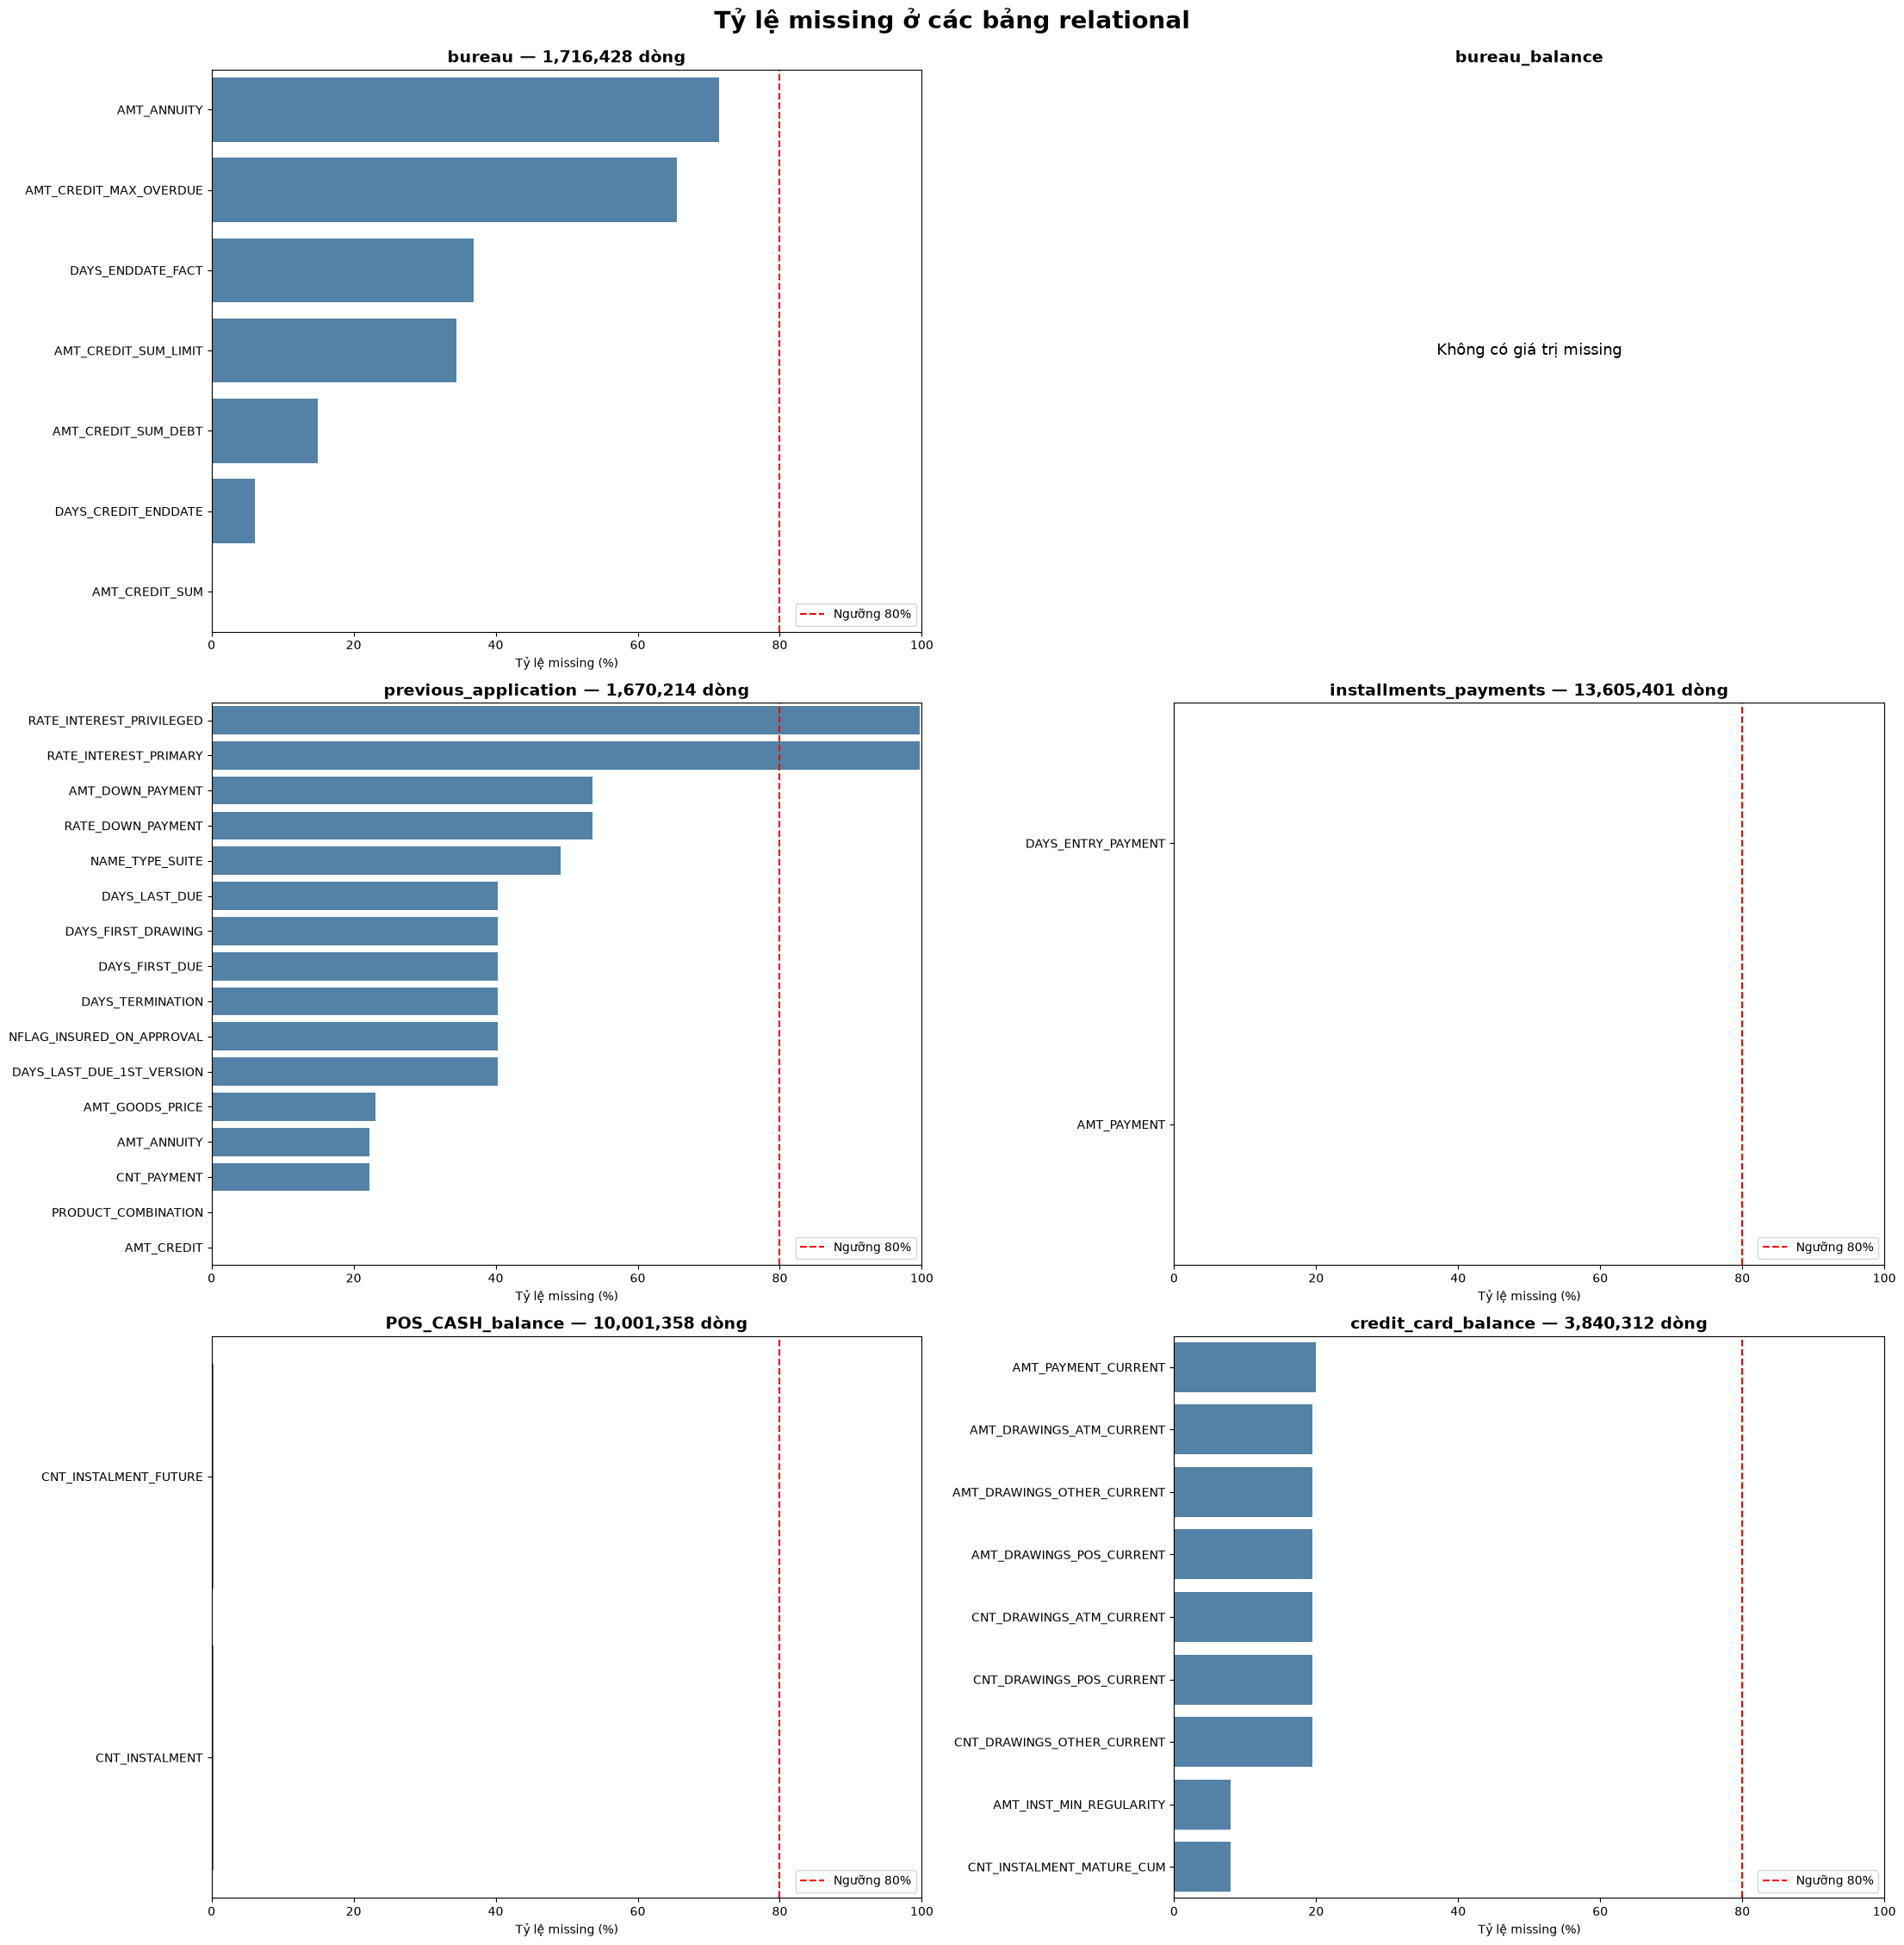

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Các bảng ngoài application_train và application_test
tables = {
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_application,
    "installments_payments": installments_payments,
    "POS_CASH_balance": POS_CASH_balance,
    "credit_card_balance": cc_balance
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(22, 22),
    constrained_layout=True
)

axes = axes.flatten()

for ax, (table_name, df) in zip(axes, tables.items()):
    missing_df = (
        df.isna()
        .mean()
        .mul(100)
        .reset_index()
    )
    missing_df.columns = ["feature", "missing_percent"]

    # Chỉ trực quan các cột thực sự có missing
    missing_df = (
        missing_df[missing_df["missing_percent"] > 0]
        .sort_values("missing_percent", ascending=False)
    )

    if missing_df.empty:
        ax.text(
            0.5, 0.5,
            "Không có giá trị missing",
            ha="center",
            va="center",
            fontsize=13
        )
        ax.set_title(table_name, fontsize=14, fontweight="bold")
        ax.axis("off")
        continue

    sns.barplot(
        data=missing_df,
        x="missing_percent",
        y="feature",
        ax=ax,
        color="steelblue"
    )

    # Đường đánh dấu ngưỡng loại feature 80%
    ax.axvline(
        x=80,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Ngưỡng 80%"
    )

    ax.set_title(
        f"{table_name} — {len(df):,} dòng",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel("Tỷ lệ missing (%)")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)
    ax.legend(loc="lower right")

plt.suptitle(
    "Tỷ lệ missing ở các bảng relational",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.show()

In [52]:
missing_summary = []

for table_name, df in tables.items():
    missing = df.isna().mean().mul(100)

    for column, percentage in missing[missing > 0].items():
        missing_summary.append({
            "table": table_name,
            "feature": column,
            "missing_percent": percentage
            
        })

missing_summary = (
    pd.DataFrame(missing_summary)
    .sort_values(
        ["table", "missing_percent"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

display(
    missing_summary.style
    .format({"missing_percent": "{:.2f}%"})
    .background_gradient(
        subset=["missing_percent"],
        cmap="Reds"
    )
)

,table,feature,missing_percent
0,POS_CASH_balance,CNT_INSTALMENT_FUTURE,0.26%
1,POS_CASH_balance,CNT_INSTALMENT,0.26%
2,bureau,AMT_ANNUITY,71.47%
3,bureau,AMT_CREDIT_MAX_OVERDUE,65.51%
4,bureau,DAYS_ENDDATE_FACT,36.92%
5,bureau,AMT_CREDIT_SUM_LIMIT,34.48%
6,bureau,AMT_CREDIT_SUM_DEBT,15.01%
7,bureau,DAYS_CREDIT_ENDDATE,6.15%
8,bureau,AMT_CREDIT_SUM,0.00%
9,credit_card_balance,AMT_PAYMENT_CURRENT,20.00%


# ### VẼ HEATMAP CHO TỪNG BẢNG 

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tables = {
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_application,
    "installments_payments": installments_payments,
    "POS_CASH_balance": POS_CASH_balance,
    "credit_card_balance": cc_balance
}

ID_COLUMNS = {
    "SK_ID_CURR",
    "SK_ID_PREV",
    "SK_ID_BUREAU"
}

def plot_numeric_correlation_heatmap(
    df,
    table_name,
    method="spearman",
    figsize=(14, 10),
    min_abs_correlation=0.0
):
    # Chỉ lấy biến số, loại các cột định danh
    numeric_df = (
        df.select_dtypes(include=np.number)
        .drop(
            columns=[
                col for col in ID_COLUMNS
                if col in df.columns
            ],
            errors="ignore"
        )
    )

    # Loại cột hằng số vì không thể tính correlation Nougat
    constant_columns = [
        col for col in numeric_df.columns
        if numeric_df[col].nunique(dropna=True) <= 1
    ]
    numeric_df = numeric_df.drop(columns=constant_columns)

    if numeric_df.shape[1] < 2:
        print(
            f"{table_name}: Không đủ biến số để tính ma trận tương quan."
        )
        return

    corr = numeric_df.corr(method=method)

    # Có thể ẩn các tương quan yếu để heatmap dễ đọc hơn
    display_corr = corr.mask(
        (corr.abs() < min_abs_correlation) &
        (~np.eye(len(corr), dtype=bool))
    )

    # Chỉ hiển thị nửa dưới để tránh lặp thông tin
    upper_triangle = np.triu(
        np.ones_like(display_corr, dtype=bool),
        k=1
    )

    plt.figure(figsize=figsize)

    sns.heatmap(
        display_corr,
        mask=upper_triangle,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.4,
        cbar_kws={"label": f"{method.title()} correlation"}
    )

    plt.title(
        f"Ma trận tương quan {method.title()} — {table_name}",
        fontsize=16,
        fontweight="bold"
    )
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return corr

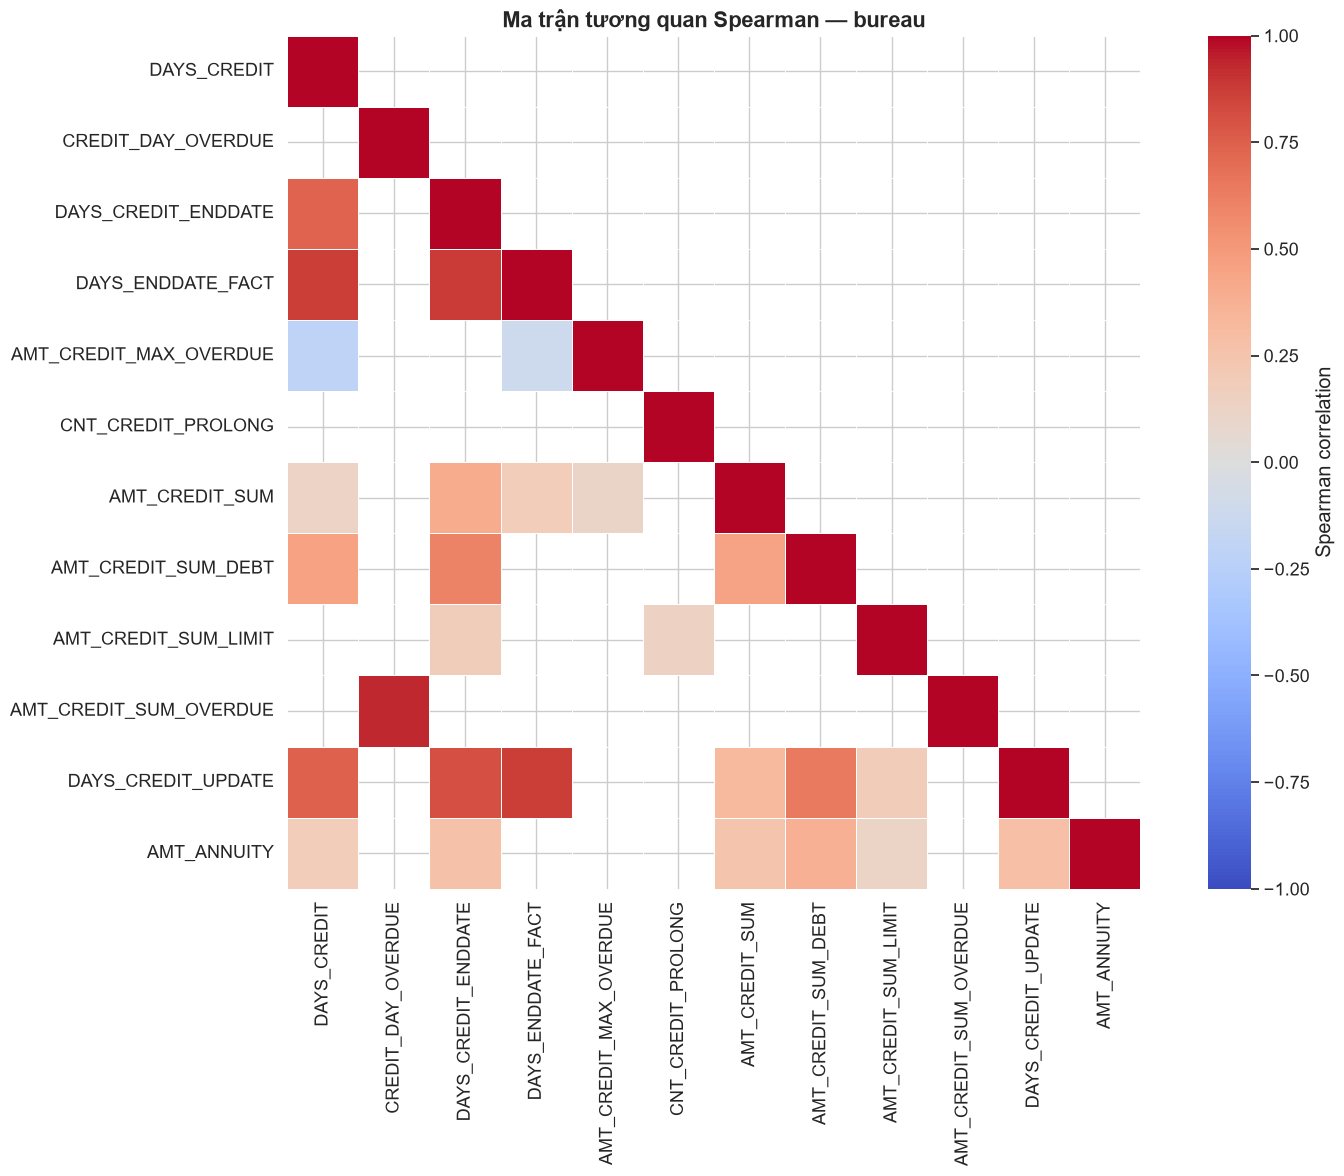

bureau_balance: Không đủ biến số để tính ma trận tương quan.


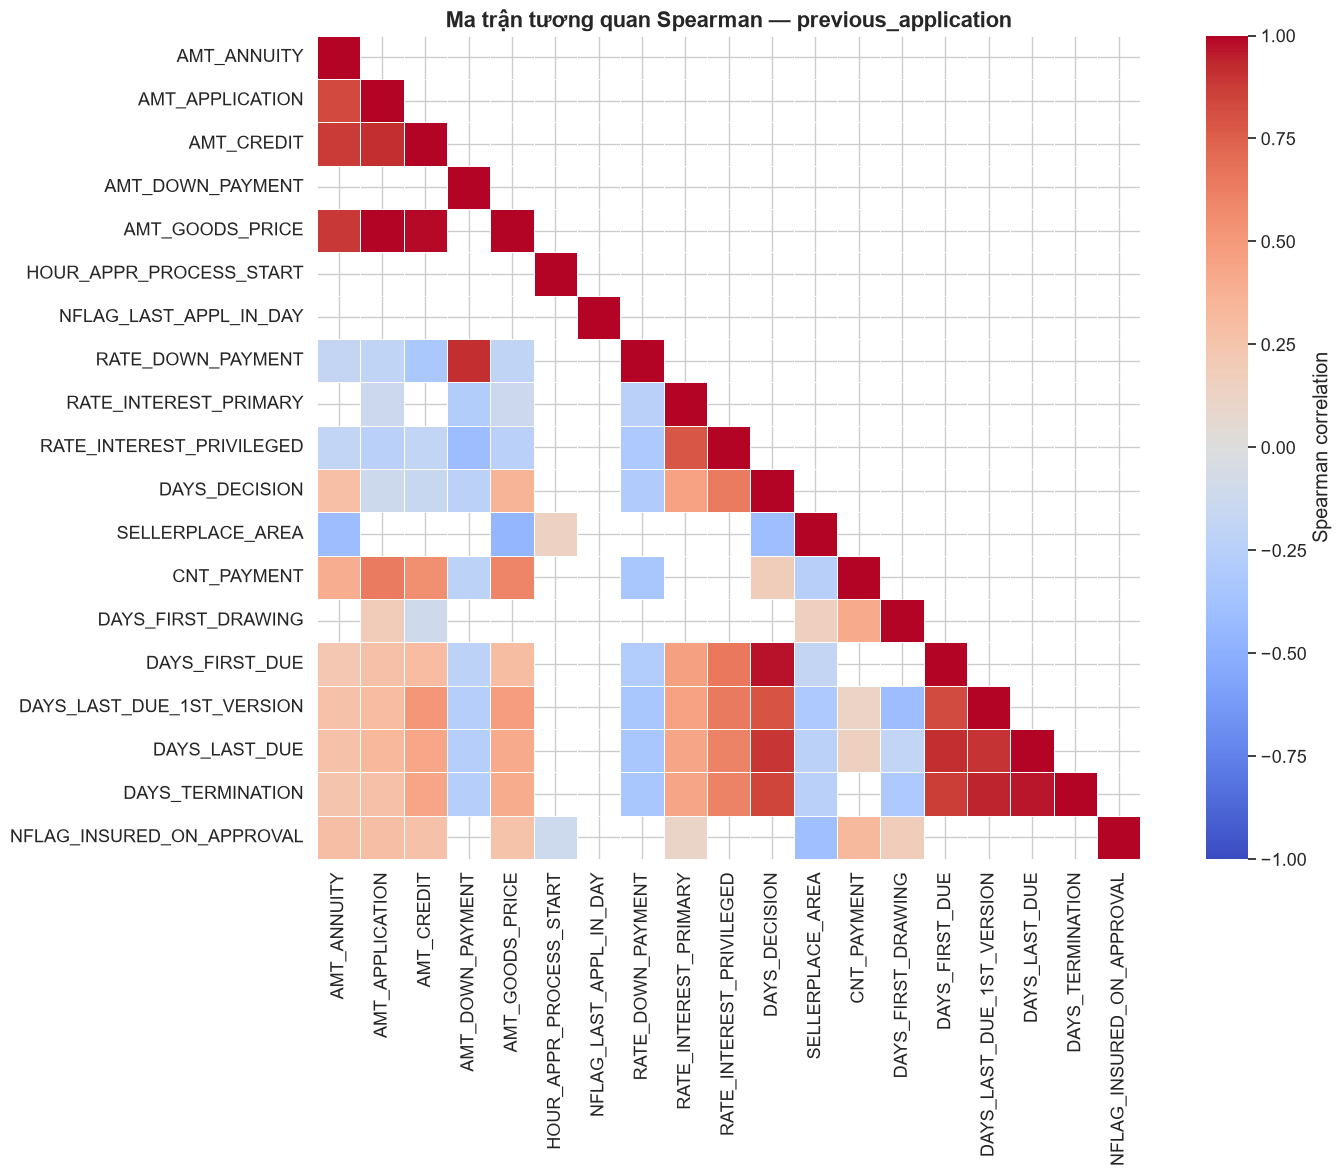

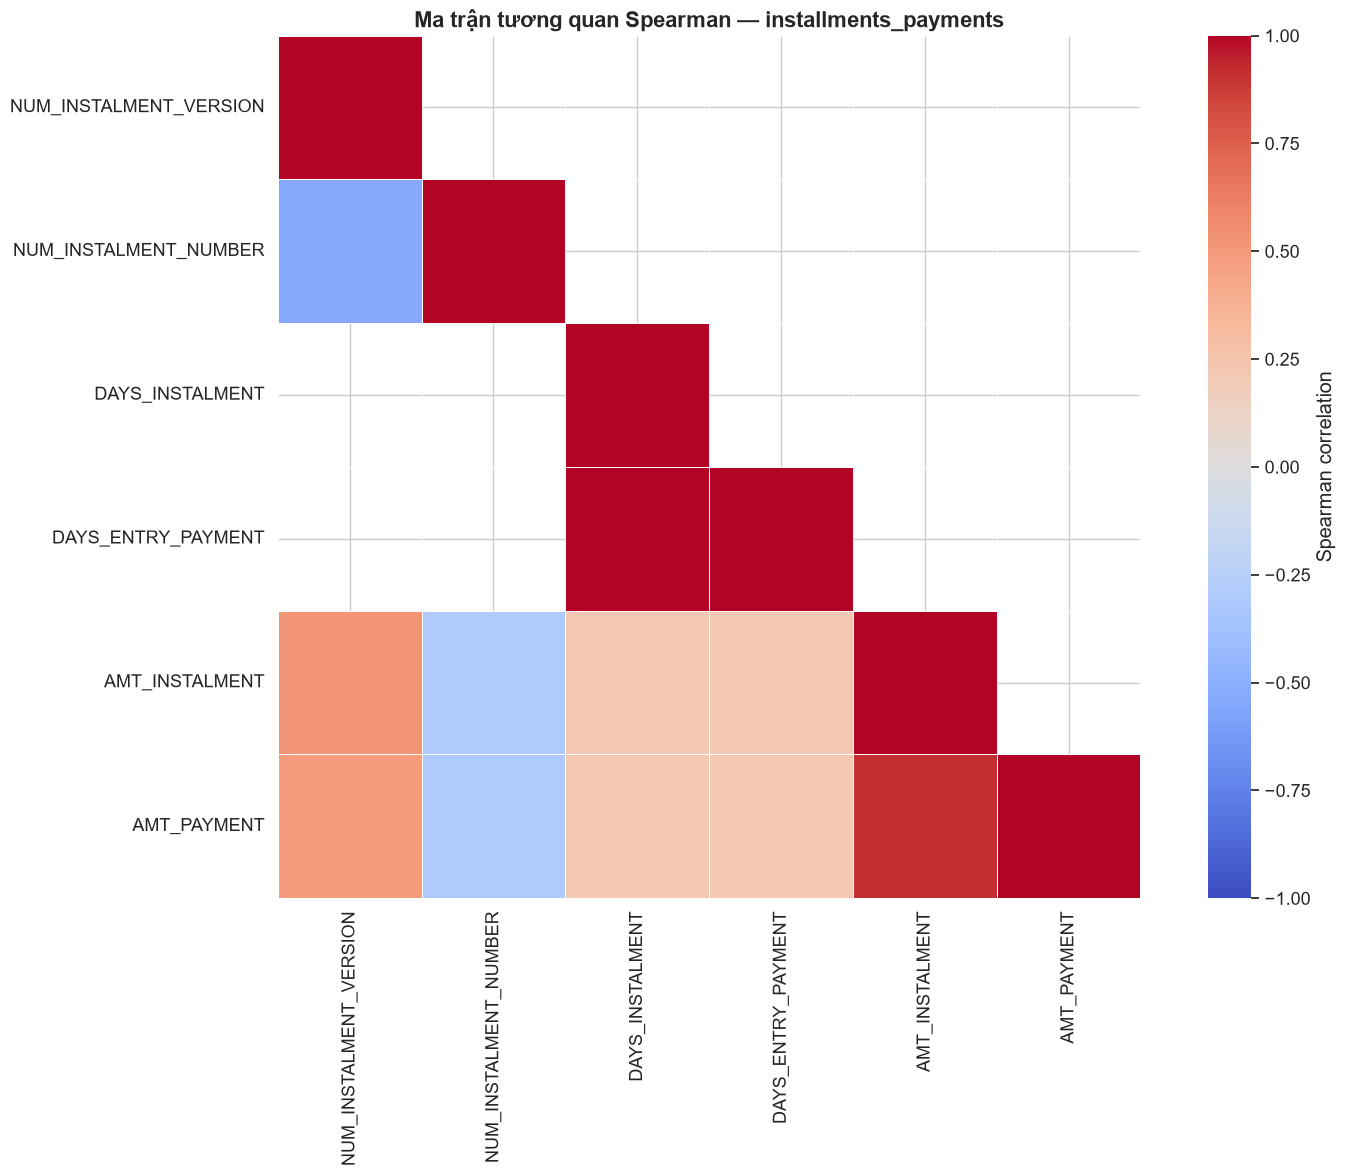

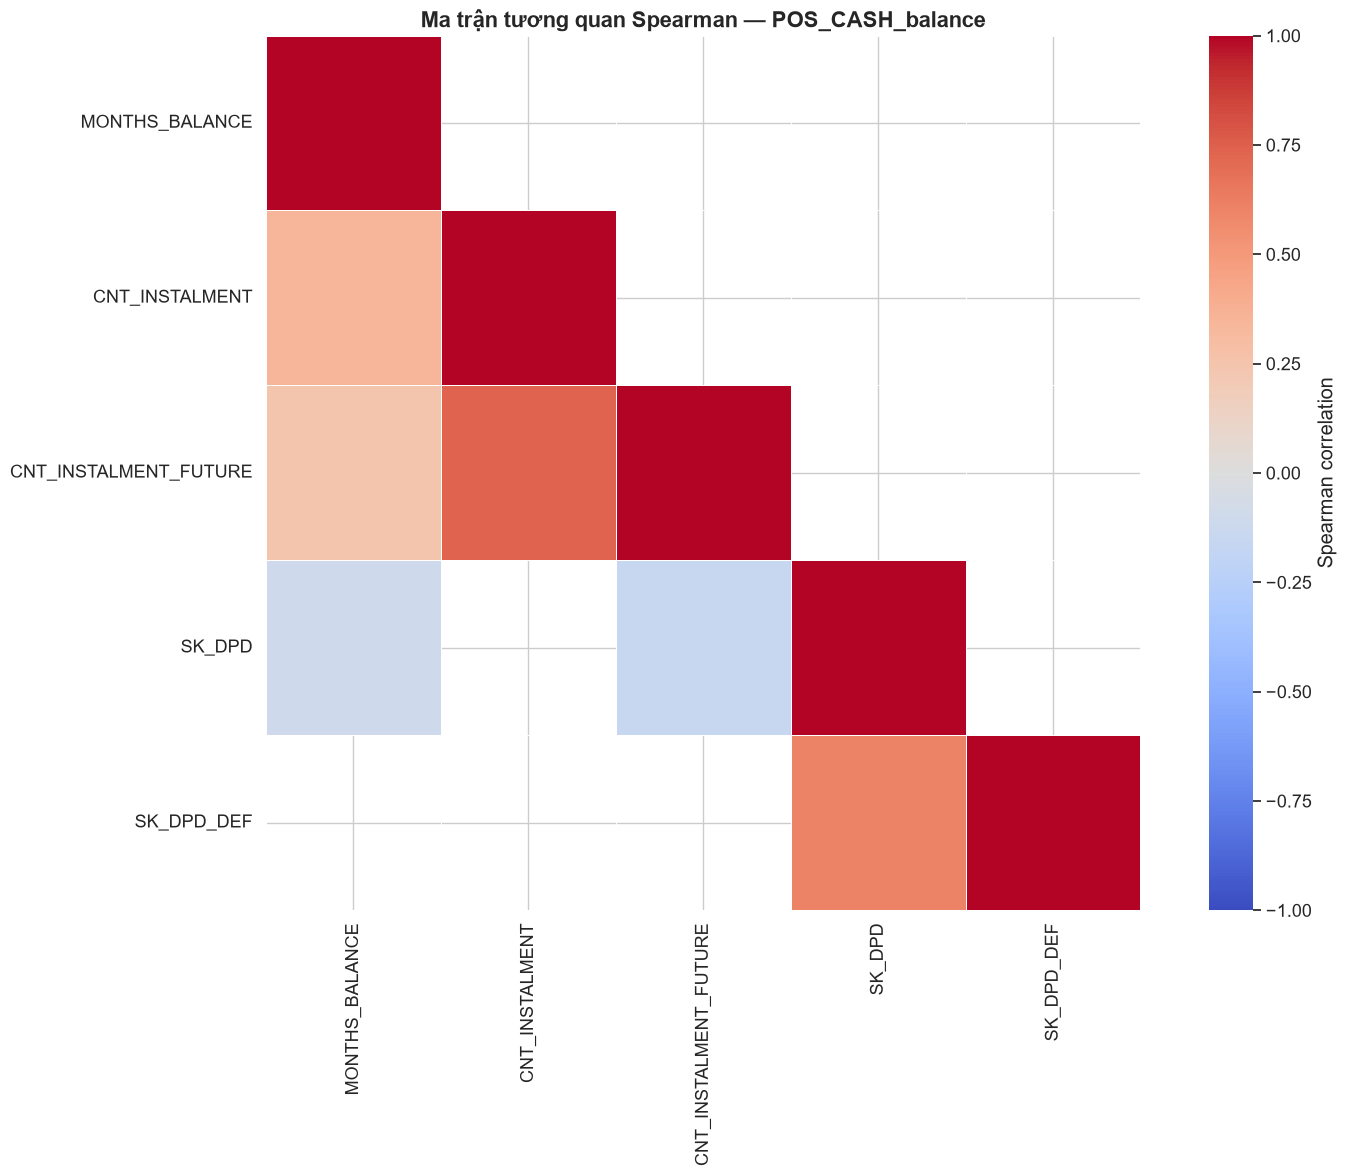

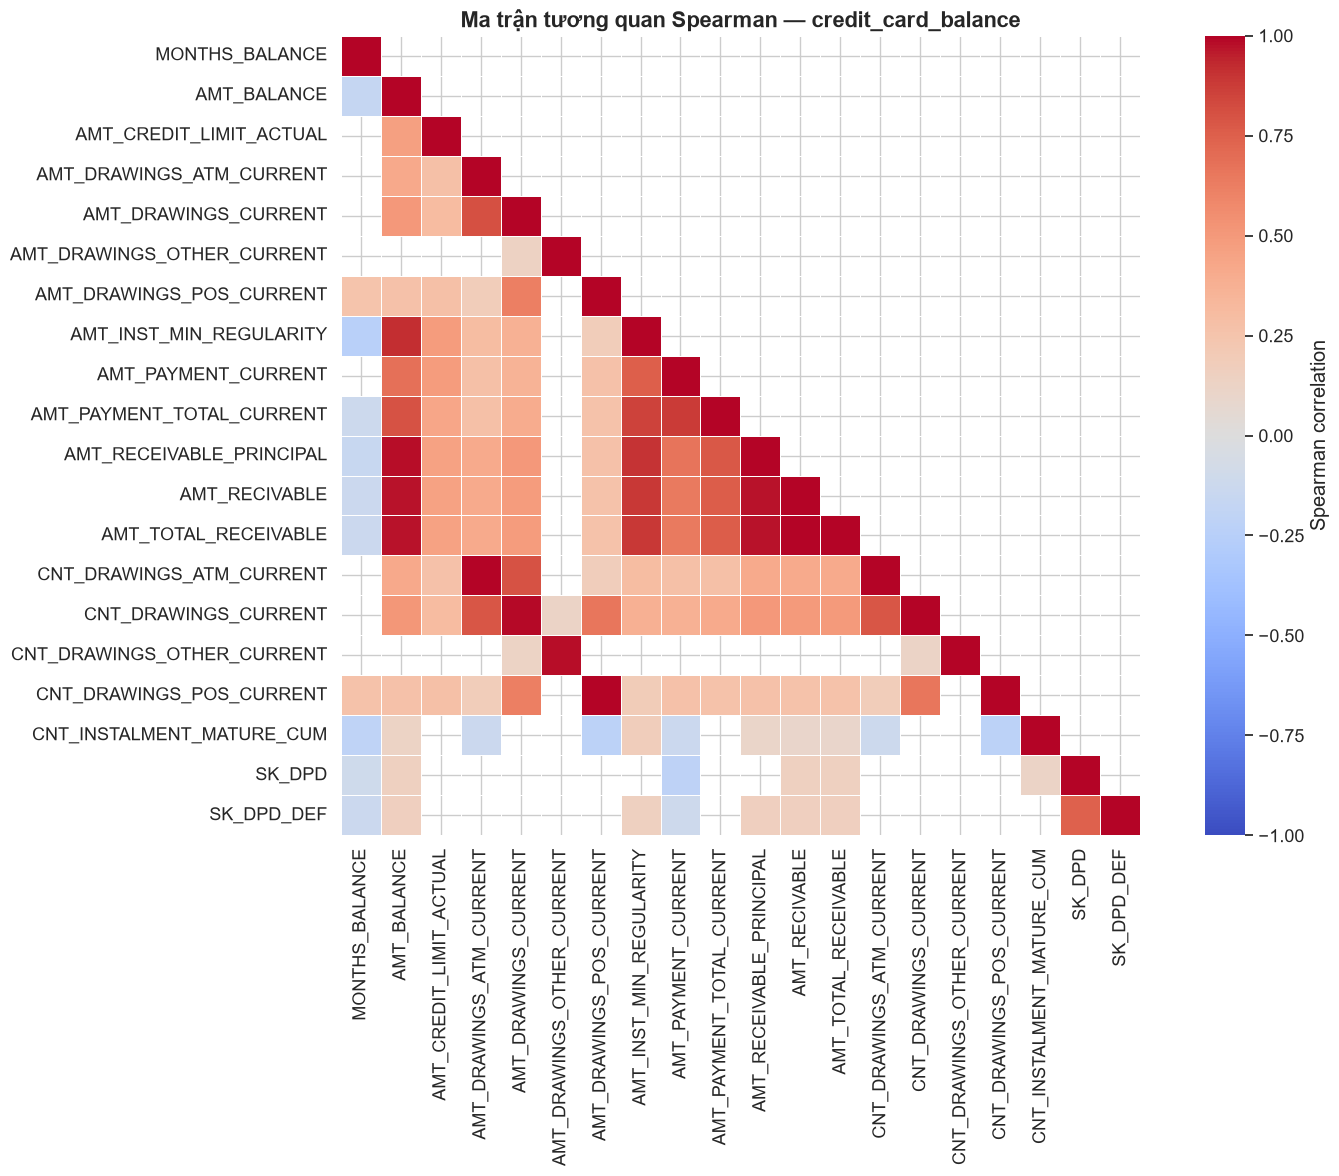

In [54]:
correlation_matrices = {}

for table_name, df in tables.items():
    correlation_matrices[table_name] = (
        plot_numeric_correlation_heatmap(
            df=df,
            table_name=table_name,
            method="spearman",
            figsize=(16, 12),
            min_abs_correlation=0.10
        )
    )

LIỆT KÊ CÁC CẶP TƯƠNG QUAN MẠNH

In [55]:
def get_high_correlation_pairs(corr, threshold=0.7):
    if corr is None:
        return pd.DataFrame()

    upper_mask = np.triu(
        np.ones(corr.shape, dtype=bool),
        k=1
    )

    pairs = (
        corr.where(upper_mask)
        .stack()
        .reset_index()
    )

    pairs.columns = [
        "feature_1",
        "feature_2",
        "correlation"
    ]

    return (
        pairs[
            pairs["correlation"].abs() >= threshold
        ]
        .assign(
            absolute_correlation=lambda x:
                x["correlation"].abs()
        )
        .sort_values(
            "absolute_correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [56]:
for table_name, corr in correlation_matrices.items():
    print(f"\nCác cặp tương quan mạnh trong {table_name}:")

    display(
        get_high_correlation_pairs(
            corr,
            threshold=0.7
        )
    )


Các cặp tương quan mạnh trong bureau:


,feature_1,feature_2,correlation,absolute_correlation
0,CREDIT_DAY_OVERDUE,AMT_CREDIT_SUM_OVERDUE,0.933708,0.933708
1,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,0.880629,0.880629
2,DAYS_CREDIT,DAYS_ENDDATE_FACT,0.873758,0.873758
3,DAYS_ENDDATE_FACT,DAYS_CREDIT_UPDATE,0.871854,0.871854
4,DAYS_CREDIT_ENDDATE,DAYS_CREDIT_UPDATE,0.809760,0.809760
5,DAYS_CREDIT,DAYS_CREDIT_UPDATE,0.743959,0.743959
6,DAYS_CREDIT,DAYS_CREDIT_ENDDATE,0.741778,0.741778



Các cặp tương quan mạnh trong bureau_balance:


""



Các cặp tương quan mạnh trong previous_application:


...

,feature_1,feature_2,correlation,absolute_correlation
0,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,0.999402,0.999402
1,AMT_INSTALMENT,AMT_PAYMENT,0.916463,0.916463



Các cặp tương quan mạnh trong POS_CASH_balance:


,feature_1,feature_2,correlation,absolute_correlation
0,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,0.740763,0.740763



Các cặp tương quan mạnh trong credit_card_balance:


,feature_1,feature_2,correlation,absolute_correlation
0,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,0.999965,0.999965
1,AMT_DRAWINGS_POS_CURRENT,CNT_DRAWINGS_POS_CURRENT,0.998779,0.998779
2,AMT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_ATM_CURRENT,0.997019,0.997019
3,AMT_DRAWINGS_CURRENT,CNT_DRAWINGS_CURRENT,0.989757,0.989757
4,AMT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,0.981215,0.981215
5,AMT_BALANCE,AMT_RECEIVABLE_PRINCIPAL,0.977144,0.977144
6,AMT_BALANCE,AMT_TOTAL_RECEIVABLE,0.971200,0.971200
7,AMT_BALANCE,AMT_RECIVABLE,0.971191,0.971191
8,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,0.970944,0.970944
9,AMT_RECEIVABLE_PRINCIPAL,AMT_TOTAL_RECEIVABLE,0.970912,0.970912


# ### Vẽ đồ thị các biến phân loại

In [57]:
from phik import phik_matrix

def plot_phik_heatmap(
    df,
    table_name,
    sample_size=100_000,
    max_features=40
):
    data = df.drop(
        columns=[
            col for col in ID_COLUMNS
            if col in df.columns
        ],
        errors="ignore"
    ).copy()

    # Giới hạn số dòng để tránh hết RAM
    if len(data) > sample_size:
        data = data.sample(
            n=sample_size,
            random_state=42
        )

    # Ưu tiên các cột không quá nhiều missing
    missing_rate = data.isna().mean()
    selected_columns = (
        missing_rate
        .sort_values()
        .head(max_features)
        .index
    )

    data = data[selected_columns]

    interval_columns = (
        data.select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    phik_corr = data.phik_matrix(
        interval_cols=interval_columns
    )

    mask = np.triu(
        np.ones_like(phik_corr, dtype=bool),
        k=1
    )

    plt.figure(figsize=(16, 13))

    sns.heatmap(
        phik_corr,
        mask=mask,
        cmap="Blues",
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"label": "Phi-K"}
    )

    plt.title(
        f"Phi-K correlation — {table_name}",
        fontsize=16,
        fontweight="bold"
    )
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return phik_corr

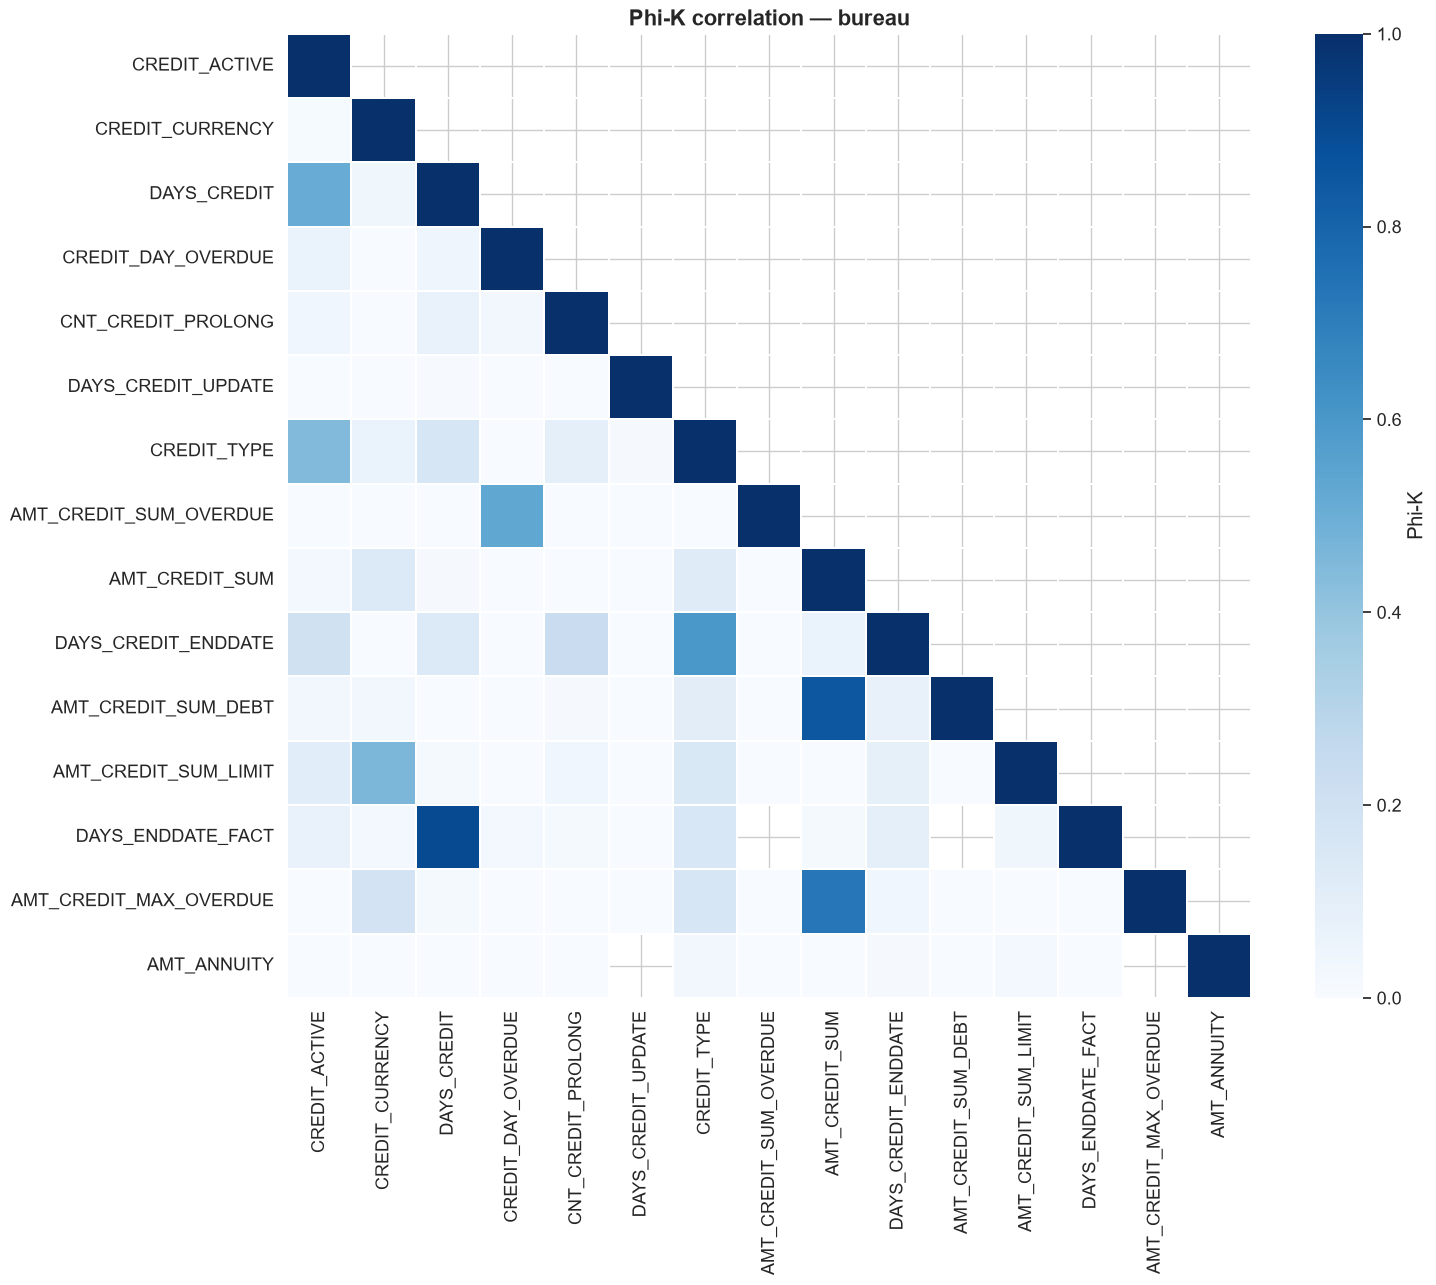

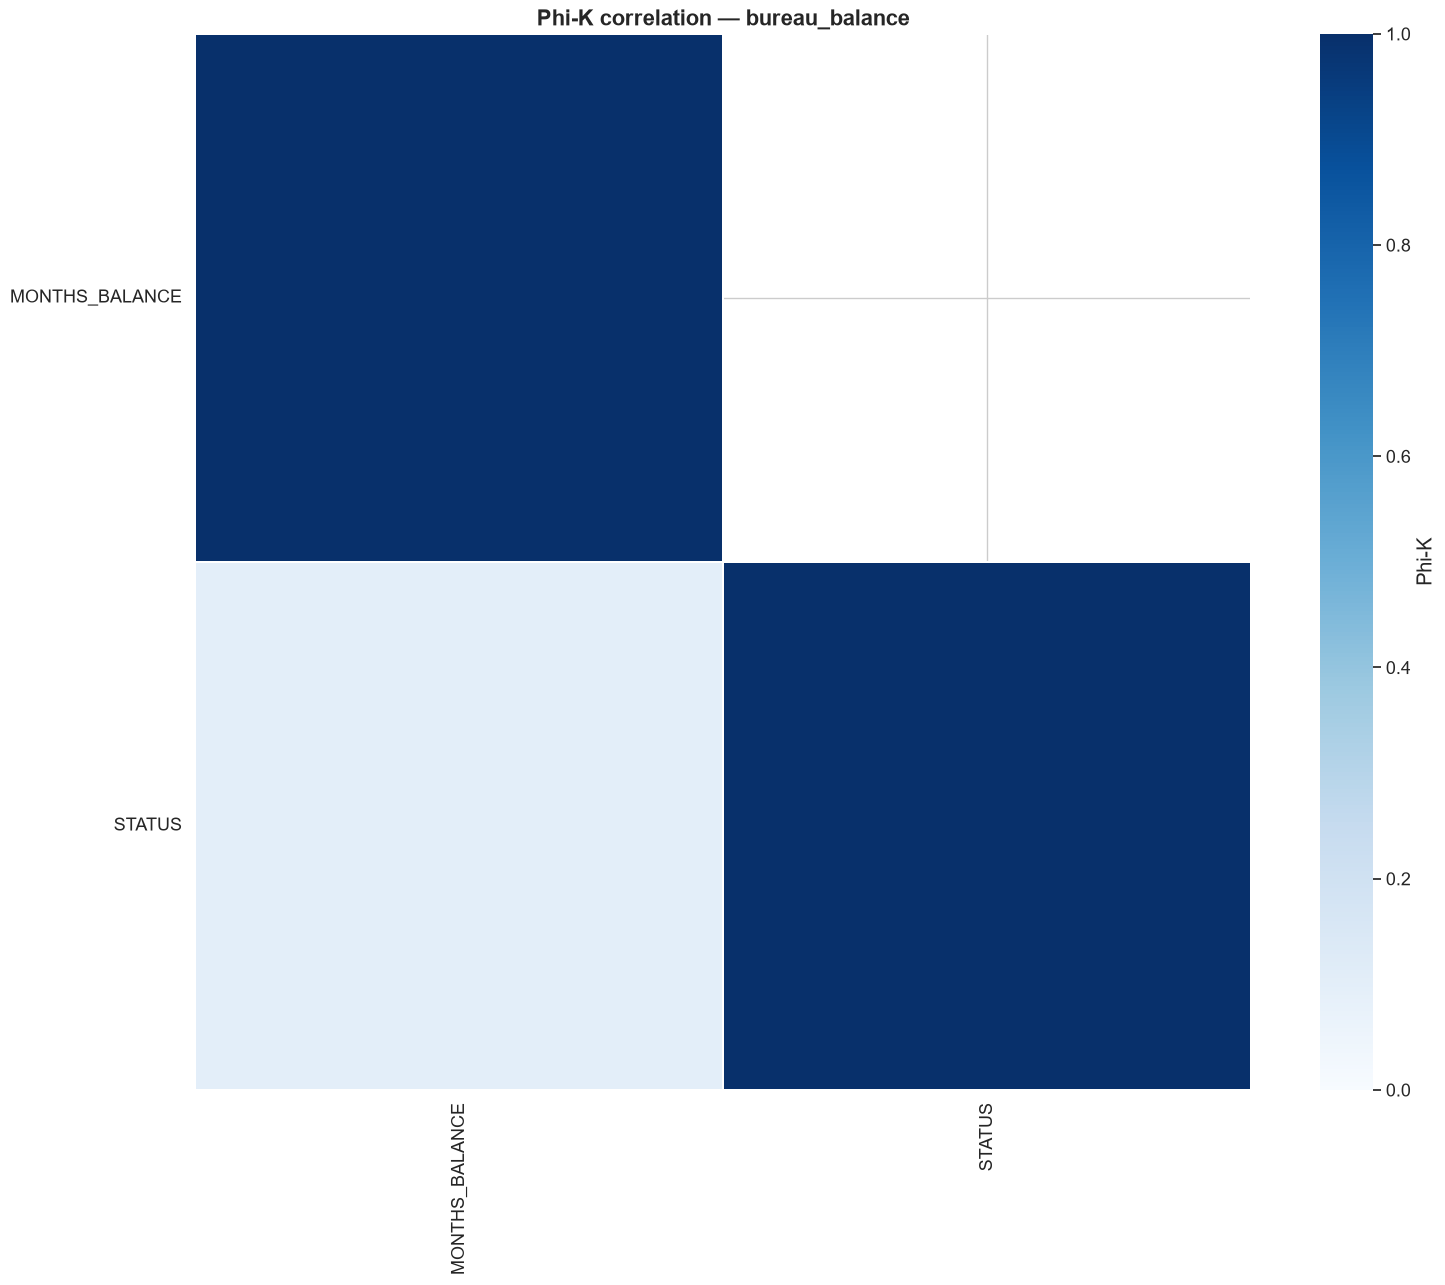

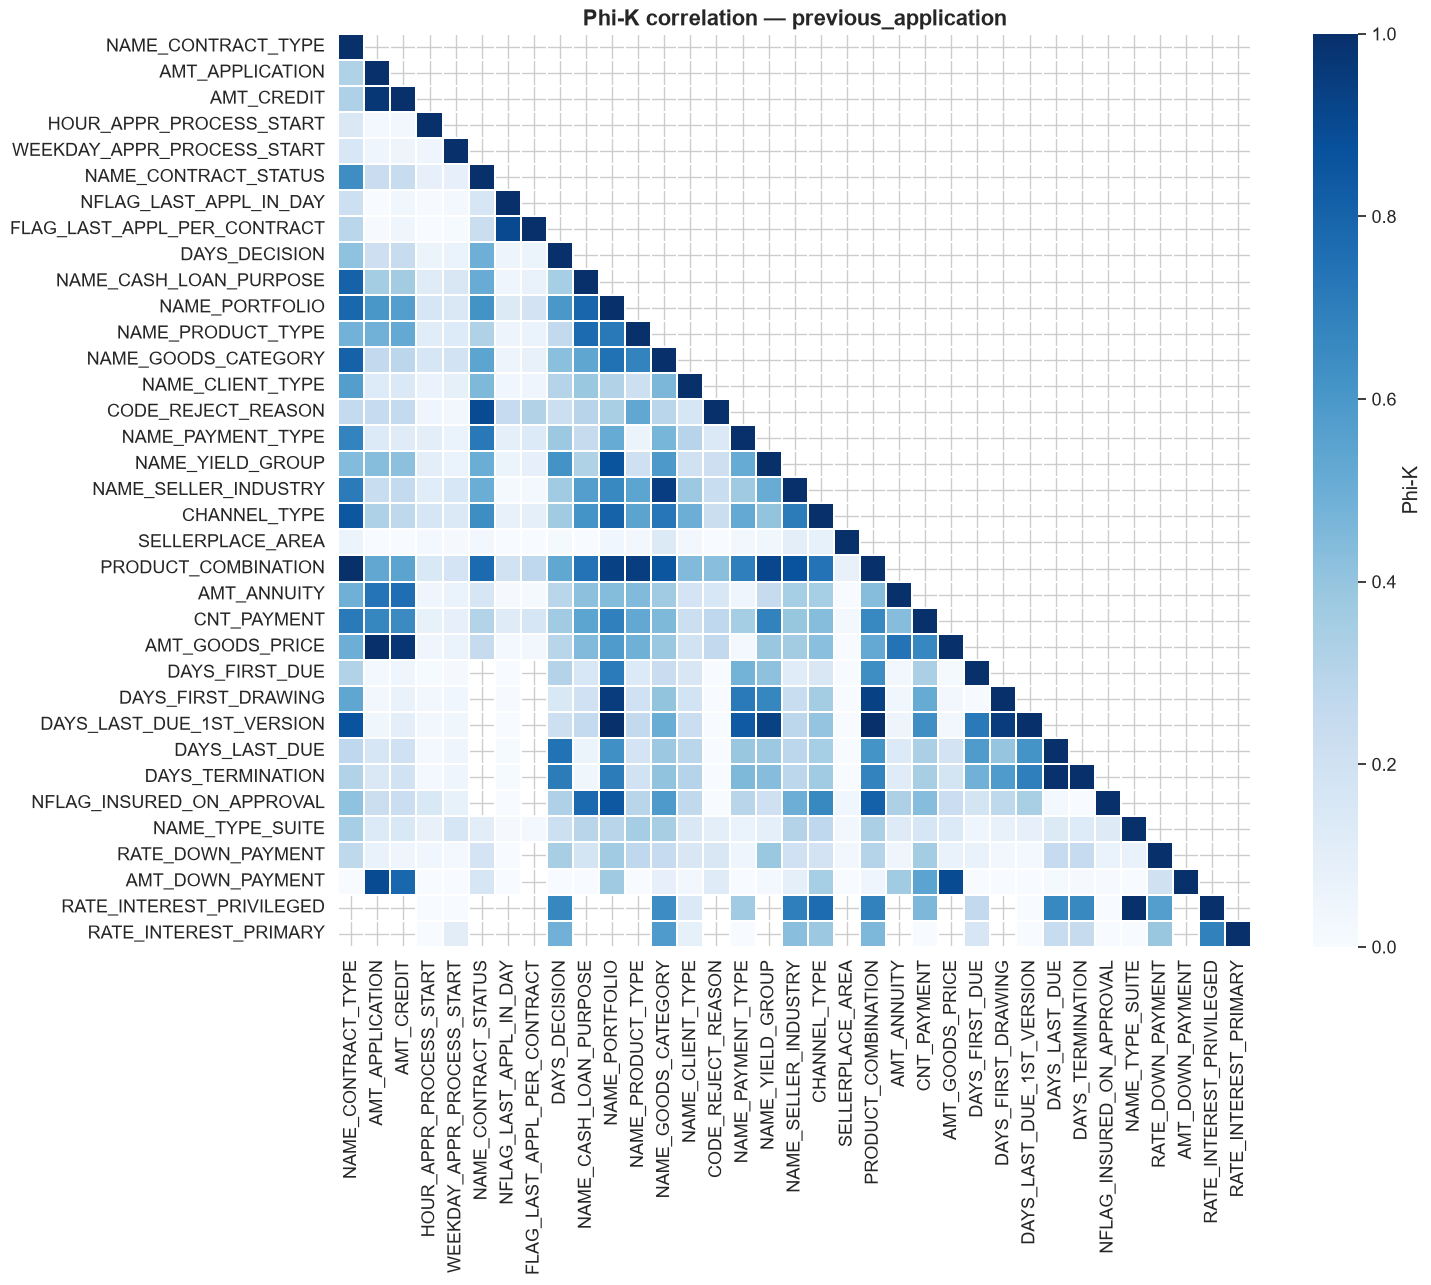

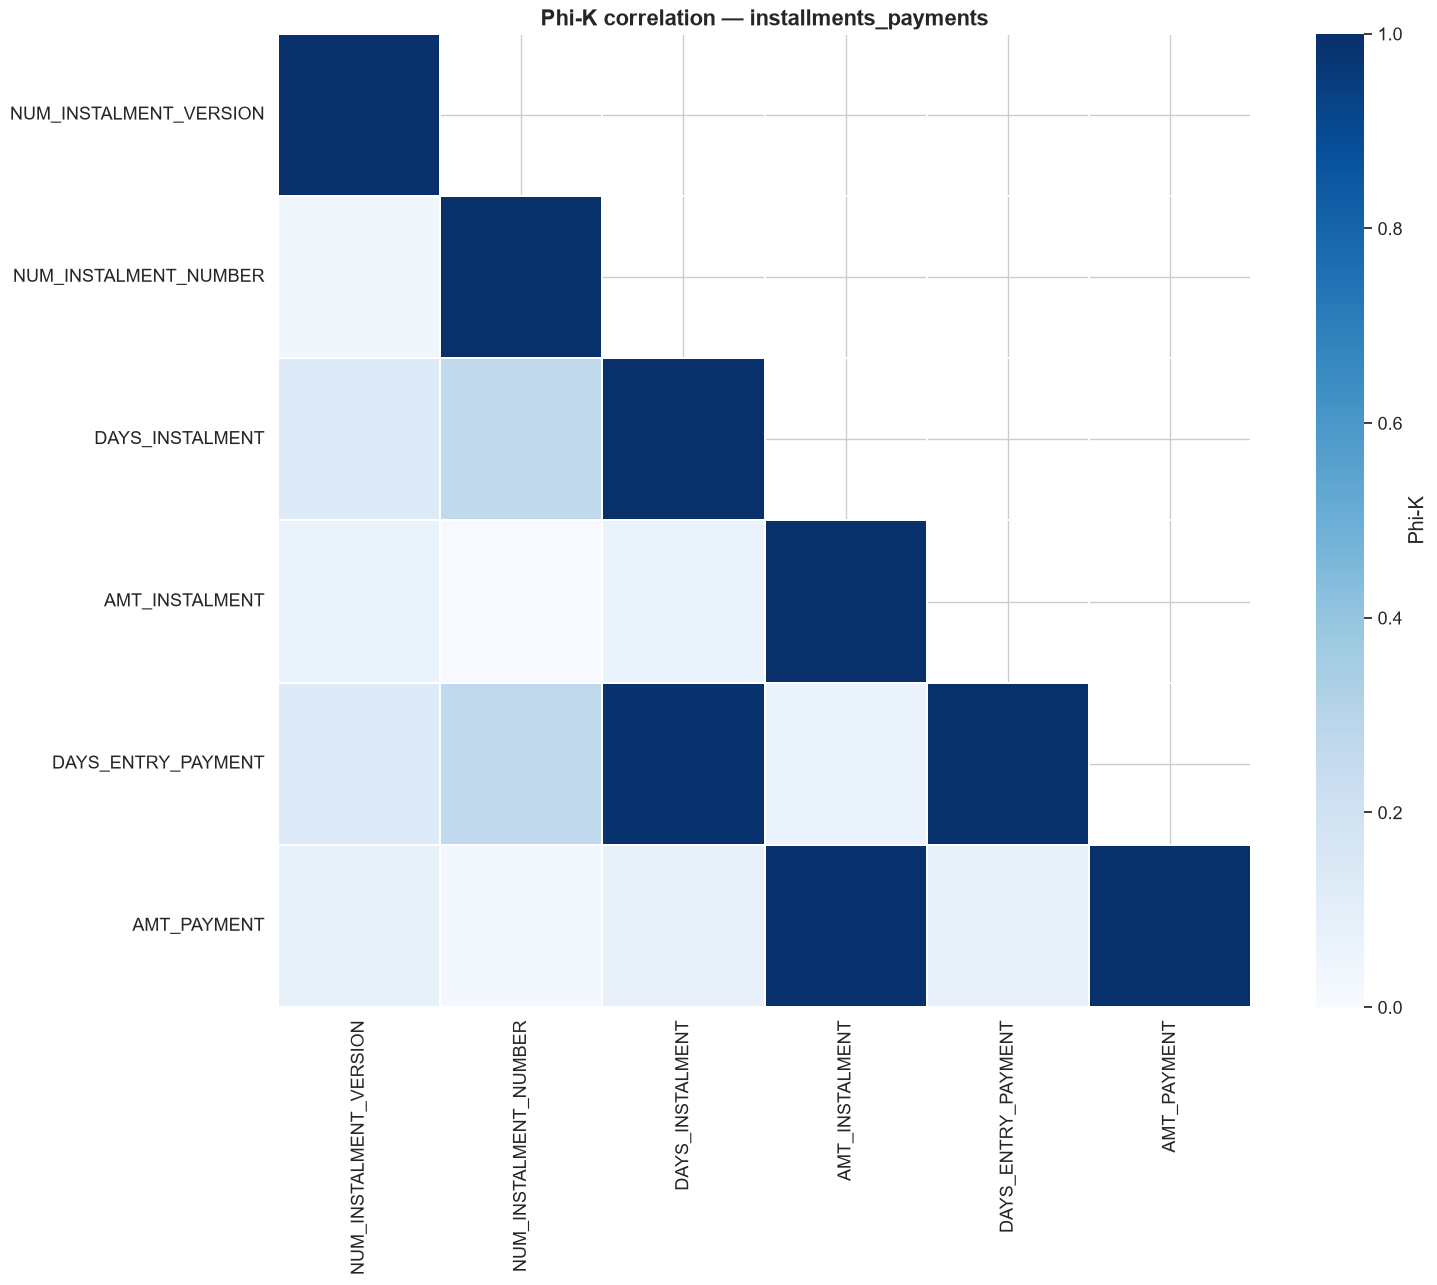

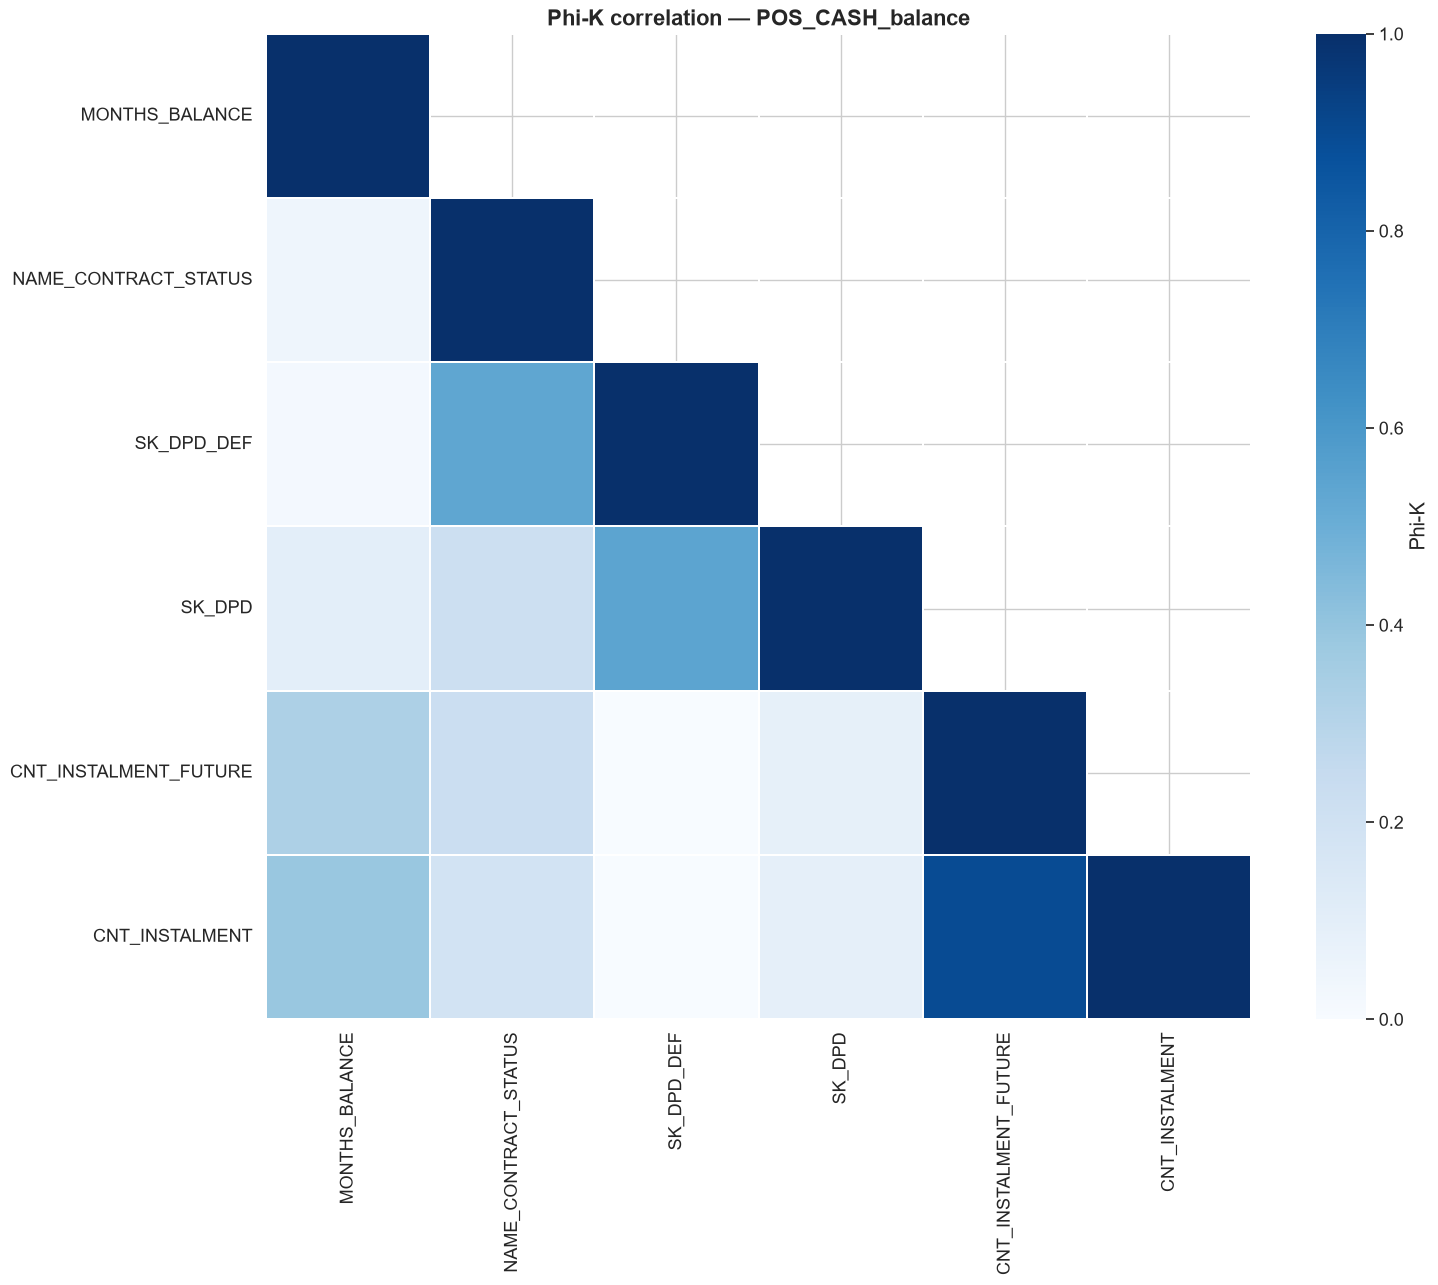

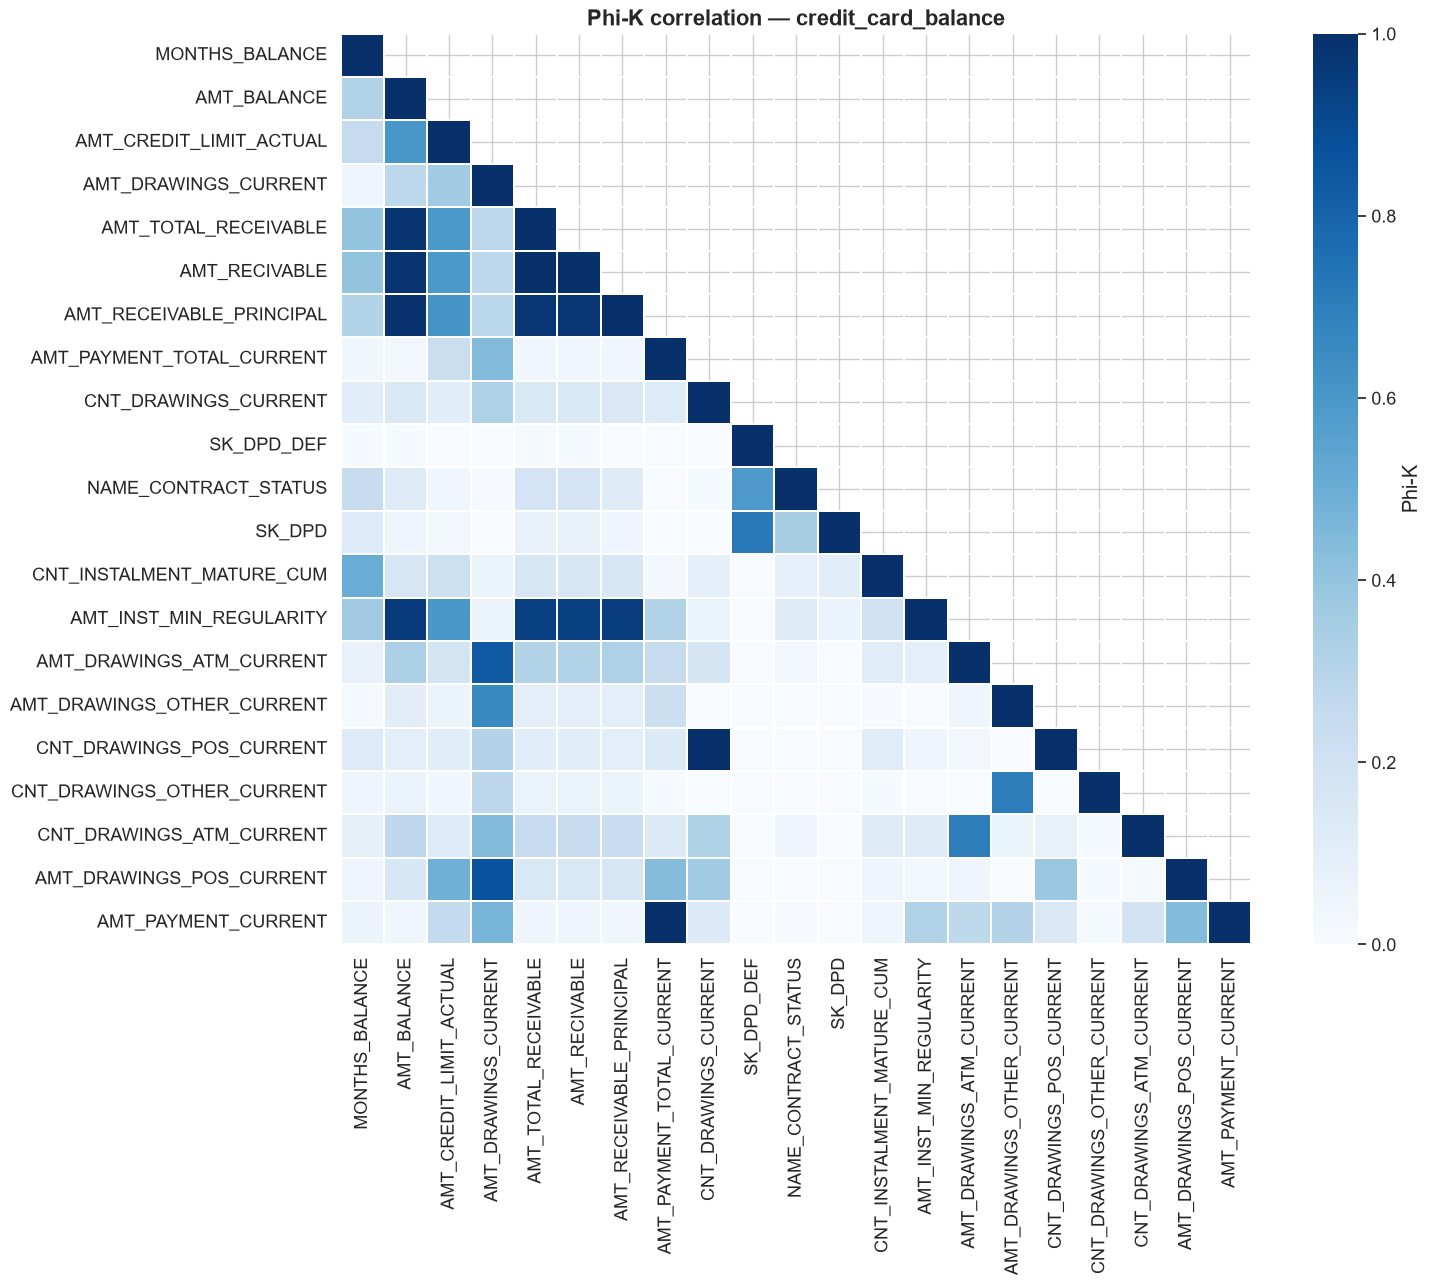

In [58]:
phik_matrices = {}

for table_name, df in tables.items():
    phik_matrices[table_name] = plot_phik_heatmap(
        df,
        table_name,
        sample_size=100_000,
        max_features=40
    )

In [ ]:
# ### ĐỀ XUẤT XÓA THUỘC TÍNH

In [59]:
import numpy as np
import pandas as pd

tables = {
    "bureau": bureau,
    "bureau_balance": bureau_balance,
    "previous_application": previous_application,
    "installments_payments": installments_payments,
    "POS_CASH_balance": POS_CASH_balance,
    "credit_card_balance": cc_balance
}

ID_COLUMNS = {
    "SK_ID_CURR",
    "SK_ID_PREV",
    "SK_ID_BUREAU"
}

def find_high_corr_moderate_missing(
    df,
    corr_threshold=0.70,
    min_missing=0.0,
    max_missing=40.0,
    method="spearman"
):
    # Chỉ lấy numeric feature và loại ID
    numeric_df = (
        df.select_dtypes(include=np.number)
        .drop(
            columns=[
                col for col in ID_COLUMNS
                if col in df.columns
            ],
            errors="ignore"
        )
    )

    # Loại cột hằng số
    numeric_df = numeric_df.loc[
        :,
        numeric_df.nunique(dropna=True) > 1
    ]

    if numeric_df.shape[1] < 2:
        return pd.DataFrame()

    missing_percent = numeric_df.isna().mean() * 100
    corr_matrix = numeric_df.corr(method=method)

    results = []

    for i, feature_1 in enumerate(corr_matrix.columns):
        for j in range(i + 1, len(corr_matrix.columns)):
            feature_2 = corr_matrix.columns[j]
            correlation = corr_matrix.iloc[i, j]

            if pd.isna(correlation):
                continue

            missing_1 = missing_percent[feature_1]
            missing_2 = missing_percent[feature_2]

            high_correlation = abs(correlation) >= corr_threshold

            feature_1_moderate_missing = (
                min_missing < missing_1 <= max_missing
            )
            feature_2_moderate_missing = (
                min_missing < missing_2 <= max_missing
            )

            # Giữ cặp nếu ít nhất một feature có missing vừa phải
            if high_correlation and (
                feature_1_moderate_missing
                or feature_2_moderate_missing
            ):
                # Feature missing nhiều hơn là ứng viên xem xét loại
                if missing_1 > missing_2:
                    drop_candidate = feature_1
                    keep_candidate = feature_2
                elif missing_2 > missing_1:
                    drop_candidate = feature_2
                    keep_candidate = feature_1
                else:
                    drop_candidate = "Cần xem xét thêm"
                    keep_candidate = "Cần xem xét thêm"

                results.append({
                    "feature_1": feature_1,
                    "feature_2": feature_2,
                    "correlation": correlation,
                    "absolute_correlation": abs(correlation),
                    "missing_feature_1_%": missing_1,
                    "missing_feature_2_%": missing_2,
                    "keep_candidate": keep_candidate,
                    "drop_candidate": drop_candidate
                })

    if not results:
        return pd.DataFrame()

    return (
        pd.DataFrame(results)
        .sort_values(
            [
                "absolute_correlation",
                "missing_feature_1_%"
            ],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )

In [60]:
high_corr_results = {}

for table_name, df in tables.items():
    result = find_high_corr_moderate_missing(
        df=df,
        corr_threshold=0.70,
        min_missing=0.0,
        max_missing=40.0,
        method="spearman"
    )

    high_corr_results[table_name] = result

    print("=" * 100)
    print(f"BẢNG: {table_name}")
    print(
        "Điều kiện: |correlation| >= 0.70 "
        "và ít nhất một feature có 0% < missing <= 40%"
    )

    if result.empty:
        print("Không có cặp feature phù hợp.")
    else:
        display(
            result.round({
                "correlation": 4,
                "absolute_correlation": 4,
                "missing_feature_1_%": 2,
                "missing_feature_2_%": 2
            })
        )

BẢNG: bureau
Điều kiện: |correlation| >= 0.70 và ít nhất một feature có 0% < missing <= 40%


,feature_1,feature_2,correlation,absolute_correlation,missing_feature_1_%,missing_feature_2_%,keep_candidate,drop_candidate
0,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,0.8806,0.8806,6.15,36.92,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT
1,DAYS_CREDIT,DAYS_ENDDATE_FACT,0.8738,0.8738,0.00,36.92,DAYS_CREDIT,DAYS_ENDDATE_FACT
2,DAYS_ENDDATE_FACT,DAYS_CREDIT_UPDATE,0.8719,0.8719,36.92,0.00,DAYS_CREDIT_UPDATE,DAYS_ENDDATE_FACT
3,DAYS_CREDIT_ENDDATE,DAYS_CREDIT_UPDATE,0.8098,0.8098,6.15,0.00,DAYS_CREDIT_UPDATE,DAYS_CREDIT_ENDDATE
4,DAYS_CREDIT,DAYS_CREDIT_ENDDATE,0.7418,0.7418,0.00,6.15,DAYS_CREDIT,DAYS_CREDIT_ENDDATE


BẢNG: bureau_balance
Điều kiện: |correlation| >= 0.70 và ít nhất một feature có 0% < missing <= 40%
Không có cặp feature phù hợp.
BẢNG: previous_application
Điều kiện: |correlation| >= 0.70 và ít nhất một feature có 0% < missing <= 40%


,feature_1,feature_2,correlation,absolute_correlation,missing_feature_1_%,missing_feature_2_%,keep_candidate,drop_candidate
0,AMT_APPLICATION,AMT_GOODS_PRICE,0.9999,0.9999,0.00,23.08,AMT_APPLICATION,AMT_GOODS_PRICE
1,AMT_CREDIT,AMT_GOODS_PRICE,0.9849,0.9849,0.00,23.08,AMT_CREDIT,AMT_GOODS_PRICE
2,AMT_APPLICATION,AMT_CREDIT,0.9167,0.9167,0.00,0.00,AMT_APPLICATION,AMT_CREDIT
3,AMT_ANNUITY,AMT_GOODS_PRICE,0.8892,0.8892,22.29,23.08,AMT_ANNUITY,AMT_GOODS_PRICE
4,AMT_ANNUITY,AMT_CREDIT,0.8800,0.8800,22.29,0.00,AMT_CREDIT,AMT_ANNUITY
5,AMT_ANNUITY,AMT_APPLICATION,0.8297,0.8297,22.29,0.00,AMT_APPLICATION,AMT_ANNUITY


BẢNG: installments_payments
Điều kiện: |correlation| >= 0.70 và ít nhất một feature có 0% < missing <= 40%


,feature_1,feature_2,correlation,absolute_correlation,missing_feature_1_%,missing_feature_2_%,keep_candidate,drop_candidate
0,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,0.9994,0.9994,0.0,0.02,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT
1,AMT_INSTALMENT,AMT_PAYMENT,0.9165,0.9165,0.0,0.02,AMT_INSTALMENT,AMT_PAYMENT


BẢNG: POS_CASH_balance
Điều kiện: |correlation| >= 0.70 và ít nhất một feature có 0% < missing <= 40%


,feature_1,feature_2,correlation,absolute_correlation,missing_feature_1_%,missing_feature_2_%,keep_candidate,drop_candidate
0,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,0.7408,0.7408,0.26,0.26,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE


BẢNG: credit_card_balance
Điều kiện: |correlation| >= 0.70 và ít nhất một feature có 0% < missing <= 40%


,feature_1,feature_2,correlation,absolute_correlation,missing_feature_1_%,missing_feature_2_%,keep_candidate,drop_candidate
0,AMT_DRAWINGS_POS_CURRENT,CNT_DRAWINGS_POS_CURRENT,0.9988,0.9988,19.52,19.52,Cần xem xét thêm,Cần xem xét thêm
1,AMT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_ATM_CURRENT,0.9970,0.9970,19.52,19.52,Cần xem xét thêm,Cần xem xét thêm
2,AMT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,0.9812,0.9812,19.52,19.52,Cần xem xét thêm,Cần xem xét thêm
3,AMT_BALANCE,AMT_INST_MIN_REGULARITY,0.9187,0.9187,0.00,7.95,AMT_BALANCE,AMT_INST_MIN_REGULARITY
4,AMT_INST_MIN_REGULARITY,AMT_RECEIVABLE_PRINCIPAL,0.9025,0.9025,7.95,0.00,AMT_RECEIVABLE_PRINCIPAL,AMT_INST_MIN_REGULARITY
5,AMT_INST_MIN_REGULARITY,AMT_TOTAL_RECEIVABLE,0.8867,0.8867,7.95,0.00,AMT_TOTAL_RECEIVABLE,AMT_INST_MIN_REGULARITY
6,AMT_INST_MIN_REGULARITY,AMT_RECIVABLE,0.8866,0.8866,7.95,0.00,AMT_RECIVABLE,AMT_INST_MIN_REGULARITY
7,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,0.8823,0.8823,20.00,0.00,AMT_PAYMENT_TOTAL_CURRENT,AMT_PAYMENT_CURRENT
8,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_TOTAL_CURRENT,0.8520,0.8520,7.95,0.00,AMT_PAYMENT_TOTAL_CURRENT,AMT_INST_MIN_REGULARITY
9,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,0.8081,0.8081,19.52,0.00,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_ATM_CURRENT


Phân phối của biến phân loại NAME_CONTRACT_TYPE

Cột này chứa thông tin về loại khoản vay (type of loan) của hồ sơ vay tương ứng.

Theo tài liệu do Home Credit cung cấp, có hai loại khoản vay:

Cash Loans: Khoản vay tiền mặt.
Revolving Loans: Khoản tín dụng quay vòng — khách hàng được cấp một hạn mức tín dụng và có thể vay, hoàn trả rồi tiếp tục sử dụng lại trong hạn mức đó.

In [26]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [27]:
#let us first see the unique categories of 'NAME_CONTRACT_TYPE'
print_unique_categories(application_train, 'NAME_CONTRACT_TYPE')

#plotting the Pie Plot for the column
plot_categorical_variables_pie(application_train, 'NAME_CONTRACT_TYPE', hole = 0.51)
print('-'*100)

----------------------------------------------------------------------------------------------------
The unique categories of 'NAME_CONTRACT_TYPE' are:
<StringArray>
['Cash loans', 'Revolving loans']
Length: 2, dtype: str
----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


Quan sát và Kết luận

Từ biểu đồ trên, chúng ta có thể rút ra các nhận xét và kết luận sau:

Từ biểu đồ thứ nhất – phân phối tổng thể (Overall Distribution):
Có thể thấy rằng phần lớn các khoản vay mà khách hàng đăng ký là Cash Loans (khoản vay tiền mặt).
Chỉ khoảng 9,52% khách hàng đăng ký Revolving Loans (khoản tín dụng quay vòng).
Từ biểu đồ thứ hai – tỷ lệ khách hàng Default (Percentage of Defaulters):
Nhóm khách hàng sử dụng Cash Loans có tỷ lệ Default cao hơn, khoảng 8,35%.
Trong khi đó, tỷ lệ Default của nhóm Revolving Loans chỉ khoảng 5,48%.

→ Như vậy, trong dữ liệu này, Cash Loans không chỉ phổ biến hơn mà còn có tỷ lệ Default cao hơn Revolving Loans. Điều này cho thấy NAME_CONTRACT_TYPE có thể chứa thông tin hữu ích trong việc phân biệt mức độ rủi ro tín dụng giữa các nhóm khách hàng.

<b><u>Distribution of Categorical Variable CODE_GENDER</u></b>

Cột này chứa thông tin về Giới tính của Khách hàng/Người nộp đơn.<br>
Ở đây <b>M</b> là viết tắt của <b>Male</b> và <b>F</b> cho <b>Female</b>.

In [28]:
#let us first see the unique categories of 'CODE_GENDER'
print_unique_categories(application_train, 'CODE_GENDER', show_counts = True)

#plotting the Pie Plot for the Column
plot_categorical_variables_pie(application_train, 'CODE_GENDER', hole = 0.5)
print('-'*100)

----------------------------------------------------------------------------------------------------
The unique categories of 'CODE_GENDER' are:
<StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str
----------------------------------------------------------------------------------------------------
Counts of each category are:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


##### Quan sát và kết luận:

CODE_GENDER có 4 dòng XNA không hợp lý và có thể loại bỏ. Nữ chiếm 65,8% hồ sơ, nam chiếm 34,2%, nhưng tỷ lệ vỡ nợ của nam cao hơn (10,14% so với 7%).

MÌNH LOẠI BỎ XNA

<b><u>Phân phối biến phân loại FLAG_EMP_PHONE</u></b>

Cột này cho biết khách hàng có cung cấp số điện thoại cơ quan hay không; 1 là Có và 0 là Không.

In [29]:
#let us first see the unique categories of 'FLAG_EMP_PHONE'
print_unique_categories(application_train, 'FLAG_EMP_PHONE')

#plotting the Pie Plot for the Column
plot_categorical_variables_pie(application_train, column_name = 'FLAG_EMP_PHONE', hole = 0.5)
print('-'*100)

----------------------------------------------------------------------------------------------------
The unique categories of 'FLAG_EMP_PHONE' are:
[1 0]
----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


## ### Quan sát và Kết luận:Tính năng này chứa hai danh mục, tức là khách hàng có cung cấp Số điện thoại cơ quan của mình trong quá trình đăng ký/đăng ký hay không.
<ol><li>Từ ô phụ đầu tiên, chúng tôi thấy rằng hầu hết người nộp đơn không cung cấp Số Điện Thoại Cơ Quan (82%) và chỉ 18 % đã cung cấp Số Điện Thoại Cơ Quan của họ.<li> Cũng có thể thấy rằng xu hướng Mặc định đối với những người cung cấp Số Điện thoại Cơ quan nhiều hơn những người không cung cấp Số Điện thoại Cơ quan.<br>
        Đây là đặc điểm có thể được quy cho thực tế là những Người vi phạm có thể đang cung cấp Số điện thoại Cơ quan của họ để họ không bị làm phiền trên điện thoại cá nhân của họ.

<b><u>Distribution of Categorical Variable REGION_RATING_CLIENT_W_CITY</u></b>Tính năng này là xếp hạng do Tín dụng Nhà cung cấp cho từng khu vực của khách hàng dựa trên các cuộc khảo sát mà họ có thể đã thực hiện. Xếp hạng này cũng tính đến Thành phố nơi khách hàng sống. <br>Xem xét Thành phố là rất quan trọng bởi vì ngay cả khi một số khu vực có xếp hạng tốt trong một Thành phố cụ thể, nhưng Thành phố đó không có xếp hạng cao, thì người nộp đơn sẽ được xếp hạng trung bình chứ không phải xếp hạng cao.<br>
Nó chứa các giá trị trong khoảng từ 1 đến 3.

In [30]:
#let us first see the unique categories of 'REGION_RATING_CLIENT_W_CITY'
print_unique_categories(application_train, 'REGION_RATING_CLIENT_W_CITY')

#plotting the Pie Plot for the Column
plot_categorical_variables_pie(application_train, column_name = 'REGION_RATING_CLIENT_W_CITY')
print('-'*100)

----------------------------------------------------------------------------------------------------
The unique categories of 'REGION_RATING_CLIENT_W_CITY' are:
[2 1 3]
----------------------------------------------------------------------------------------------------


----------------------------------------------------------------------------------------------------


## ### Quan sát và Kết luận:Từ các cốt truyện trên, chúng ta có thể rút ra những hiểu biết sâu sắc sau:
<ol><li>Từ ô con đầu tiên, chúng tôi thấy rằng hầu hết các khách hàng (74.6 %) có xếp hạng vùng là 2. Đây là giá trị trung bình dành cho hầu hết các ứng viên.<br>Very few applicants have a region rating of 1 (only 11.1%) and some have a rating of 3 (14.3%).</li><li>Among Defaulters, người ta thấy rằng hầu hết các Defaulters có xếp hạng khu vực là 3 (11.4 %) tương đương cao hơn hai xếp hạng khác, tức là khách hàng có xếp hạng 1 có tỷ lệ phần trăm Mặc định chỉ là 4.84 % và với xếp hạng 2 có tỷ lệ phần trăm 7.92%.</li>
    </ol>
Điều này cho thấy xếp hạng 3 có thể là một thuộc tính quan trọng để đưa ra quyết định về Đặc điểm Mặc định.

<b><u>Phân phối biến phân loại NAME_EDUCATION_TYPE</u></b>

Đặc trưng này mô tả trình độ học vấn cao nhất của khách hàng.

----------------------------------------------------------------------------------------------------
The unique categories of 'NAME_EDUCATION_TYPE' are:
<StringArray>
['Secondary / secondary special',              'Higher education',
             'Incomplete higher',               'Lower secondary',
               'Academic degree']
Length: 5, dtype: str
----------------------------------------------------------------------------------------------------
Counts of each category are:
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Total Number of unique categories of NAME_EDUCATION_TYPE = 5


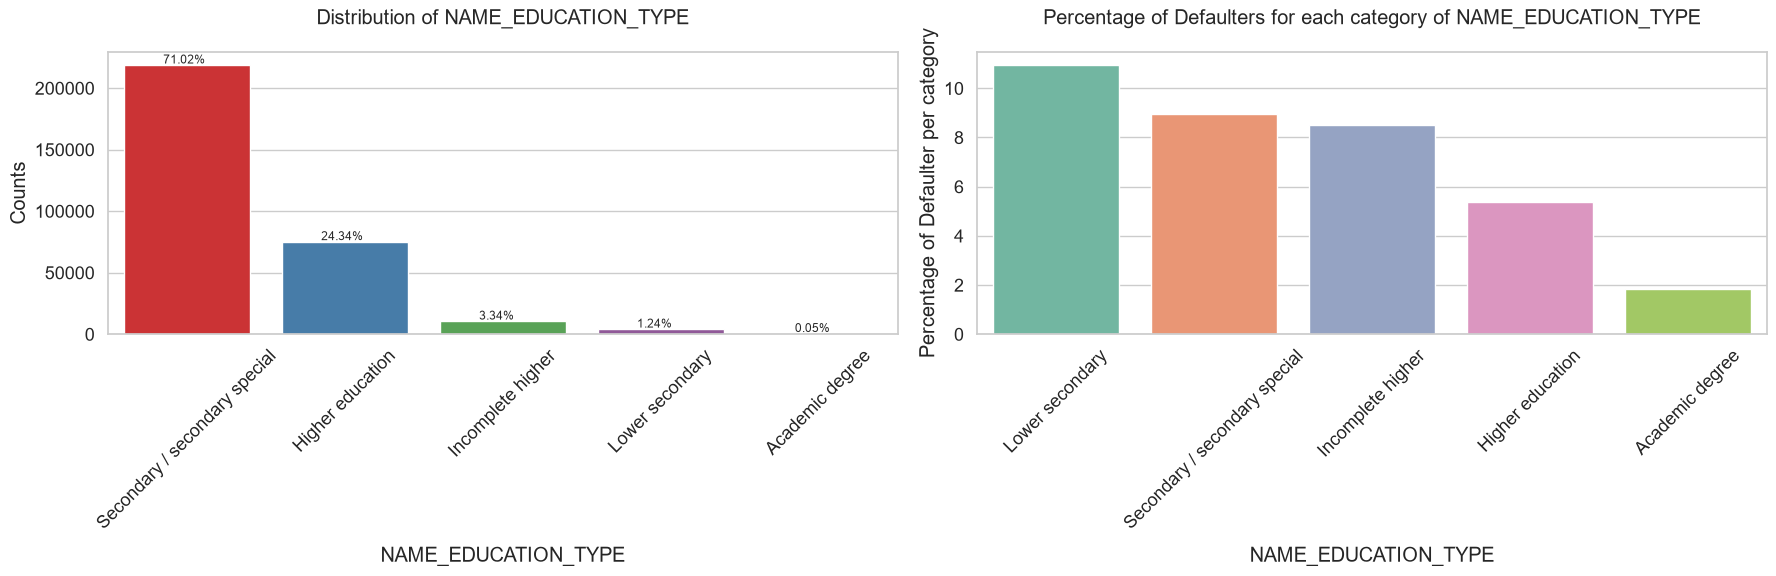

----------------------------------------------------------------------------------------------------


In [31]:
#let us first see the unique categories of 'NAME_EDUCATION_TYPE'
print_unique_categories(application_train, 'NAME_EDUCATION_TYPE', show_counts = True)

#plotting the Bar Plot for the Column
plot_categorical_variables_bar(application_train, column_name = 'NAME_EDUCATION_TYPE', rotation = 45, horizontal_adjust = 0.25)
print('-'*100)

##### Quan sát và kết luận:

Khoảng 71% khách hàng chỉ học tới trung học phổ thông/trung học chuyên biệt và 24,34% có trình độ đại học. Nhóm chỉ học tới trung học cơ sở có tỷ lệ vỡ nợ cao nhất; nhóm đại học thấp hơn, còn nhóm có học vị hàn lâm thấp nhất nhưng số lượng rất nhỏ.

<b><u>Distribution of Categorical Variable OCCUPATION_TYPE</u></b>

Tính năng này cho biết về loại Nghề nghiệp mà khách hàng có. Đây có thể là một tính năng rất quan trọng có thể mô tả các Đặc điểm Mặc định của khách hàng. Chúng ta hãy xem các âm mưu cho họ.

----------------------------------------------------------------------------------------------------
The unique categories of 'OCCUPATION_TYPE' are:
<StringArray>
[             'Laborers',            'Core staff',           'Accountants',
              'Managers',                     nan,               'Drivers',
           'Sales staff',        'Cleaning staff',         'Cooking staff',
 'Private service staff',        'Medicine staff',        'Security staff',
 'High skill tech staff',  'Waiters/barmen staff',    'Low-skill Laborers',
         'Realty agents',           'Secretaries',              'IT staff',
              'HR staff']
Length: 19, dtype: str
----------------------------------------------------------------------------------------------------
Total Number of unique categories of OCCUPATION_TYPE = 19


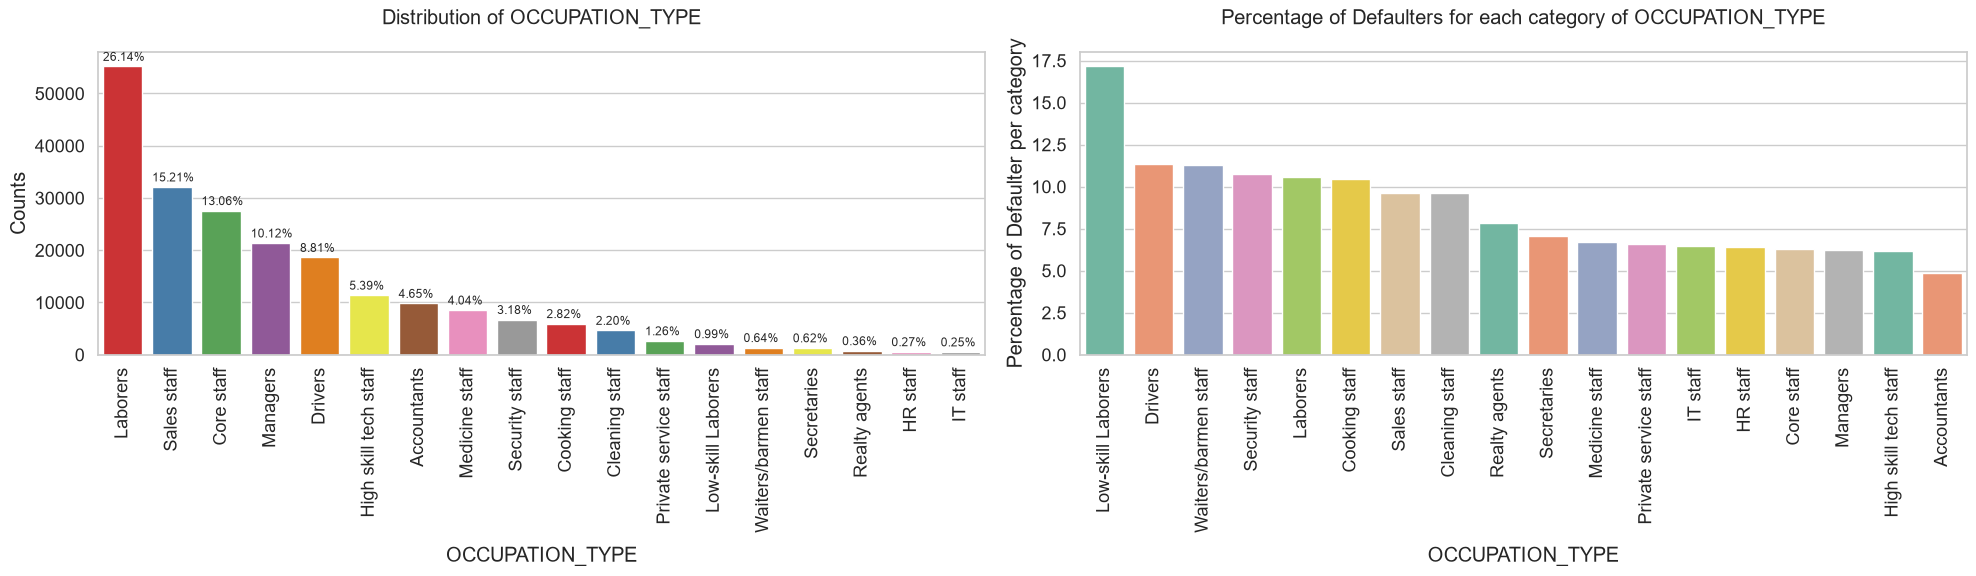

----------------------------------------------------------------------------------------------------


In [32]:
#let us first see the unique categories of 'OCCUPATION_TYPE'
print_unique_categories(application_train, 'OCCUPATION_TYPE')

#plotting the Bar Plot for the Column
plot_categorical_variables_bar(application_train, column_name = 'OCCUPATION_TYPE', figsize = (20,6), rotation = 90)
print('-'*100)

##### Quan sát và kết luận:

Lao động phổ thông là nghề phổ biến nhất, gần 26%. Lao động tay nghề thấp có tỷ lệ vỡ nợ cao nhất (khoảng 17,5%), tiếp theo là tài xế, phục vụ, bảo vệ và đầu bếp. Các nghề có kỹ năng trung bình hoặc cao có tỷ lệ thấp hơn.

<b><u>Distribution of Categorical Variable ORGANIZATION_TYPE</u></b>

Tương tự như Loại Nghề nghiệp, Loại Tổ chức mà khách hàng thuộc về cũng có thể là một tính năng quan trọng để dự đoán Rủi ro Mặc định của khách hàng đó. Hãy để chúng tôi hình dung chi tiết hơn về tính năng này.

Total Number of categories of ORGANIZATION_TYPE = 58


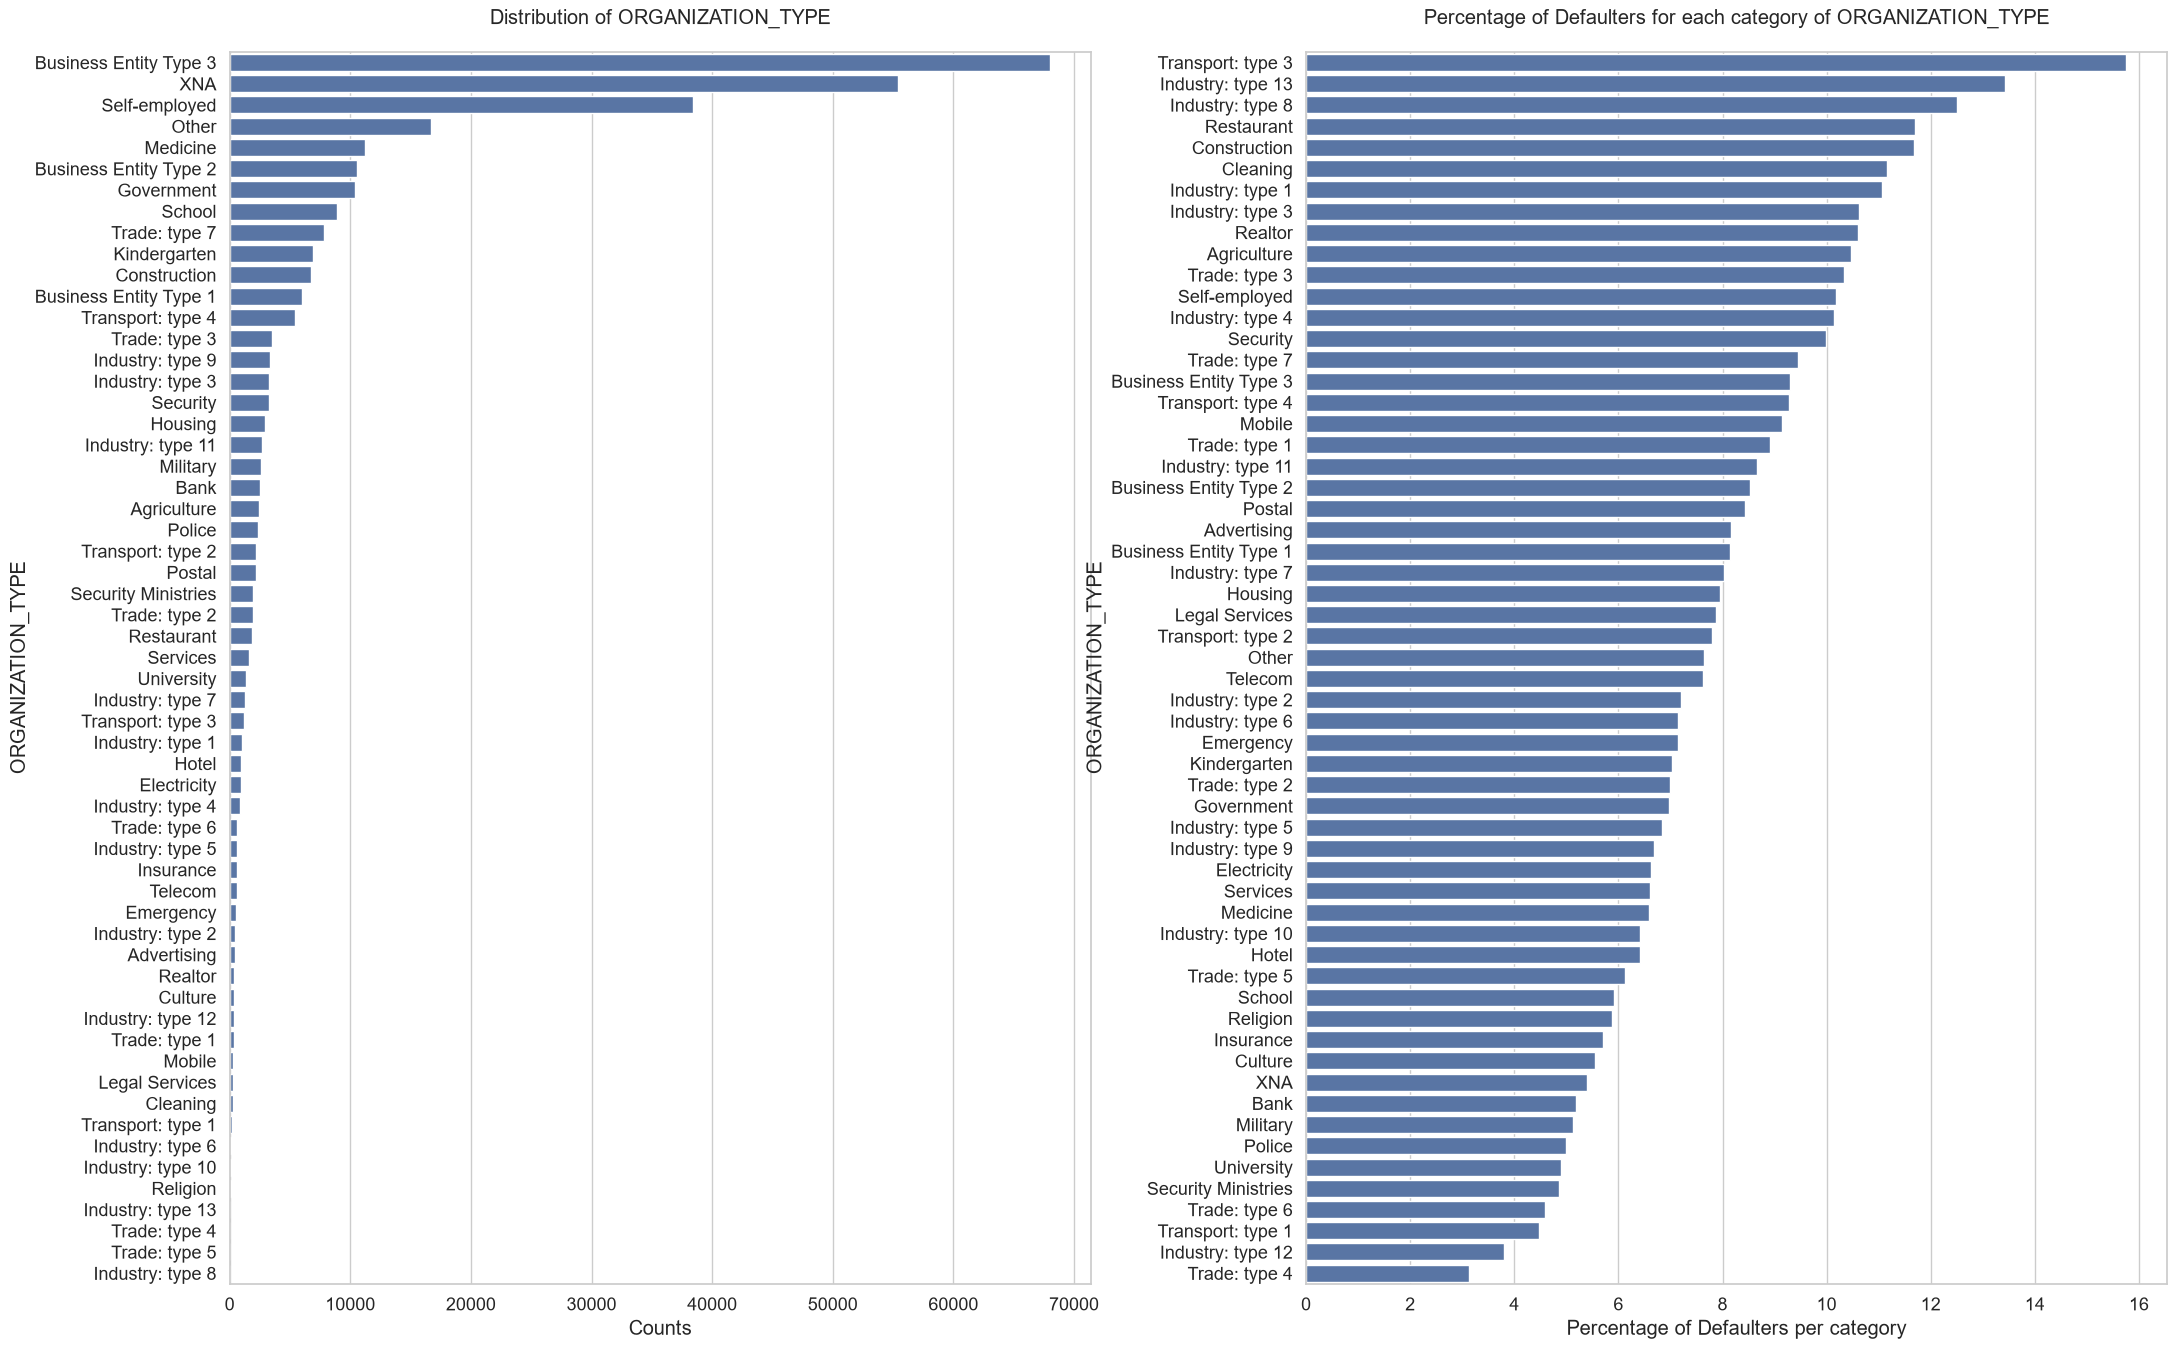

In [33]:
print(f"Total Number of categories of ORGANIZATION_TYPE = {len(application_train.ORGANIZATION_TYPE.unique())}")

plt.figure(figsize = (25,16))
sns.set(style = 'whitegrid', font_scale = 1.2)
plt.subplots_adjust(wspace=0.25)

plt.subplot(1,2,1)
count_organization = application_train.ORGANIZATION_TYPE.value_counts().sort_values(ascending = False)
sns.barplot(x = count_organization, y = count_organization.index)
plt.title('Distribution of ORGANIZATION_TYPE', pad = 20)
plt.xlabel('Counts')
plt.ylabel('ORGANIZATION_TYPE')

plt.subplot(1,2,2)
percentage_default_per_organization = application_train[application_train.TARGET == 1].ORGANIZATION_TYPE.value_counts() * 100 / count_organization
percentage_default_per_organization = percentage_default_per_organization.dropna().sort_values(ascending = False)
sns.barplot(x = percentage_default_per_organization, y = percentage_default_per_organization.index)
plt.title('Percentage of Defaulters for each category of ORGANIZATION_TYPE', pad = 20)
plt.xlabel('Percentage of Defaulters per category')
plt.ylabel('ORGANIZATION_TYPE')

plt.show()

## ### Quan sát và Kết luận:Có rất nhiều loại tổ chức mà khách hàng thuộc về, chính xác là 58. Các lô ở trên đưa ra những quan sát sau:
<ol><li>Từ lô đầu tiên, chúng tôi thấy rằng hầu hết các ứng viên làm việc trong các Tổ chức thuộc Loại 'Thực thể Kinh doanh Loại 3', 'XNA' hoặc 'Tự làm chủ'. Loại tổ chức 'XNA' có thể biểu thị loại tổ chức chưa được phân loại TYpe.</li><li>Từ lô thứ hai, chúng tôi nhận thấy rằng các ứng viên thuộc 'Transport: type 3' có xu hướng vỡ nợ cao nhất so với phần còn lại. Tiếp theo là các loại hình tổ chức: 'Industry: type 13', 'Industry: type 8', 'Restaurant', 'Construction', etc.</li>
    <li> Các tổ chức hiển thị tỷ lệ mặc định thấp nhất là 'Giao dịch: loại 4', 'Ngành: loại 12', v.v.
</ol>Những con số loại này cũng sẽ nói thêm điều gì đó về Tổ chức, tuy nhiên, chúng tôi không có bất kỳ thông tin nào liên quan đến điều đó, vì vậy chúng tôi sẽ chỉ tuân theo cách đặt tên được cung cấp cho chúng tôi.

<b><u>Phân phối REG_CITY_NOT_LIVE_CITY, REG_CITY_NOT_WORK_CITY và LIVE_CITY_NOT_WORK_CITY</u></b><br><br>
Các cột này cho biết địa chỉ thường trú có khác địa chỉ liên hệ hoặc địa chỉ làm việc ở cấp vùng/thành phố hay không. Giá trị 1 là khác và 0 là giống nhau.

----------------------------------------------------------------------------------------------------
Total Number of unique categories of REG_CITY_NOT_LIVE_CITY = 2


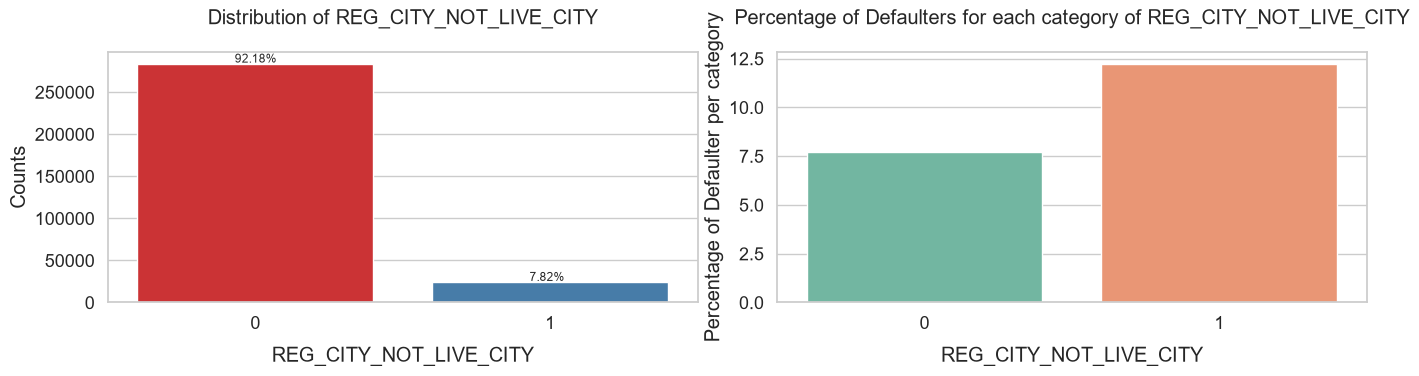

----------------------------------------------------------------------------------------------------
Total Number of unique categories of REG_CITY_NOT_WORK_CITY = 2


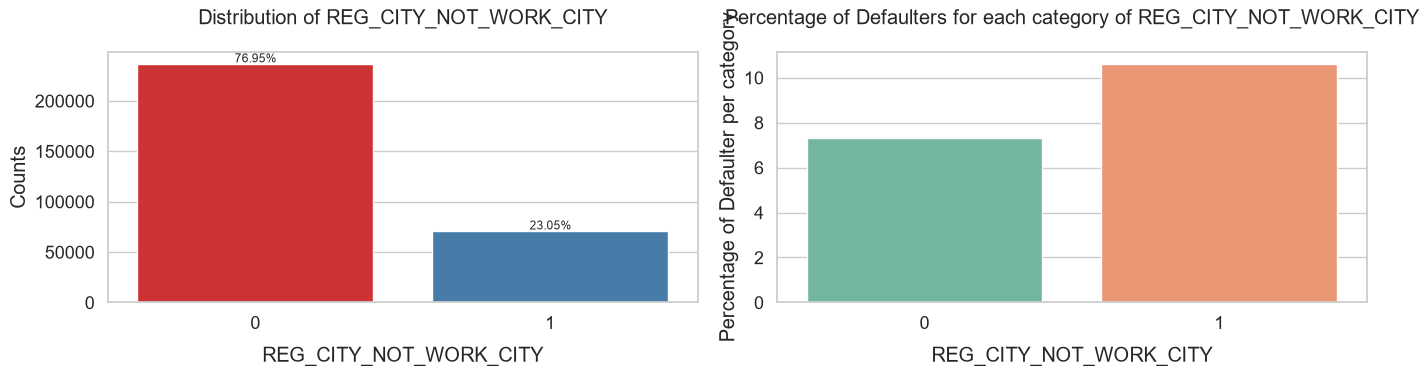

----------------------------------------------------------------------------------------------------
Total Number of unique categories of LIVE_CITY_NOT_WORK_CITY = 2


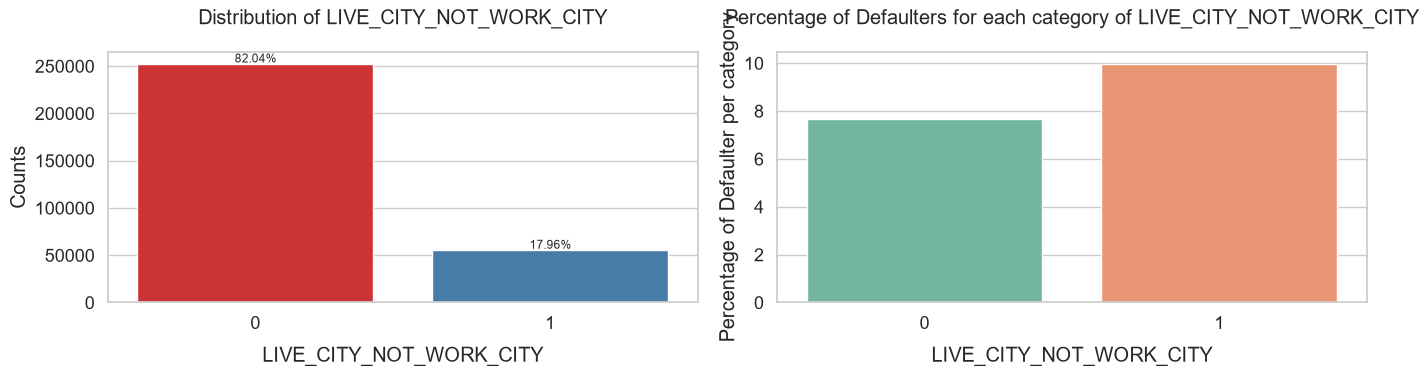

----------------------------------------------------------------------------------------------------


In [34]:
print('-'*100)
plot_categorical_variables_bar(application_train, column_name = 'REG_CITY_NOT_LIVE_CITY', figsize = (14, 4), horizontal_adjust = 0.33)
print('-'*100)
plot_categorical_variables_bar(application_train, column_name = 'REG_CITY_NOT_WORK_CITY', figsize = (14, 4), horizontal_adjust = 0.33)
print('-'*100)
plot_categorical_variables_bar(application_train, column_name = 'LIVE_CITY_NOT_WORK_CITY', figsize = (14, 4), horizontal_adjust = 0.33)
print('-'*100)

##### Quan sát và kết luận:

Chỉ một bộ phận nhỏ người nộp đơn có các địa chỉ không trùng khớp: 7,52% khác địa chỉ liên hệ theo vùng, 23,05% khác địa chỉ làm việc theo vùng và 17,96% khác địa chỉ liên hệ theo thành phố. Trong cả ba trường hợp, nhóm có địa chỉ khác nhau đều có tỷ lệ vỡ nợ cao hơn nhóm có cùng địa chỉ; vì vậy, sự không trùng khớp địa chỉ có thể là một tín hiệu về rủi ro vỡ nợ.

<b><u>Phân phối biến phân loại FLAG_DOCUMENT_3</u></b>

Cột này cho biết người nộp đơn có nộp một tài liệu bắt buộc hay không. Giá trị 0 nghĩa là đã cung cấp tài liệu và 1 nghĩa là chưa cung cấp.

Total Number of unique categories of FLAG_DOCUMENT_3 = 2


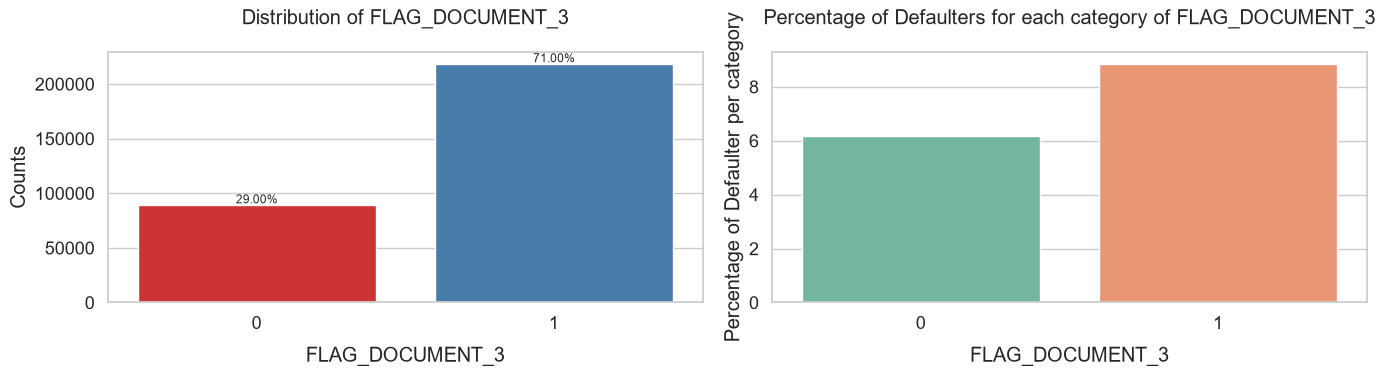

In [35]:
plot_categorical_variables_bar(application_train, column_name = 'FLAG_DOCUMENT_3', figsize = (14, 4), horizontal_adjust = 0.33)

##### Quan sát và kết luận:

Khoảng 71% khách hàng chưa cung cấp tài liệu này và 29% đã cung cấp. Nhóm đã cung cấp lại có tỷ lệ vỡ nợ thấp hơn.

#### Trực quan hóa các biến liên tục

<b><u>Phân phối biến liên tục tuổi của người nộp đơn</u></b>

Tuổi trong bộ dữ liệu được biểu diễn theo ngày. Để dễ phân tích và diễn giải, chúng ta tạo một biến mới biểu diễn tuổi theo năm.

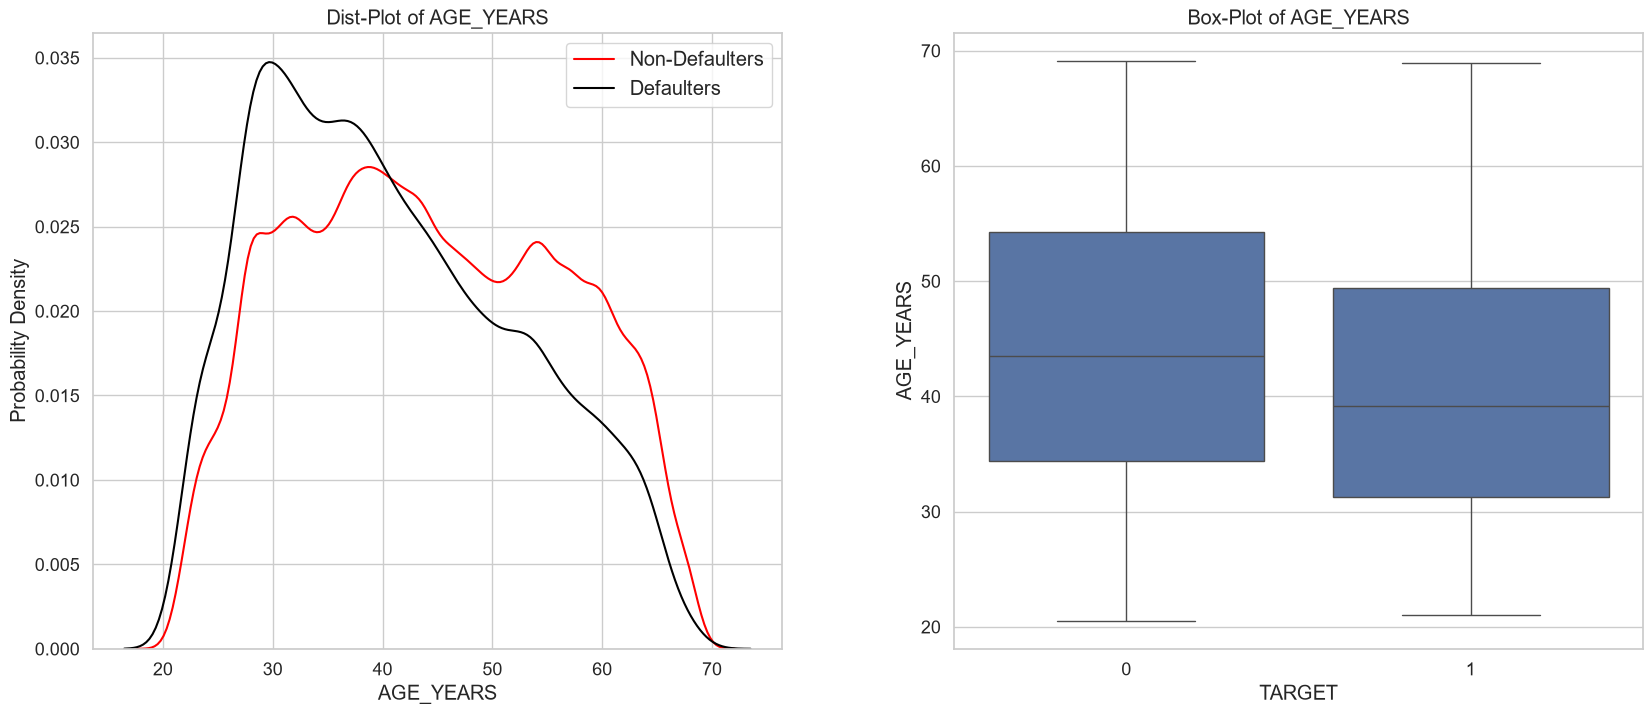

In [36]:
application_train['AGE_YEARS'] = application_train['DAYS_BIRTH'] * -1 / 365
plot_continuous_variables(application_train, 'AGE_YEARS', plots = ['distplot','box'])
_ = application_train.pop('AGE_YEARS')

##### Quan sát và kết luận:

Phân phối tuổi của nhóm vỡ nợ đạt đỉnh gần 30 tuổi và nhìn chung dịch về phía trẻ hơn so với nhóm không vỡ nợ. Box plot cũng cho thấy mọi phân vị tuổi của nhóm vỡ nợ đều thấp hơn; phân vị 75% xấp xỉ 49 tuổi, so với khoảng 54 tuổi ở nhóm không vỡ nợ. Nhìn chung, khách hàng vỡ nợ thường trẻ hơn.

<b><u>Phân phối các biến liên tục thuộc nhóm DAYS</u><b>

<b>DAYS_EMPLOYED</b><br>

Đặc trưng này biểu thị số ngày khách hàng đã làm việc tính tới ngày nộp đơn. Ta chuyển số ngày sang số năm để dễ diễn giải.

----------------------------------------------------------------------------------------------------
The 0th percentile value of DAYS_EMPLOYED is -17912.0
The 25th percentile value of DAYS_EMPLOYED is -2760.0
The 50th percentile value of DAYS_EMPLOYED is -1213.0
The 75th percentile value of DAYS_EMPLOYED is -289.0
The 90th percentile value of DAYS_EMPLOYED is 365243.0
The 92th percentile value of DAYS_EMPLOYED is 365243.0
The 94th percentile value of DAYS_EMPLOYED is 365243.0
The 96th percentile value of DAYS_EMPLOYED is 365243.0
The 98th percentile value of DAYS_EMPLOYED is 365243.0
The 100th percentile value of DAYS_EMPLOYED is 365243.0
----------------------------------------------------------------------------------------------------


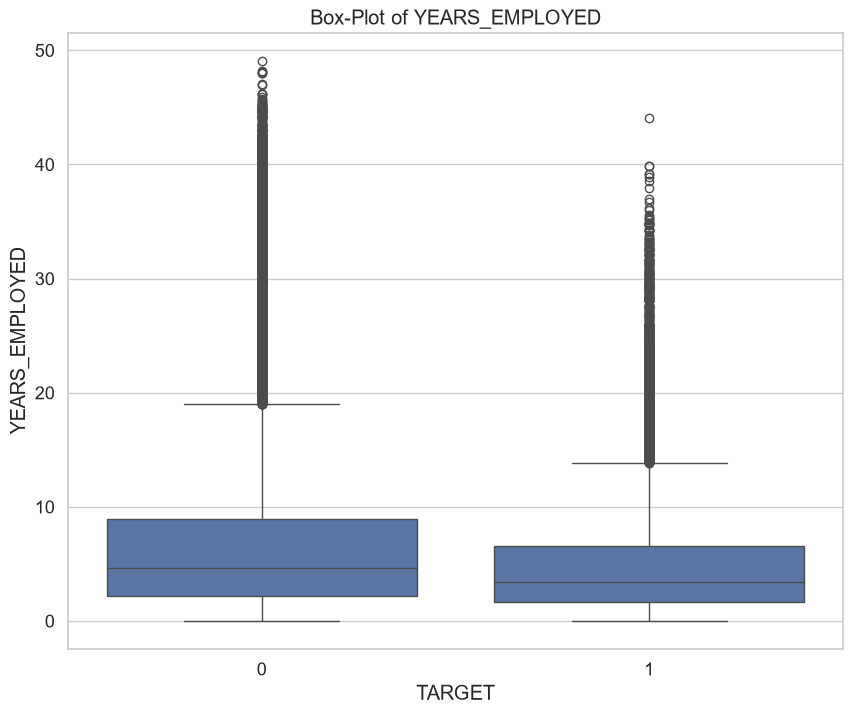

In [37]:
application_train['YEARS_EMPLOYED'] = application_train.DAYS_EMPLOYED * -1 / 365
print_percentiles(application_train, 'DAYS_EMPLOYED')
plot_continuous_variables(application_train, 'YEARS_EMPLOYED', plots = ['box'], scale_limits = [0,70], figsize = (10,8))
_ = application_train.pop('YEARS_EMPLOYED')

##### Quan sát và kết luận:

Cột DAYS_EMPLOYED có các giá trị bất hợp lý bằng 365243. Sau khi xem box plot, nhóm vỡ nợ có thời gian làm việc ngắn hơn nhóm không vỡ nợ ở cả các phân vị 25%, 50% và 75%.

<b>DAYS_ID_PUBLISH</b><br>

Cột này cho biết số ngày tính từ lần gần nhất khách hàng thay đổi giấy tờ tùy thân dùng để đăng ký khoản vay.

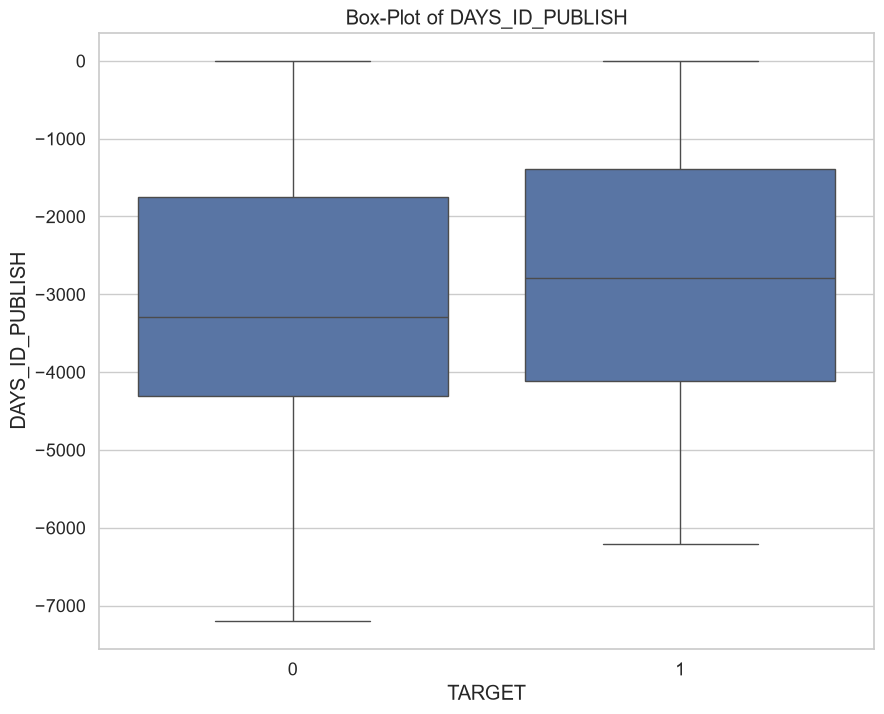

In [38]:
plot_continuous_variables(application_train, 'DAYS_ID_PUBLISH', plots = ['box'], figsize = (10,8))

##### Quan sát và kết luận:

Tương tự DAYS_REGISTRATION, nhóm vỡ nợ thường mới thay đổi giấy tờ tùy thân gần đây hơn. Tất cả các phân vị về số ngày của nhóm không vỡ nợ đều lớn hơn.

<b><u>Phân phối các biến EXT_SOURCE</u></b>

Ba cột EXT_SOURCE chứa điểm số đã chuẩn hóa trong khoảng từ 0 đến 1, được tổng hợp từ các nguồn khác nhau.

----------------------------------------------------------------------------------------------------


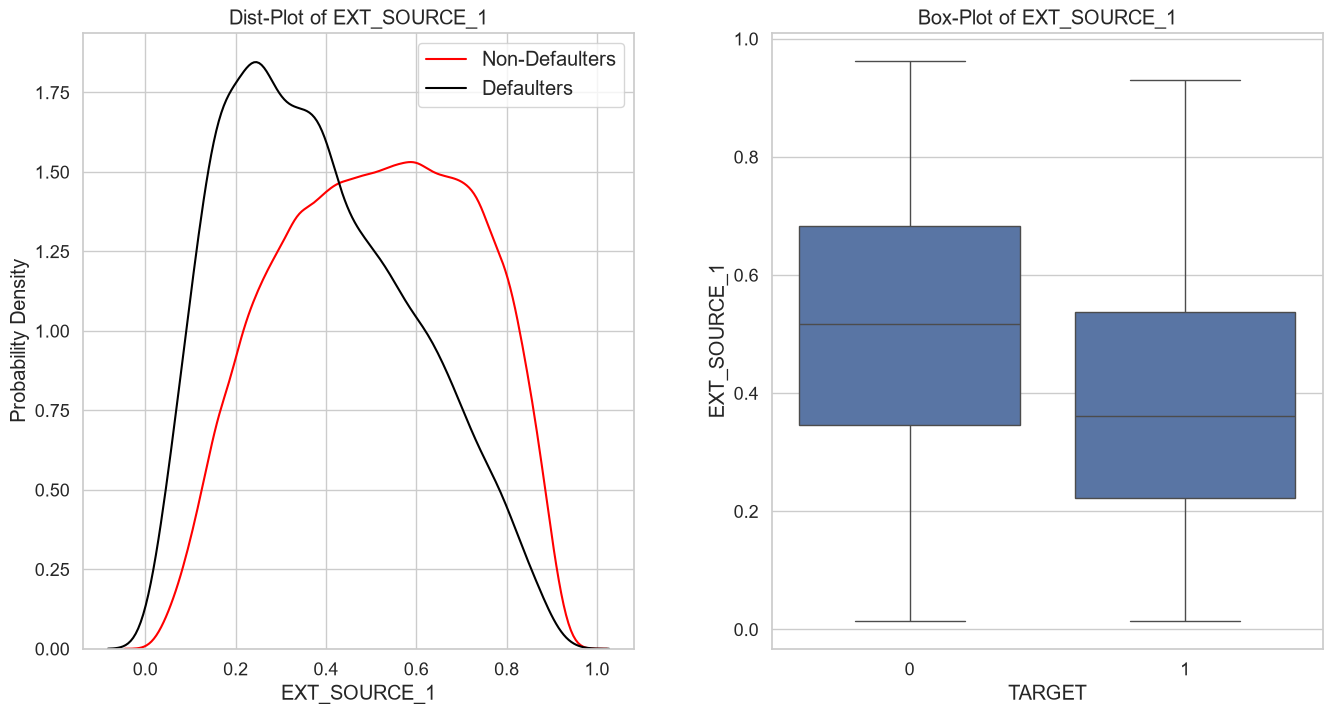

----------------------------------------------------------------------------------------------------


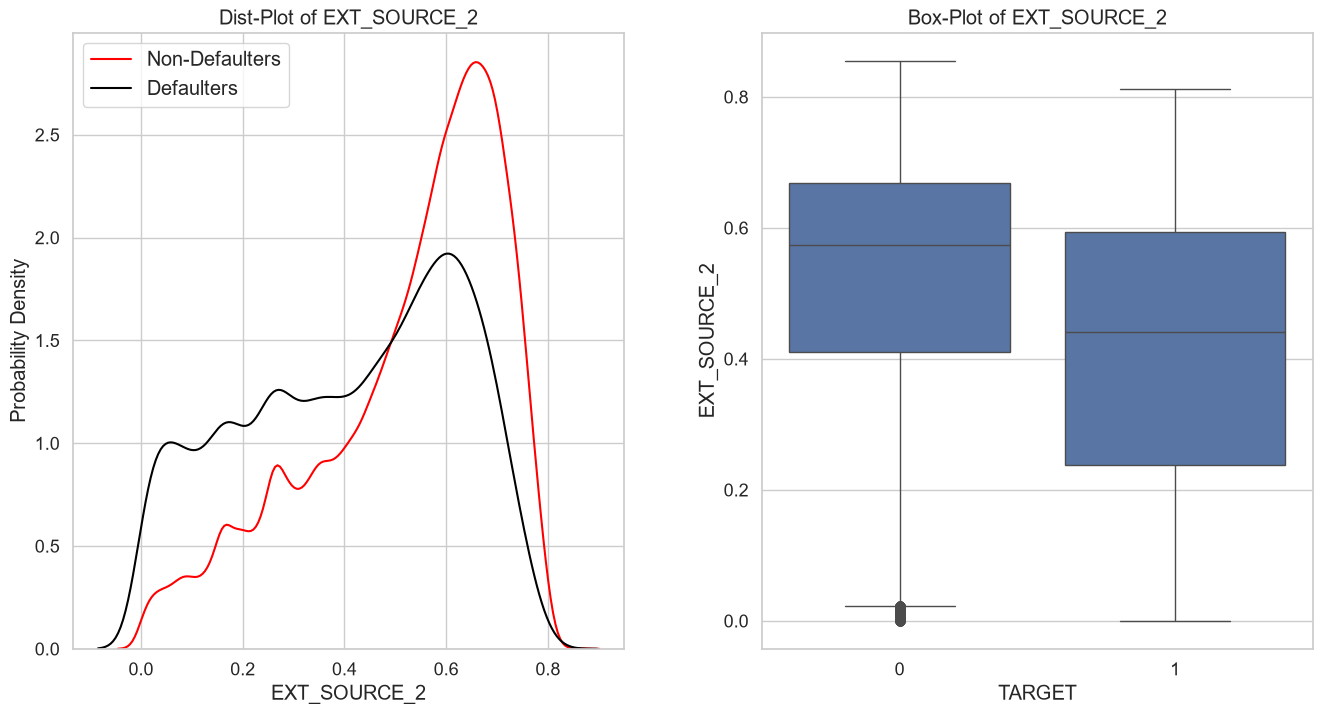

----------------------------------------------------------------------------------------------------


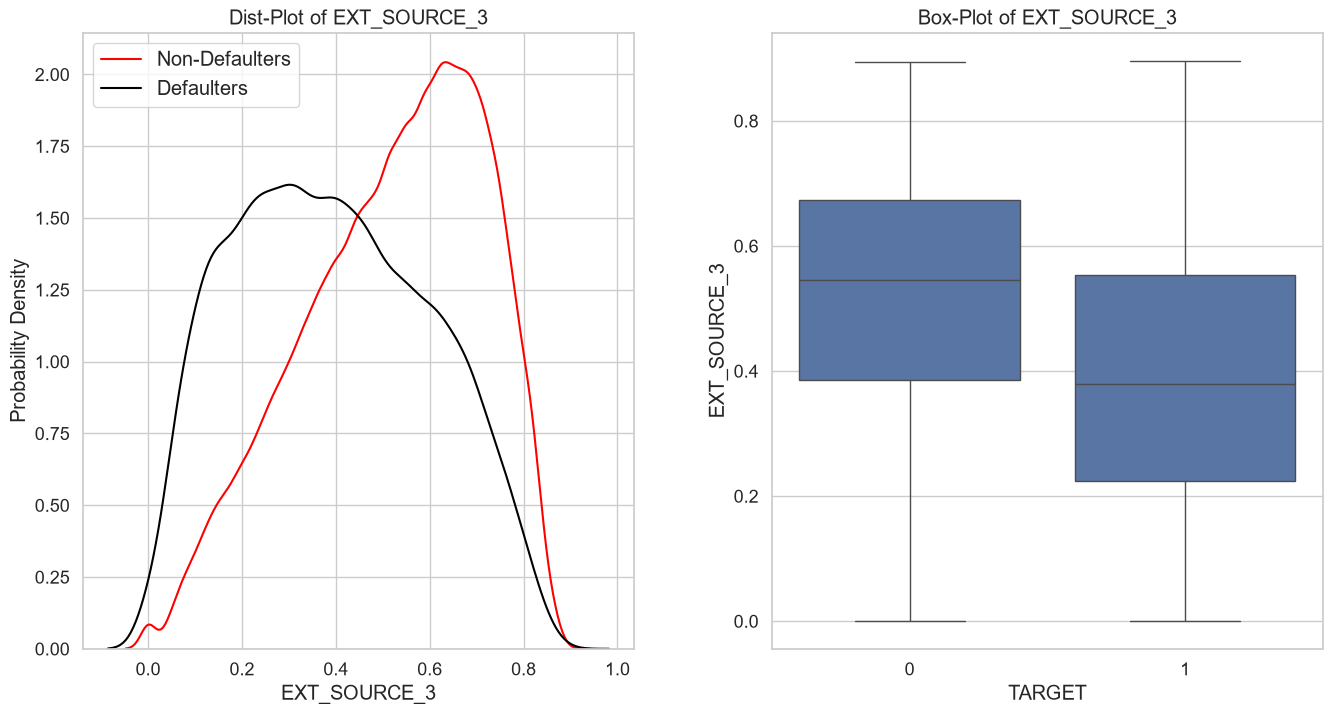

----------------------------------------------------------------------------------------------------


In [39]:
print('-'*100)
plot_continuous_variables(application_train, 'EXT_SOURCE_1', plots = ['distplot', 'box'], figsize = (16,8))
print('-'*100)
plot_continuous_variables(application_train, 'EXT_SOURCE_2', plots = ['distplot', 'box'], figsize = (16,8))
print('-'*100)
plot_continuous_variables(application_train, 'EXT_SOURCE_3', plots = ['distplot', 'box'], figsize = (16,8))
print('-'*100)

##### Quan sát và kết luận:

Cả ba biến EXT_SOURCE đều có xu hướng tương tự: nhóm vỡ nợ có điểm thấp hơn rõ rệt, còn nhóm không vỡ nợ tập trung nhiều hơn ở các giá trị cao. Trung vị của nhóm vỡ nợ gần bằng hoặc thấp hơn phân vị 25% của nhóm không vỡ nợ. EXT_SOURCE_1 và EXT_SOURCE_3 phân tách hai nhóm tốt hơn EXT_SOURCE_2; đây là những đặc trưng có khả năng phân biệt tuyến tính tốt nhất được quan sát tới thời điểm này.

<b><u>Phân phối FLOORSMAX_AVG và FLOORSMIN_MODE</u></b>

Các cột này là điểm chuẩn hóa tương ứng với số tầng tối đa trung bình và mode của số tầng tối thiểu trong tòa nhà nơi người nộp đơn sinh sống.

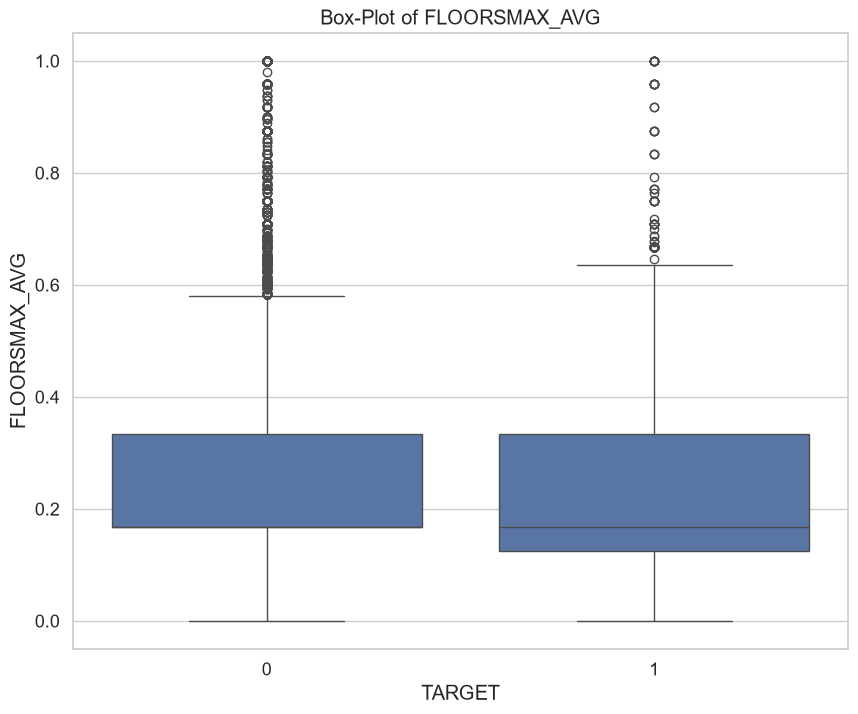

In [40]:
plot_continuous_variables(application_train, 'FLOORSMAX_AVG', plots = ['box'], figsize = (10,8))

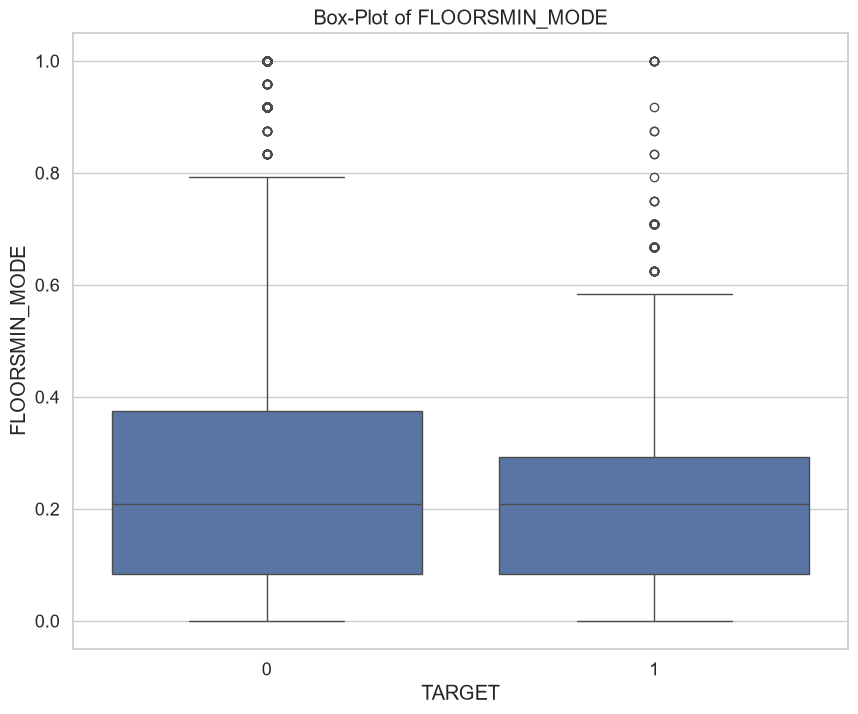

In [41]:
plot_continuous_variables(application_train, 'FLOORSMIN_MODE', plots = ['box'], figsize = (10,8))

##### Quan sát và kết luận

Nhóm vỡ nợ có trung vị FLOORSMAX_AVG thấp hơn nhóm không vỡ nợ; phân vị 25% của nhóm không vỡ nợ thậm chí gần cao hơn trung vị của nhóm vỡ nợ. Nhóm không vỡ nợ cũng có FLOORSMIN_MODE cao hơn, đặc biệt ở phân vị 75%. Hai đặc trưng này có thể hữu ích cho mô hình.

### bureau.csv

##### Mô tả

Bảng này chứa toàn bộ lịch sử tín dụng trước đây của khách hàng tại các tổ chức tài chính khác Home Credit, được báo cáo cho Cục Thông tin Tín dụng.

# ### Số liệu thống kê cơ bản

In [42]:
print(f'The shape of bureau.csv is: {bureau.shape}')
print('-'*100)
print(f'Number of unique SK_ID_BUREAU in bureau.csv are: {len(bureau.SK_ID_BUREAU.unique())}')
print(f'Number of unique SK_ID_CURR in bureau.csv are: {len(bureau.SK_ID_CURR.unique())}')
print(f'Number of overlapping SK_ID_CURR in application_train.csv and bureau.csv are: {len(set(application_train.SK_ID_CURR.unique()).intersection(set(bureau.SK_ID_CURR.unique())))}')
print(f'Number of overlapping SK_ID_CURR in application_test.csv and bureau.csv are: {len(set(application_test.SK_ID_CURR.unique()).intersection(set(bureau.SK_ID_CURR.unique())))}')
print('-'*100)
print(f'Number of duplicate values in bureau: { bureau.duplicated(subset=["SK_ID_BUREAU"]).sum() }')
print('-'*100)
display(bureau.head(5))

The shape of bureau.csv is: (1716428, 17)
----------------------------------------------------------------------------------------------------
Number of unique SK_ID_BUREAU in bureau.csv are: 1716428
Number of unique SK_ID_CURR in bureau.csv are: 305811
Number of overlapping SK_ID_CURR in application_train.csv and bureau.csv are: 263491
Number of overlapping SK_ID_CURR in application_test.csv and bureau.csv are: 42320
----------------------------------------------------------------------------------------------------
Number of duplicate values in bureau: 0
----------------------------------------------------------------------------------------------------


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


<h5>Quan sát và kết luận:</h5>

Bảng bureau.csv có gần 1,7 triệu bản ghi và 17 đặc trưng. SK_ID_BUREAU định danh khoản vay trước đây tại tổ chức khác, còn SK_ID_CURR định danh hồ sơ vay hiện tại tại Home Credit. Có khoảng 305 nghìn SK_ID_CURR duy nhất: 263 nghìn thuộc tập huấn luyện và 42,3 nghìn thuộc tập kiểm tra. Điều này cho thấy một số khách hàng hiện tại không có lịch sử tín dụng được ghi nhận tại Cục Thông tin Tín dụng.

# ### Cột NaN và tỷ lệ phần trăm

----------------------------------------------------------------------------------------------------
Number of columns having NaN values: 7 columns


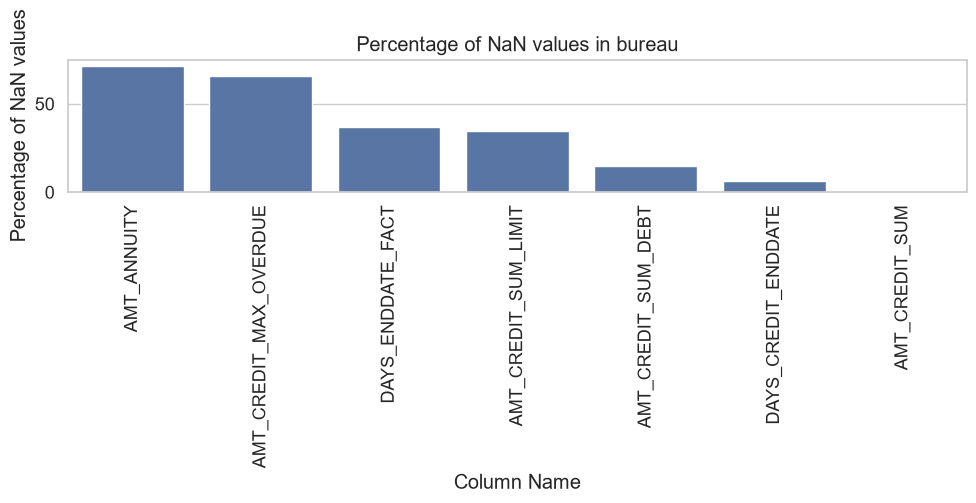

----------------------------------------------------------------------------------------------------


In [43]:
nan_df_bureau = nan_df_create(bureau)
print("-"*100)
plot_nan_percent(nan_df_bureau, 'bureau', tight_layout = False, figsize = (10,5))
print('-'*100)

##### Quan sát và kết luận:

Trong 17 đặc trưng có 7 đặc trưng chứa giá trị NaN. AMT_ANNUITY có tỷ lệ thiếu cao nhất, trên 70%.

<b>Ghép biến TARGET từ application_train vào bảng bureau.</b>

In [44]:
print("-"*100)
print("Merging TARGET with bureau Table")
bureau_merged = application_train.iloc[:,:2].merge(bureau, on = 'SK_ID_CURR', how = 'left')
print("-"*100)

----------------------------------------------------------------------------------------------------
Merging TARGET with bureau Table
----------------------------------------------------------------------------------------------------


#### Ma trận Phi-K

----------------------------------------------------------------------------------------------------


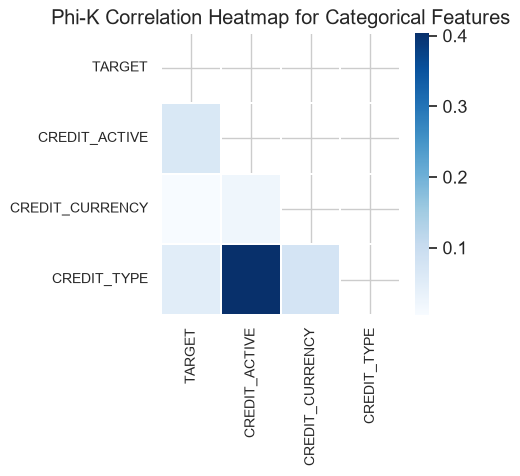

----------------------------------------------------------------------------------------------------
Categories with highest values of Phi-K Correlation value with Target Variable are:


,Column Name,Phik-Correlation
0,CREDIT_ACTIVE,0.064481
2,CREDIT_TYPE,0.049954
1,CREDIT_CURRENCY,0.004993


----------------------------------------------------------------------------------------------------


In [45]:
cols_for_phik = ['TARGET','CREDIT_ACTIVE','CREDIT_CURRENCY','CREDIT_TYPE']
plot_phik_matrix(bureau_merged, cols_for_phik,  figsize = (5,5))

##### Quan sát và kết luận:

Heatmap Phi-K cho thấy CREDIT_TYPE có liên hệ nhất định với CREDIT_ACTIVE. Các biến phân loại nhìn chung không liên hệ mạnh với TARGET, đặc biệt là CREDIT_CURRENCY.

# ### Ma trận tương quan của các tính năng

In [46]:
corr_mat = correlation_matrix(bureau_merged, ['SK_ID_CURR','SK_ID_BUREAU'], cmap = 'Blues', figsize = (12,10))
corr_mat.plot_correlation_matrix()

----------------------------------------------------------------------------------------------------


ValueError: could not convert string to float: 'Closed'

In [ ]:
#Seeing the top columns with highest phik-correlation with the target variable in bureau table
top_corr_target_df = corr_mat.target_top_corr()
print("-" * 100)
print("Columns with highest values of Phik-correlation with Target Variable are:")
display(top_corr_target_df)
print("-"*100)

AttributeError: 'correlation_matrix' object has no attribute 'corr_data'

##### Quan sát và kết luận:

Phần lớn các đặc trưng trong bureau có tương quan thấp. Một số cặp tương quan cao gồm DAYS_CREDIT–DAYS_CREDIT_UPDATE, DAYS_ENDDATE_FACT–DAYS_CREDIT_UPDATE, AMT_CREDIT_SUM–AMT_CREDIT_SUM_DEBT và DAYS_ENDDATE_FACT–DAYS_CREDIT. Tương quan với TARGET nhìn chung thấp, ngoại trừ DAYS_CREDIT, nên chưa thấy quan hệ tuyến tính trực tiếp rõ ràng.

#### Trực quan hóa các biến phân loại

Ta trực quan hóa một số biến phân loại của bảng bureau và xem xét mối liên hệ của chúng với TARGET.

<b><u>Phân phối biến phân loại CREDIT_ACTIVE</u></b>

Cột này mô tả trạng thái khoản vay trước đây được Cục Thông tin Tín dụng báo cáo.

----------------------------------------------------------------------------------------------------
The unique categories of 'CREDIT_ACTIVE' are:
<StringArray>
['Closed', 'Active', nan, 'Sold', 'Bad debt']
Length: 5, dtype: str
----------------------------------------------------------------------------------------------------
Counts of each category are:
CREDIT_ACTIVE
Closed      917733
Active      541919
Sold          5653
Bad debt        20
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Total Number of unique categories of CREDIT_ACTIVE = 5


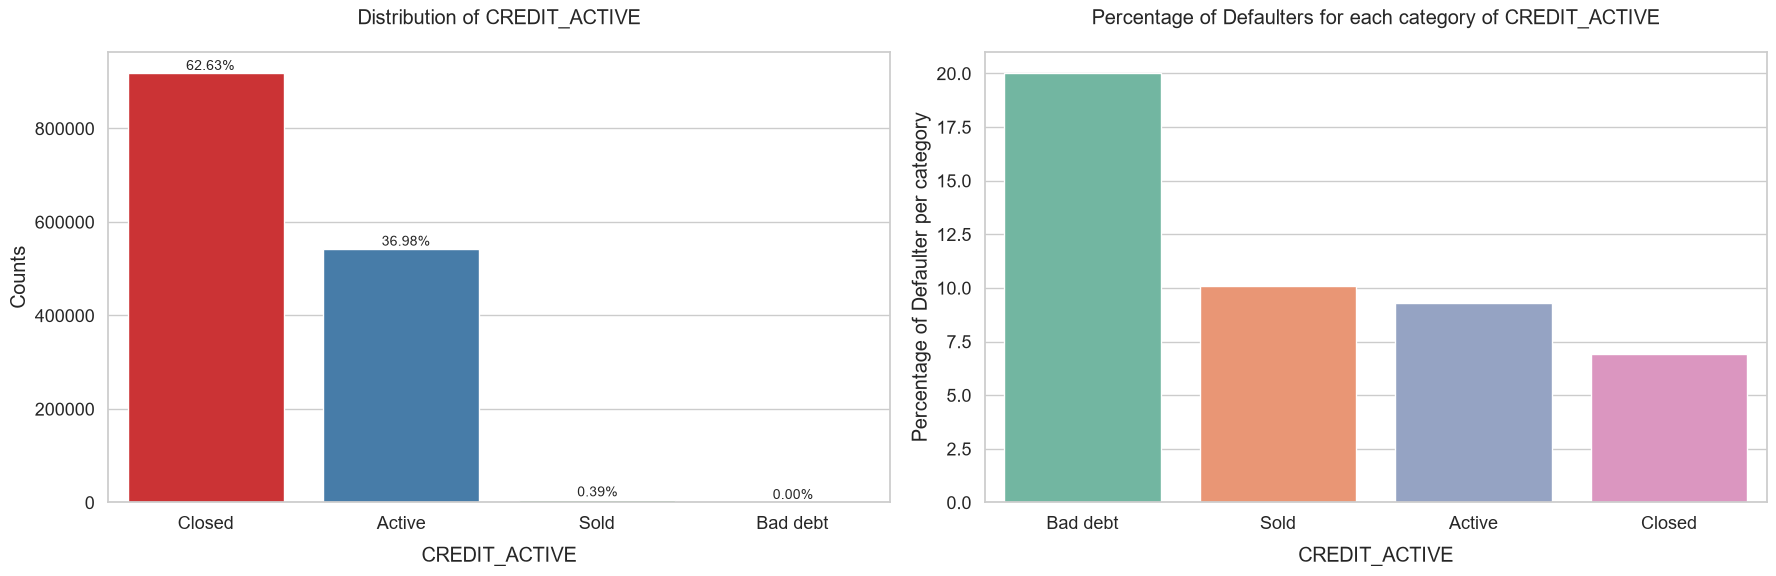

----------------------------------------------------------------------------------------------------


In [ ]:
#let us first see the unique categories of 'CREDIT_ACTIVE'
print_unique_categories(bureau_merged, 'CREDIT_ACTIVE', show_counts = True)

# plotting the Bar Plot for the Column
plot_categorical_variables_bar(bureau_merged, column_name = 'CREDIT_ACTIVE', horizontal_adjust = 0.3, fontsize_percent = 'x-small')
print('-'*100)

##### Quan sát và kết luận:

Phần lớn các khoản vay trước đây đã đóng (62,63%), tiếp theo là khoản vay đang hoạt động (36,98%); khoản vay đã bán và nợ xấu rất ít. Nhóm nợ xấu có tỷ lệ vỡ nợ cao nhất, khoảng 20%, tiếp đến là khoản vay đã bán và đang hoạt động. Khoản vay đã đóng có tỷ lệ vỡ nợ thấp nhất, phù hợp với kỳ vọng về một lịch sử tín dụng tốt.

#### Trực quan hóa các biến liên tục

<u><b>Phân phối các biến liên tục thuộc nhóm DAYS</b></u>

<b>DAYS_CREDIT</b>

Cột này biểu thị số ngày từ lúc khách hàng đăng ký khoản tín dụng tại Cục Thông tin Tín dụng đến hồ sơ hiện tại. Ta chuyển số ngày sang năm để dễ diễn giải.

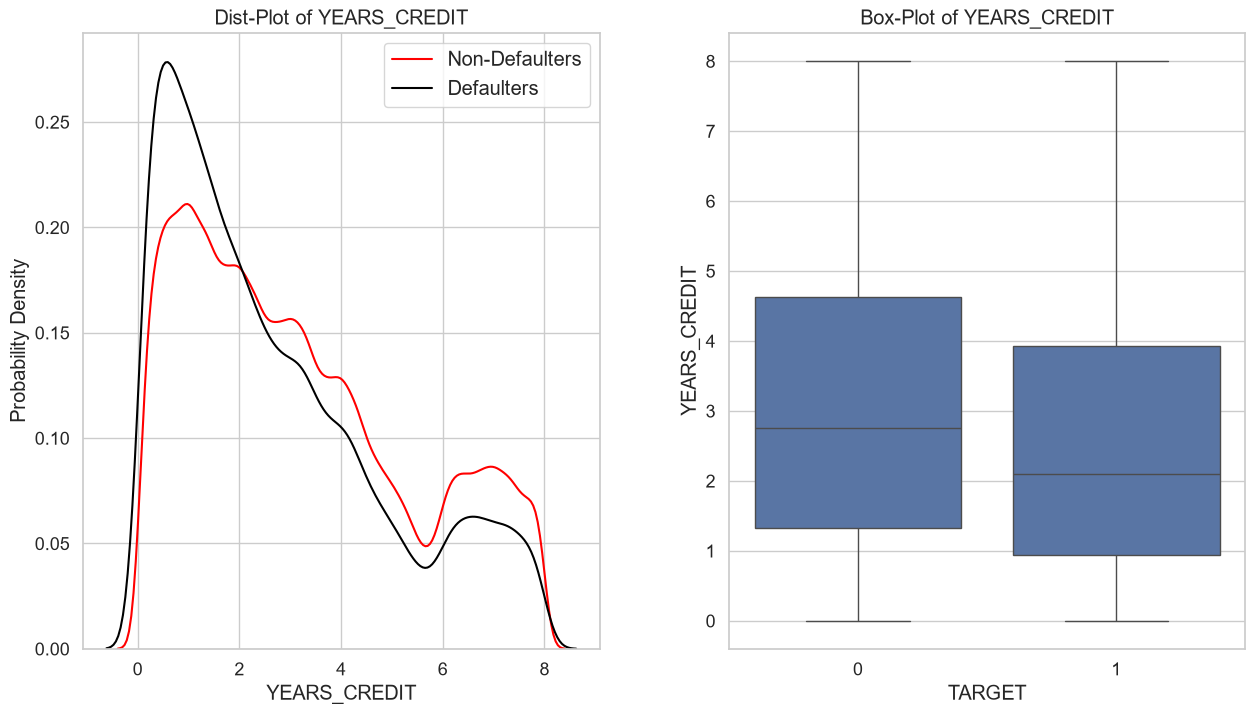

In [ ]:
bureau_merged['YEARS_CREDIT'] = bureau_merged['DAYS_CREDIT'] / -365
plot_continuous_variables(bureau_merged, 'YEARS_CREDIT', plots = ['distplot', 'box'], figsize = (15,8))
_ = bureau_merged.pop('YEARS_CREDIT')

##### Quan sát và kết luận:

Nhóm vỡ nợ tập trung nhiều hơn ở các khoản tín dụng được mở gần đây; phân phối của nhóm này dịch về bên trái. Box plot cũng cho thấy YEARS_CREDIT của nhóm vỡ nợ thường thấp hơn nhóm không vỡ nợ.

<b>DAYS_CREDIT_ENDDATE</b>

Cột này cho biết thời hạn còn lại của khoản tín dụng tại thời điểm khách hàng đăng ký vay ở Home Credit.

----------------------------------------------------------------------------------------------------
The 0th percentile value of DAYS_CREDIT_ENDDATE is -42060.0
The 2th percentile value of DAYS_CREDIT_ENDDATE is -2487.0
The 4th percentile value of DAYS_CREDIT_ENDDATE is -2334.0
The 6th percentile value of DAYS_CREDIT_ENDDATE is -2202.0
The 8th percentile value of DAYS_CREDIT_ENDDATE is -2073.9199999999983
The 10th percentile value of DAYS_CREDIT_ENDDATE is -1939.0
The 25th percentile value of DAYS_CREDIT_ENDDATE is -1144.0
The 50th percentile value of DAYS_CREDIT_ENDDATE is -334.0
The 75th percentile value of DAYS_CREDIT_ENDDATE is 473.0
The 100th percentile value of DAYS_CREDIT_ENDDATE is 31199.0
----------------------------------------------------------------------------------------------------


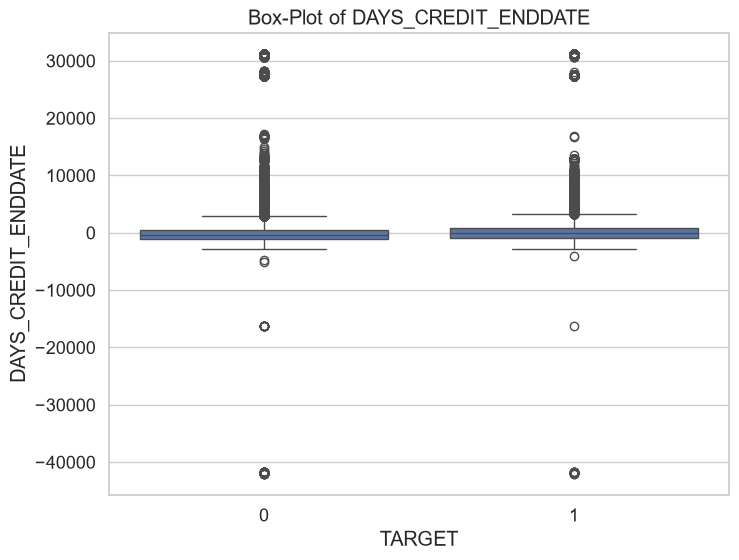

----------------------------------------------------------------------------------------------------


In [ ]:
print_percentiles(bureau_merged, 'DAYS_CREDIT_ENDDATE', percentiles = list(range(0,11,2)) + [25,50,75,100])
plot_continuous_variables(bureau_merged, 'DAYS_CREDIT_ENDDATE', plots = ['box'], figsize = (8,6))
print('-'*100)

##### Quan sát và kết luận:

Giá trị nhỏ nhất của DAYS_CREDIT_ENDDATE lên tới 42.060 ngày, tương đương khoảng 115 năm, nên rất có thể là dữ liệu sai. Các giá trị này cần được xử lý trong bước tiền xử lý.

<b>DAYS_ENDDATE_FACT</b>

Cột này cho biết khoản tín dụng đã kết thúc cách ngày đăng ký vay tại Home Credit bao nhiêu ngày; chỉ áp dụng cho các khoản tín dụng đã đóng.

----------------------------------------------------------------------------------------------------
The 0th percentile value of DAYS_ENDDATE_FACT is -42023.0
The 2th percentile value of DAYS_ENDDATE_FACT is -2561.0
The 4th percentile value of DAYS_ENDDATE_FACT is -2450.0
The 6th percentile value of DAYS_ENDDATE_FACT is -2351.0
The 8th percentile value of DAYS_ENDDATE_FACT is -2265.0
The 10th percentile value of DAYS_ENDDATE_FACT is -2173.0
The 25th percentile value of DAYS_ENDDATE_FACT is -1503.0
The 50th percentile value of DAYS_ENDDATE_FACT is -900.0
The 75th percentile value of DAYS_ENDDATE_FACT is -427.0
The 100th percentile value of DAYS_ENDDATE_FACT is 0.0
----------------------------------------------------------------------------------------------------


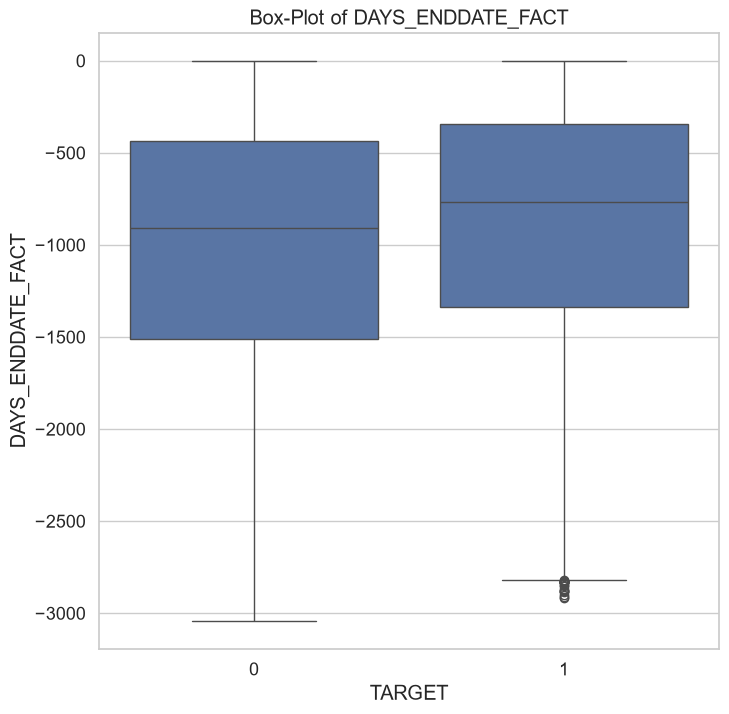

----------------------------------------------------------------------------------------------------


In [ ]:
print_percentiles(bureau_merged, 'DAYS_ENDDATE_FACT', percentiles = list(range(0,11,2)) + [25,50,75,100])
plot_continuous_variables(bureau_merged, 'DAYS_ENDDATE_FACT', plots = ['box'], figsize = (8,8), scale_limits = [-40000, 0])
print('-'*100)

##### Quan sát và kết luận:

Giá trị nhỏ nhất khoảng 42.023 ngày (gần 115 năm) là bất hợp lý và cần được xử lý. Box plot cho thấy khoản tín dụng trước đây của nhóm vỡ nợ thường kết thúc gần ngày đăng ký hiện tại hơn so với nhóm không vỡ nợ.

<b>DAYS_CREDIT_UPDATE</b>

Cột này cho biết thông tin tín dụng từ Cục Thông tin Tín dụng được cập nhật cách ngày đăng ký hiện tại bao nhiêu ngày.

----------------------------------------------------------------------------------------------------
The 0th percentile value of DAYS_CREDIT_UPDATE is -41947.0
The 2th percentile value of DAYS_CREDIT_UPDATE is -2415.0
The 4th percentile value of DAYS_CREDIT_UPDATE is -2213.0
The 6th percentile value of DAYS_CREDIT_UPDATE is -2002.0
The 8th percentile value of DAYS_CREDIT_UPDATE is -1766.0
The 10th percentile value of DAYS_CREDIT_UPDATE is -1582.0
The 25th percentile value of DAYS_CREDIT_UPDATE is -904.0
The 50th percentile value of DAYS_CREDIT_UPDATE is -406.0
The 75th percentile value of DAYS_CREDIT_UPDATE is -33.0
The 100th percentile value of DAYS_CREDIT_UPDATE is 372.0
----------------------------------------------------------------------------------------------------


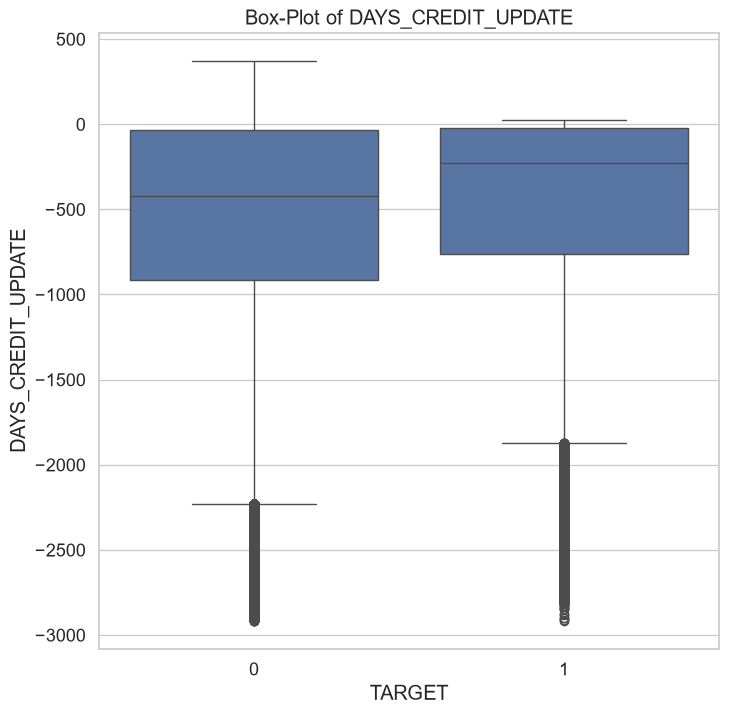

----------------------------------------------------------------------------------------------------


In [ ]:
print_percentiles(bureau_merged, 'DAYS_CREDIT_UPDATE', percentiles = list(range(0,11,2)) + [25,50,75,100])
plot_continuous_variables(bureau_merged, 'DAYS_CREDIT_UPDATE', plots = ['box'], figsize = (8,8), scale_limits = [-40000, 400])
print('-'*100)

##### Quan sát và kết luận:

Giá trị ở phân vị 0% bất thường trong khi các phân vị còn lại hợp lý, vì vậy cần loại hoặc sửa giá trị này. Nhóm vỡ nợ có thông tin tín dụng được cập nhật gần đây hơn, thể hiện qua trung vị và phân vị 75% thấp hơn nhóm không vỡ nợ.

### bureau_balance.csv

##### Mô tả

Bảng này chứa số dư hằng tháng của từng khoản tín dụng trước đây tại các tổ chức tài chính khác Home Credit.

<h4>Thống kê cơ bản</h4>

In [ ]:
print(f'The shape of bureau_balance.csv is: {bureau_balance.shape}')
print('-'*100)
print(f'Number of duplicate values in bureau_balance: {bureau_balance.shape[0] - bureau_balance.duplicated().shape[0]}')
print('-'*100)
display(bureau_balance.head(5))

The shape of bureau_balance.csv is: (27299925, 3)
----------------------------------------------------------------------------------------------------
Number of duplicate values in bureau_balance: 0
----------------------------------------------------------------------------------------------------


,SK_ID_BUREAU,MONTHS_BALANCE,STATUS
0,5715448,0,C
1,5715448,-1,C
2,5715448,-2,C
3,5715448,-3,C
4,5715448,-4,C


In [ ]:
print("-"*100)
print(f'Number of unique SK_ID_BUREAU in bureau_balance.csv are: {len(bureau_balance.SK_ID_BUREAU.unique())}')
print('-'*100)
print(f'Number of unique values for STATUS are: {len(bureau_balance.STATUS.unique())}')
print(f"Unique values of STATUS are:\n{bureau_balance.STATUS.unique()}")
print('-'*100)
print(f"Max number of months for Months Balance: {np.abs(bureau_balance.MONTHS_BALANCE.min())}")
print('-'*100)

----------------------------------------------------------------------------------------------------
Number of unique SK_ID_BUREAU in bureau_balance.csv are: 817395
----------------------------------------------------------------------------------------------------
Number of unique values for STATUS are: 8
Unique values of STATUS are:
<StringArray>
['C', '0', 'X', '1', '2', '3', '5', '4']
Length: 8, dtype: str
----------------------------------------------------------------------------------------------------
Max number of months for Months Balance: 96
----------------------------------------------------------------------------------------------------


In [ ]:
orphan_id_count = (
    ~bureau_balance["SK_ID_BUREAU"]
    .drop_duplicates()
    .isin(bureau["SK_ID_BUREAU"])
).sum()

print(f"Số SK_ID_BUREAU không tồn tại trong bureau: {orphan_id_count:,}")

Số SK_ID_BUREAU không tồn tại trong bureau: 43,041


##### Quan sát và kết luận

Bảng bureau_balance.csv có khoảng 27,29 triệu dòng và 3 cột, ghi lại trạng thái hằng tháng của từng khoản vay trước đây. STATUS có 8 mã: C là đã đóng, X là không rõ, 0 là không quá hạn, 1–5 biểu thị các mức số ngày quá hạn tăng dần. Lịch sử xa nhất là 96 tháng, tương đương 8 năm.

<h4>Các cột NaN và tỷ lệ phần trăm</h4>

In [ ]:
plot_nan_percent(nan_df_create(bureau_balance), 'bureau_balance')

The dataframe bureau_balance does not contain any NaN values.


### previous_application.csv

##### Mô tả

Bảng này chứa thông tin về các hồ sơ vay trước đây của khách hàng tại Home Credit.

# ### Số liệu thống kê cơ bản

In [ ]:
print(f'The shape of previous_application.csv is: {previous_application.shape}')
print('-'*100)
print(f'Number of unique SK_ID_PREV in previous_application.csv are: {len(previous_application.SK_ID_PREV.unique())}')
print(f'Number of unique SK_ID_CURR in previous_application.csv are: {len(previous_application.SK_ID_CURR.unique())}')
print('-'*100)
print(f'Number of overlapping SK_ID_CURR in application_train.csv and previous_application.csv are: {len(set(application_train.SK_ID_CURR.unique()).intersection(set(previous_application.SK_ID_CURR.unique())))}')
print(f'Number of overlapping SK_ID_CURR in application_test.csv and previous_application.csv are: {len(set(application_test.SK_ID_CURR.unique()).intersection(set(previous_application.SK_ID_CURR.unique())))}')
print('-'*100)
print(f'Number of duplicate values in previous_application: {previous_application.duplicated(subset=["SK_ID_PREV"]).sum()}')
print('-'*100)
display(previous_application.head(5))

The shape of previous_application.csv is: (1670214, 37)
----------------------------------------------------------------------------------------------------
Number of unique SK_ID_PREV in previous_application.csv are: 1670214
Number of unique SK_ID_CURR in previous_application.csv are: 338857
----------------------------------------------------------------------------------------------------
Number of overlapping SK_ID_CURR in application_train.csv and previous_application.csv are: 291057
Number of overlapping SK_ID_CURR in application_test.csv and previous_application.csv are: 47800
----------------------------------------------------------------------------------------------------
Number of duplicate values in previous_application: 0
----------------------------------------------------------------------------------------------------


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


##### Quan sát và kết luận:

Bảng previous_application.csv có khoảng 1,67 triệu bản ghi, 37 đặc trưng và 1,67 triệu SK_ID_PREV duy nhất, tương ứng mỗi dòng là một hồ sơ trước đây. Có khoảng 338 nghìn SK_ID_CURR; trong đó khoảng 291 nghìn thuộc tập huấn luyện và 47,8 nghìn thuộc tập kiểm tra.

# ### Cột NaN và tỷ lệ phần trăm

----------------------------------------------------------------------------------------------------
Number of columns having NaN values: 16 columns


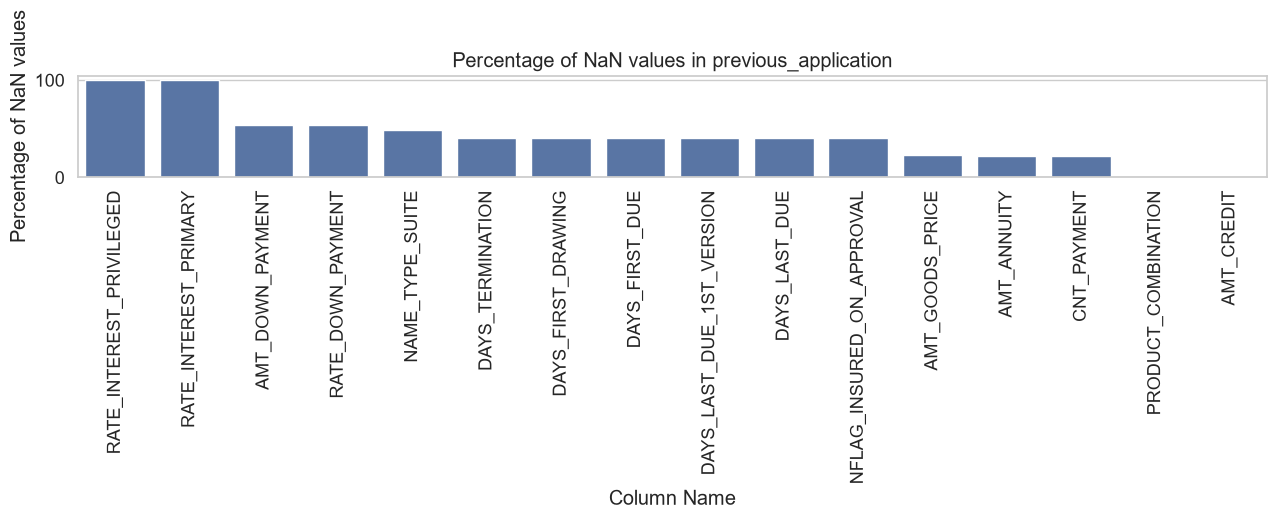

----------------------------------------------------------------------------------------------------


In [ ]:
previous_application_nan = nan_df_create(previous_application)
print('-' * 100)
plot_nan_percent(previous_application_nan, 'previous_application', tight_layout = False, figsize = (13,5))
print('-' * 100)
del previous_application_nan

##### Quan sát và kết luận

Trong 37 đặc trưng có 16 cột chứa NaN. RATE_INTEREST_PRIMARY và RATE_INTEREST_PRIVILEGED thiếu gần như toàn bộ (khoảng 99,6%); một số cột ngày và AMT_DOWN_PAYMENT cũng có tỷ lệ thiếu đáng kể.

<b>Ghép biến TARGET từ application_train vào bảng previous_application.</b>

In [ ]:
print("-"*100)
print("Merging TARGET with previous_application Table")
prev_merged = application_train.iloc[:,:2].merge(previous_application, on = 'SK_ID_CURR', how = 'left')
print("-"*100)

----------------------------------------------------------------------------------------------------
Merging TARGET with previous_application Table
----------------------------------------------------------------------------------------------------


#### Ma trận Phi-K

In [ ]:
cols_for_phik = ['TARGET'] + prev_merged.dtypes[prev_merged.dtypes == 'object'].index.tolist() + ['NFLAG_INSURED_ON_APPROVAL']
plot_phik_matrix(prev_merged, cols_for_phik, cmap = 'Blues', figsize = (11,9), fontsize = 9)

##### Quan sát và kết luận:

Ma trận Phi-K cho thấy một số biến phân loại có liên hệ mạnh với nhau, đặc biệt NAME_CONTRACT_STATUS với CODE_REJECT_REASON và NAME_PRODUCT_TYPE với PRODUCT_COMBINATION. Mối liên hệ với TARGET nhìn chung yếu.

# ### Ma trận tương quan của các tính năng

In [ ]:
corr_mat = correlation_matrix(prev_merged, ['SK_ID_CURR','SK_ID_PREV','NFLAG_INSURED_ON_APPROVAL'], cmap = 'Blues', figsize = (14,12))
corr_mat.plot_correlation_matrix()

----------------------------------------------------------------------------------------------------


ValueError: could not convert string to float: 'Consumer loans'

In [ ]:
#Seeing the top columns with highest phik-correlation with the target variable in previous_applications table
top_corr_target_df = corr_mat.target_top_corr()
print("-" * 100)
print("Columns with highest values of Phik-correlation with Target Variable are:")
display(top_corr_target_df)
print("-"*100)

##### Quan sát và kết luận:

Phần lớn biến số có tương quan thấp. Các nhóm tương quan cao chủ yếu là những đại lượng cùng bản chất, chẳng hạn AMT_APPLICATION–AMT_CREDIT, AMT_ANNUITY–AMT_CREDIT và các cột DAYS liên quan đến thời điểm đến hạn/kết thúc. Tương quan tuyến tính với TARGET không đáng kể.

#### Trực quan hóa các biến phân loại

Ta trực quan hóa một số biến phân loại trong previous_application và xem xét ảnh hưởng của chúng tới TARGET.

<b><u>Phân phối biến phân loại NAME_CONTRACT_TYPE</u></b>

Cột này mô tả loại hợp đồng của khoản vay trước đây tại Home Credit.

----------------------------------------------------------------------------------------------------
The unique categories of 'NAME_CONTRACT_TYPE' are:
<StringArray>
['Consumer loans', 'Cash loans', 'Revolving loans', nan, 'XNA']
Length: 5, dtype: str
----------------------------------------------------------------------------------------------------
Counts of each category are:
NAME_CONTRACT_TYPE
Cash loans         626764
Consumer loans     625256
Revolving loans    161368
XNA                   313
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Total Number of unique categories of NAME_CONTRACT_TYPE = 5


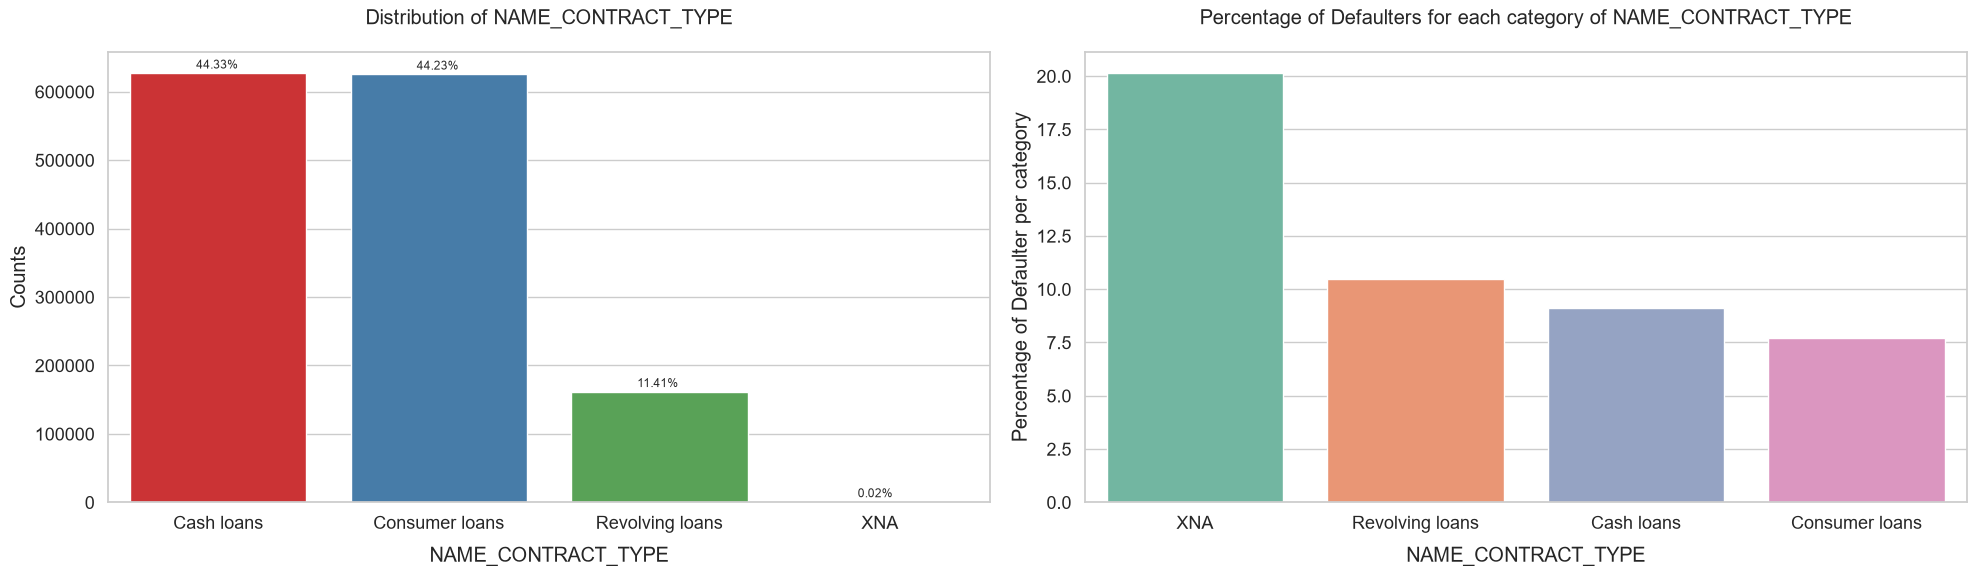

----------------------------------------------------------------------------------------------------


In [ ]:
#let us first see the unique categories of 'NAME_CONTRACT_TYPE'
print_unique_categories(prev_merged, 'NAME_CONTRACT_TYPE', show_counts = True)

# plotting the Bar Plot for the Column
plot_categorical_variables_bar(prev_merged, 'NAME_CONTRACT_TYPE', horizontal_adjust = 0.3, figsize = (20, 6))
print('-'*100)

##### Quan sát và kết luận:

Khoản vay tiền mặt và vay tiêu dùng chiếm gần như toàn bộ hồ sơ trước đây; khoản vay quay vòng ít hơn nhiều. Nhóm từng đăng ký vay tiền mặt có tỷ lệ vỡ nợ cao nhất, còn vay tiêu dùng thấp hơn.

<b><u>Phân phối biến phân loại NAME_CONTRACT_STATUS</u></b>

Cột này mô tả trạng thái của hồ sơ vay trước đây.

----------------------------------------------------------------------------------------------------
The unique categories of 'NAME_CONTRACT_STATUS' are:
<StringArray>
['Approved', 'Canceled', 'Refused', nan, 'Unused offer']
Length: 5, dtype: str
----------------------------------------------------------------------------------------------------
Total Number of unique categories of NAME_CONTRACT_STATUS = 5


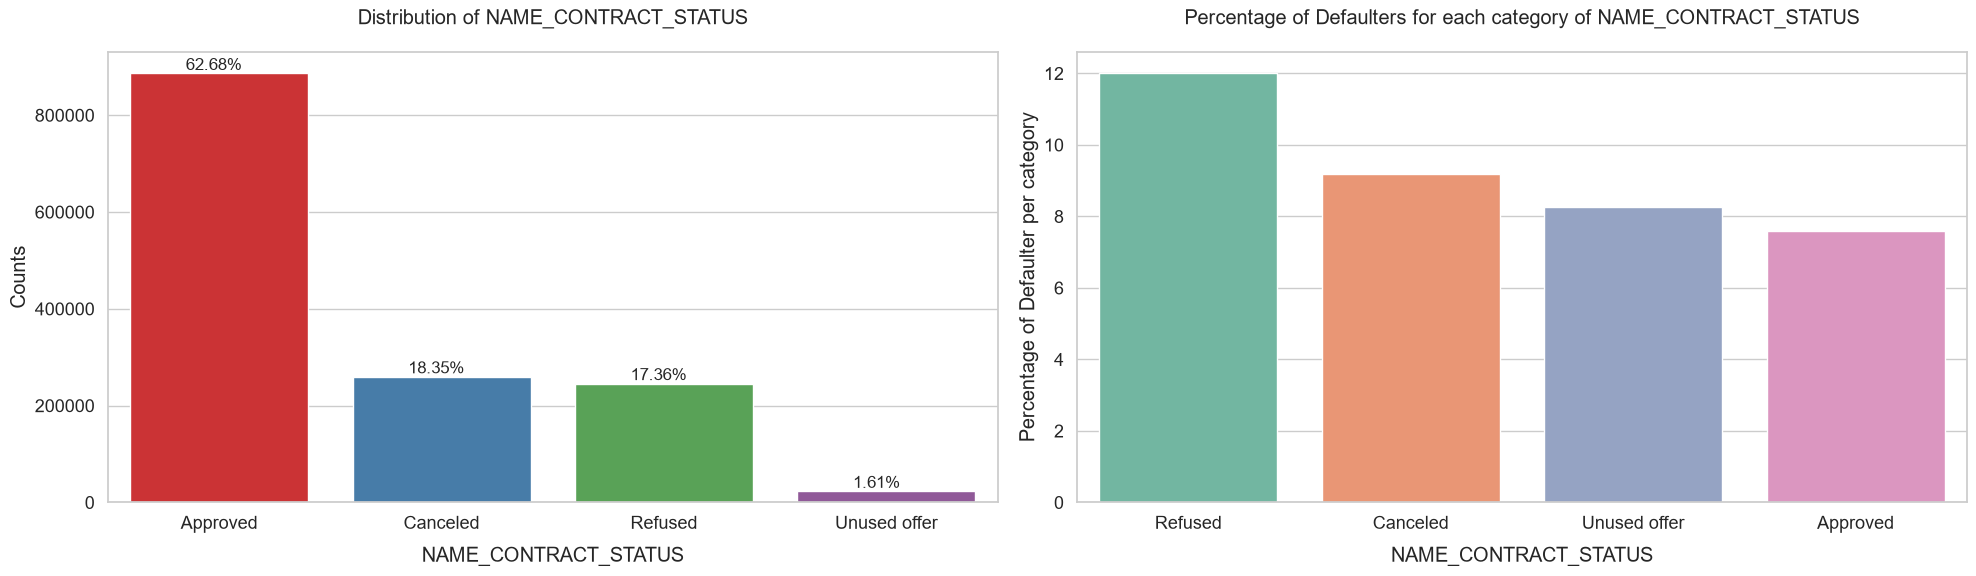

----------------------------------------------------------------------------------------------------


In [ ]:
#let us first see the unique categories of 'NAME_CONTRACT_STATUS'
print_unique_categories(prev_merged, 'NAME_CONTRACT_STATUS')

# plotting the Bar Plot for the Column
plot_categorical_variables_bar(prev_merged, 'NAME_CONTRACT_STATUS', horizontal_adjust = 0.25, figsize = (20, 6), fontsize_percent = 'small')
print('-'*100)

##### Quan sát và kết luận:

Phần lớn hồ sơ trước đây được chấp thuận, tiếp theo là bị hủy và bị từ chối. Nhóm có hồ sơ trước đây bị từ chối có tỷ lệ vỡ nợ cao nhất, còn nhóm được chấp thuận có tỷ lệ thấp nhất; kết quả này phù hợp với kỳ vọng về mức độ tín nhiệm.

<b><u>Phân phối biến phân loại CODE_REJECT_REASON</u></b>

Cột này mô tả lý do hồ sơ vay trước đây tại Home Credit bị từ chối.

----------------------------------------------------------------------------------------------------
The unique categories of 'CODE_REJECT_REASON' are:
<StringArray>
['XAP', 'LIMIT', nan, 'HC', 'SCO', 'SCOFR', 'VERIF', 'CLIENT', 'XNA',
 'SYSTEM']
Length: 10, dtype: str
----------------------------------------------------------------------------------------------------
Counts of each category are:
CODE_REJECT_REASON
XAP       1145533
HC         145984
LIMIT       47773
SCO         32636
CLIENT      22771
SCOFR       10875
XNA          4378
VERIF        3079
SYSTEM        672
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Total Number of unique categories of CODE_REJECT_REASON = 10


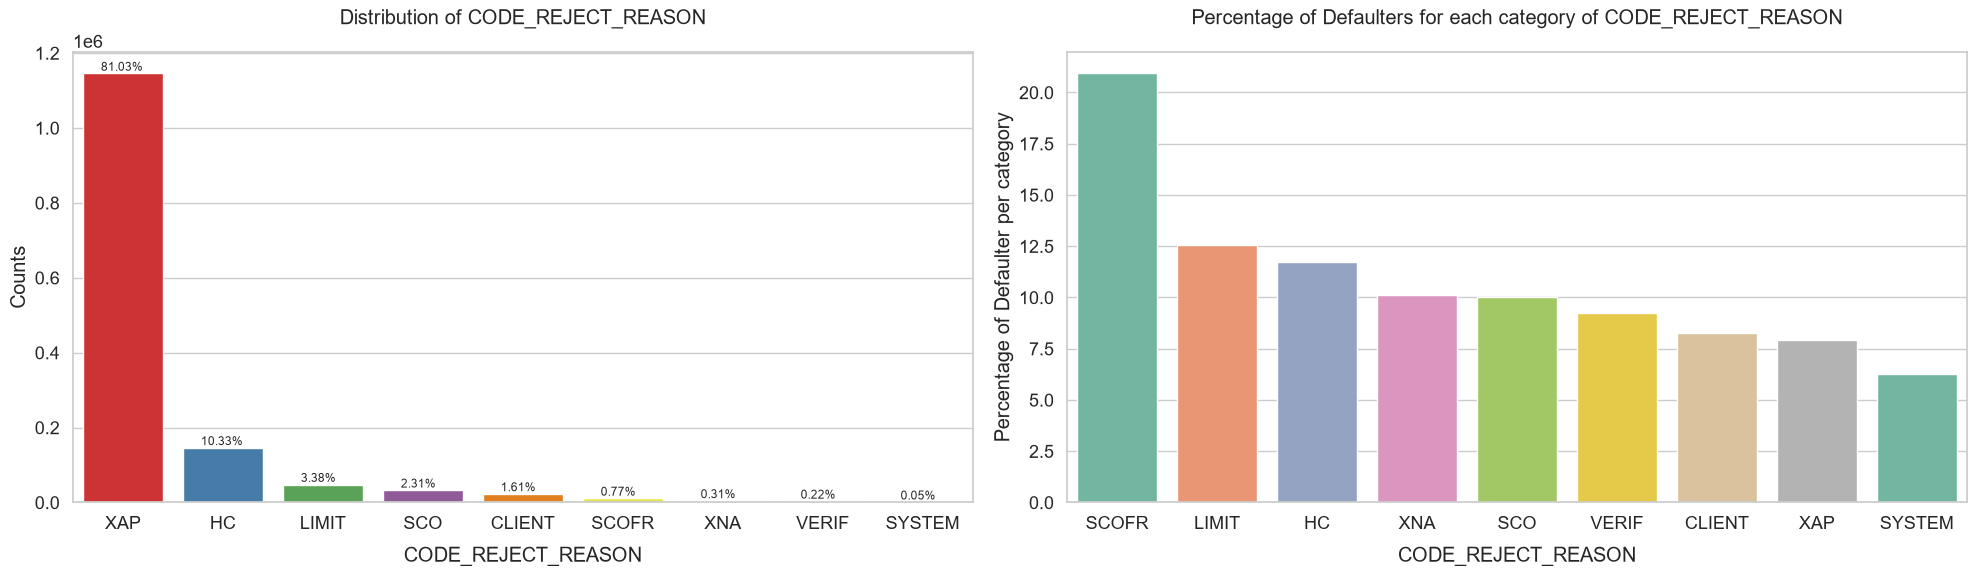

----------------------------------------------------------------------------------------------------


In [ ]:
#let us first see the unique categories of 'CODE_REJECT_REASON'
print_unique_categories(prev_merged, 'CODE_REJECT_REASON', show_counts = True)

# plotting the Bar Plot for the Column
plot_categorical_variables_bar(prev_merged, 'CODE_REJECT_REASON', horizontal_adjust = 0.18, figsize = (20, 6))
print('-'*100)

##### Quan sát và kết luận:

XAP là mã phổ biến nhất (khoảng 81%), còn HC đứng thứ hai với 10,33%. Nhóm bị từ chối bởi mã SCOFR có tỷ lệ vỡ nợ cao nhất (khoảng 21%), tiếp theo là LIMIT và HC. XAP chỉ có khoảng 7,5% vỡ nợ và thấp thứ hai sau SYSTEM.

<b><u>Phân phối biến phân loại CHANNEL_TYPE</u></b>

Cột này mô tả kênh tiếp cận khách hàng cho khoản vay trước đây.

----------------------------------------------------------------------------------------------------
The unique categories of 'CHANNEL_TYPE' are:
<StringArray>
[                     'Stone',    'Credit and cash offices',
               'Country-wide',           'Regional / Local',
            'AP+ (Cash loan)',             'Contact center',
                          nan, 'Channel of corporate sales',
                 'Car dealer']
Length: 9, dtype: str
----------------------------------------------------------------------------------------------------
Total Number of unique categories of CHANNEL_TYPE = 9


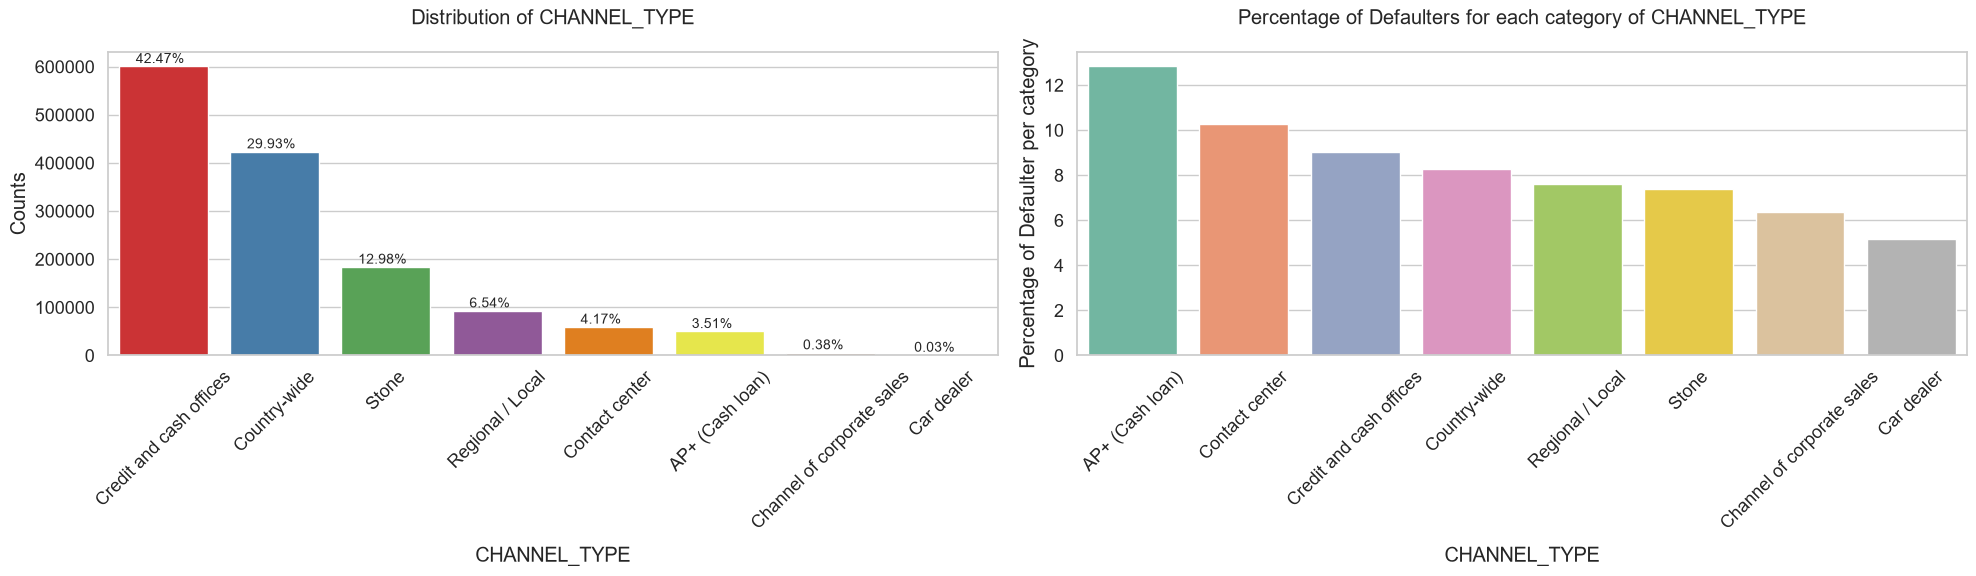

----------------------------------------------------------------------------------------------------


In [ ]:
#let us first see the unique categories of 'CHANNEL_TYPE'
print_unique_categories(prev_merged, 'CHANNEL_TYPE')

# plotting the Bar Plot for the Column
plot_categorical_variables_bar(prev_merged, 'CHANNEL_TYPE', horizontal_adjust = 0.15, rotation = 45, figsize = (20, 6), fontsize_percent = 'x-small')
print('-'*100)

##### Quan sát và kết luận

Khoảng 42,47% hồ sơ đến từ văn phòng tín dụng và tiền mặt, tiếp theo là kênh toàn quốc với 29,93%. Kênh AP+ (vay tiền mặt) có tỷ lệ vỡ nợ cao nhất, khoảng 13%, còn đại lý ô tô thấp nhất, khoảng 5%.

<b><u>Phân phối biến phân loại PRODUCT_COMBINATION</u></b>

Cột này cung cấp thông tin về tổ hợp sản phẩm của các hồ sơ trước đây.

----------------------------------------------------------------------------------------------------
The unique categories of 'PRODUCT_COMBINATION' are:
<StringArray>
[       'POS other with interest',               'Cash X-Sell: low',
     'POS industry with interest',    'POS household with interest',
    'POS mobile without interest',                    'Card Street',
                    'Card X-Sell',              'Cash X-Sell: high',
                           'Cash',              'Cash Street: high',
            'Cash X-Sell: middle',       'POS mobile with interest',
 'POS household without interest',  'POS industry without interest',
               'Cash Street: low',                              nan,
            'Cash Street: middle',    'POS others without interest']
Length: 18, dtype: str
----------------------------------------------------------------------------------------------------
Total Number of unique categories of PRODUCT_COMBINATION = 18


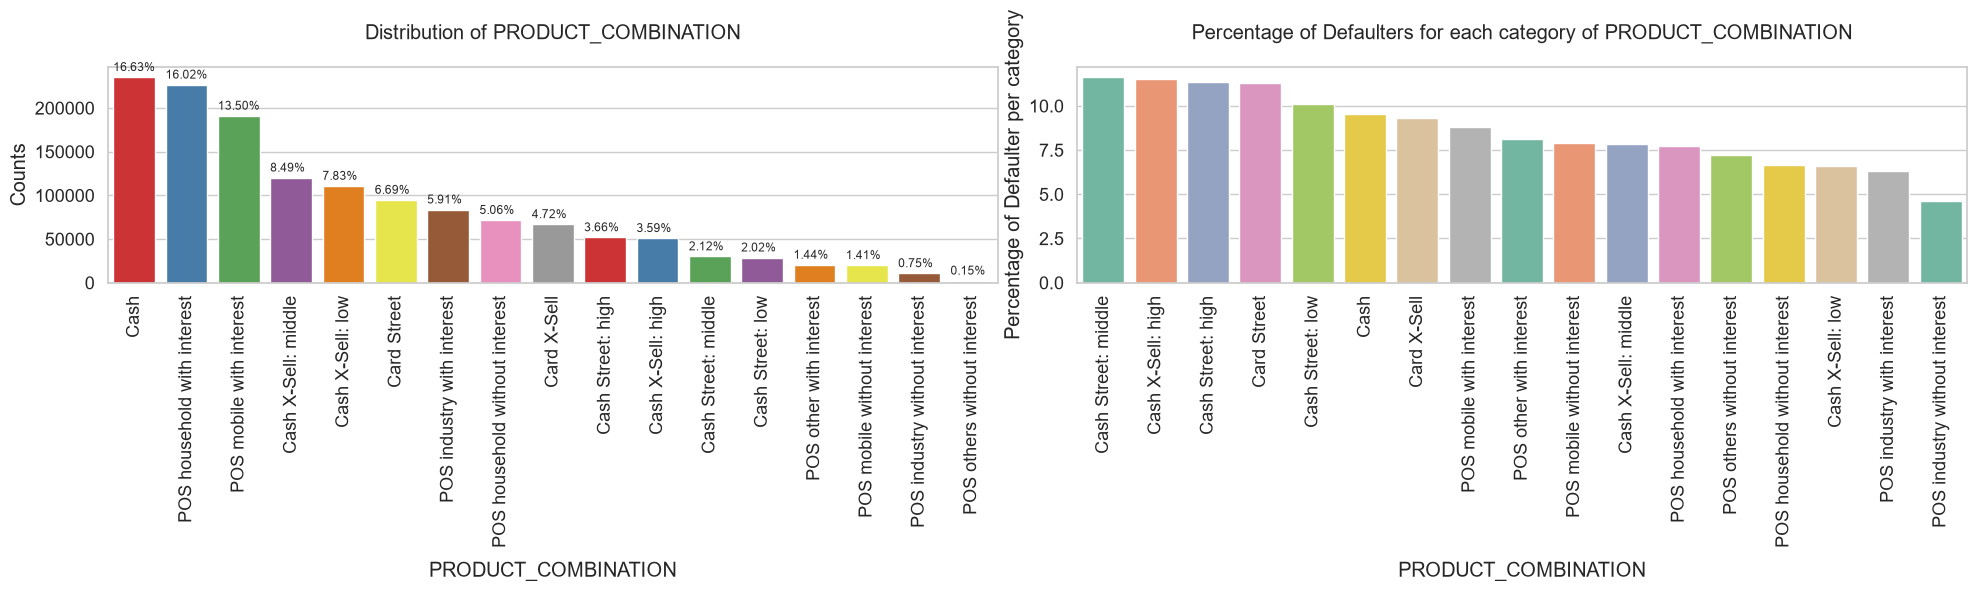

----------------------------------------------------------------------------------------------------


In [ ]:
#let us first see the unique categories of 'PRODUCT_COMBINATION'
print_unique_categories(prev_merged, 'PRODUCT_COMBINATION')

# plotting the Bar Plot for the Column
plot_categorical_variables_bar(prev_merged, 'PRODUCT_COMBINATION', rotation = 90, figsize = (20, 6))
print('-'*100)

##### Quan sát và kết luận

Ba tổ hợp phổ biến nhất là Cash, POS household with interest và POS mobile with interest, chiếm khoảng 50% hồ sơ. Các nhóm Cash Street: mobile, Cash X-sell: high, Cash Street: high và Card Street có tỷ lệ vỡ nợ cao nhất (khoảng 11–11,5%); POS Industry without interest thấp nhất (khoảng 4,5%).

#### Trực quan hóa các biến liên tục

<u><b>Phân phối các biến liên tục thuộc nhóm DAYS</b></u>

<b>DAYS_DECISION</b>

Cột này cho biết quyết định về hồ sơ trước đây được đưa ra cách hồ sơ hiện tại bao nhiêu ngày.

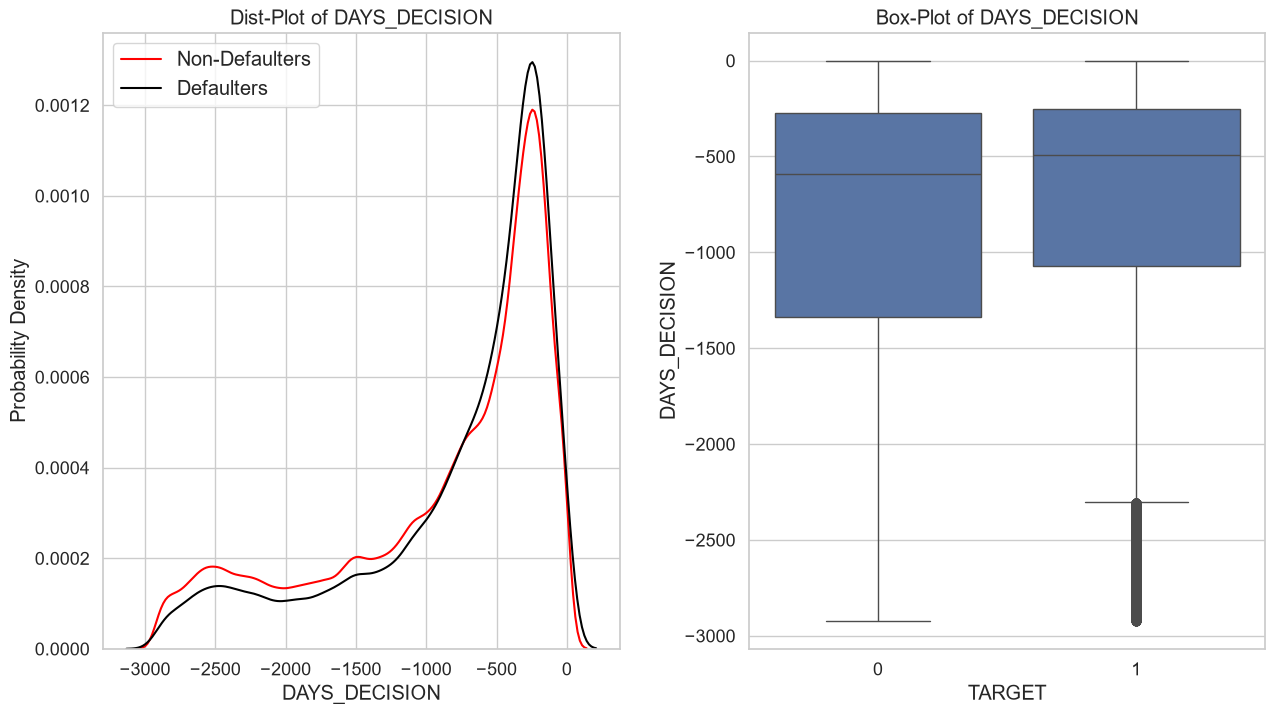

In [ ]:
plot_continuous_variables(prev_merged, 'DAYS_DECISION', plots = ['distplot', 'box'], figsize = (15,8))

##### Quan sát và kết luận

Quyết định về hồ sơ trước đây của nhóm vỡ nợ thường được đưa ra gần đây hơn so với nhóm không vỡ nợ.

<b>DAYS_FIRST_DRAWING</b>

Cột này cho biết lần giải ngân đầu tiên của hồ sơ trước đây cách hồ sơ hiện tại bao nhiêu ngày.

----------------------------------------------------------------------------------------------------
The 0th percentile value of DAYS_FIRST_DRAWING is -2922.0
The 1th percentile value of DAYS_FIRST_DRAWING is -2451.0
The 2th percentile value of DAYS_FIRST_DRAWING is -1179.0
The 3th percentile value of DAYS_FIRST_DRAWING is -674.0
The 4th percentile value of DAYS_FIRST_DRAWING is -406.0
The 5th percentile value of DAYS_FIRST_DRAWING is -262.0
The 6th percentile value of DAYS_FIRST_DRAWING is -156.0
The 7th percentile value of DAYS_FIRST_DRAWING is 365243.0
The 8th percentile value of DAYS_FIRST_DRAWING is 365243.0
The 9th percentile value of DAYS_FIRST_DRAWING is 365243.0
The 10th percentile value of DAYS_FIRST_DRAWING is 365243.0
The 20th percentile value of DAYS_FIRST_DRAWING is 365243.0
The 40th percentile value of DAYS_FIRST_DRAWING is 365243.0
The 60th percentile value of DAYS_FIRST_DRAWING is 365243.0
The 80th percentile value of DAYS_FIRST_DRAWING is 365243.0
The 100th percentile

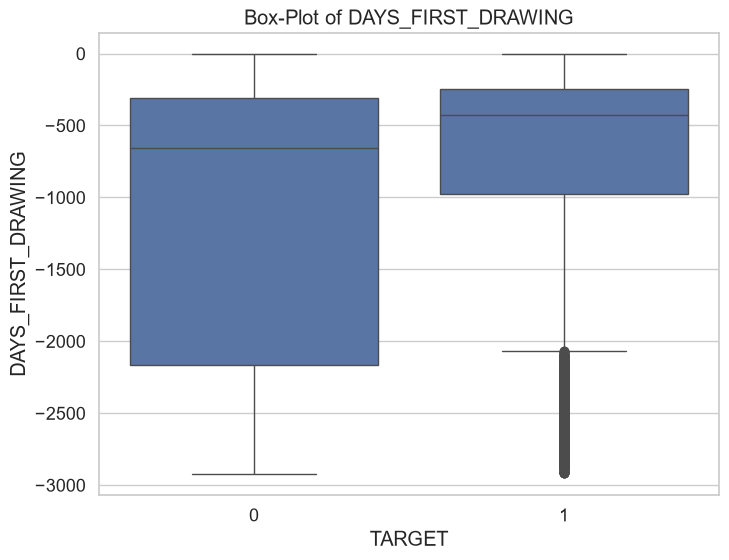

----------------------------------------------------------------------------------------------------


In [ ]:
print_percentiles(prev_merged, 'DAYS_FIRST_DRAWING', percentiles = list(range(0,11)) + list(range(20,101,20)))
plot_continuous_variables(prev_merged, 'DAYS_FIRST_DRAWING', plots = ['box'], figsize = (8,6), scale_limits = [-3000,0])
print('-'*100)

##### Quan sát và kết luận:

Nhiều giá trị DAYS_FIRST_DRAWING là bất hợp lý ngay từ phân vị 7% và cần được xử lý. Sau khi loại các điểm sai, nhóm vỡ nợ thường có lần giải ngân đầu tiên gần đây hơn; phân vị 75% cũng thấp hơn đáng kể.

<b>DAYS_FIRST_DUE, DAYS_LAST_DUE_1ST_VERSION, DAYS_LAST_DUE và DAYS_TERMINATION</b>

Các cột này cho biết một số sự kiện của khoản vay trước đây đã xảy ra cách hồ sơ hiện tại bao nhiêu ngày.

In [ ]:
print('-'*100)
print("Percentile Values for DAYS_FIRST_DUE")
print_percentiles(prev_merged, 'DAYS_FIRST_DUE', percentiles = list(range(0,11,2)) + [20,40,60,80,100])
print("Percentile Values for DAYS_LAST_DUE_1ST_VERSION")
print_percentiles(prev_merged, 'DAYS_LAST_DUE_1ST_VERSION', percentiles = list(range(0,11,2)) + [20,40,60,80,100])
print("Percentile Values for DAYS_LAST_DUE")
print_percentiles(prev_merged, 'DAYS_LAST_DUE', percentiles = list(range(0,11,2)) + [20,40,60,80,100])
print("Percentile Values for DAYS_TERMINATION")
print_percentiles(prev_merged, 'DAYS_TERMINATION', percentiles = list(range(0,11,2)) + [20,40,60,80,100])

----------------------------------------------------------------------------------------------------
Percentile Values for DAYS_FIRST_DUE
----------------------------------------------------------------------------------------------------
The 0th percentile value of DAYS_FIRST_DUE is -2892.0
The 2th percentile value of DAYS_FIRST_DUE is -2759.0
The 4th percentile value of DAYS_FIRST_DUE is -2648.0
The 6th percentile value of DAYS_FIRST_DUE is -2555.0
The 8th percentile value of DAYS_FIRST_DUE is -2471.0
The 10th percentile value of DAYS_FIRST_DUE is -2388.0
The 20th percentile value of DAYS_FIRST_DUE is -1882.0
The 40th percentile value of DAYS_FIRST_DUE is -1070.0
The 60th percentile value of DAYS_FIRST_DUE is -647.0
The 80th percentile value of DAYS_FIRST_DUE is -329.0
The 100th percentile value of DAYS_FIRST_DUE is 365243.0
----------------------------------------------------------------------------------------------------
Percentile Values for DAYS_LAST_DUE_1ST_VERSION
------------

##### Quan sát và kết luận

Các cột DAYS đều chứa một số giá trị bất hợp lý. Cần thay thế hoặc xử lý chúng để tránh ảnh hưởng tới mô hình.

### installments_payments.csv

##### Mô tả

Bảng này ghi lại lịch sử thanh toán của từng khoản vay trước đây tại Home Credit, gồm số tiền phải trả và số tiền khách hàng thực tế thanh toán cho mỗi kỳ.

<h4>Thống kê cơ bản</h4>

In [ ]:
print(f'The shape of installments_payments.csv is: {installments_payments.shape}')
print('-'*100)
print(f'Number of unique SK_ID_PREV in installments_payments.csv are: {len(installments_payments.SK_ID_PREV.unique())}')
print(f'Number of unique SK_ID_CURR in installments_payments.csv are: {len(installments_payments.SK_ID_CURR.unique())}')
print('-'*100)
print(f'Number of overlapping SK_ID_CURR in application_train.csv and installments_payments.csv are: {len(set(application_train.SK_ID_CURR.unique()).intersection(set(installments_payments.SK_ID_CURR.unique())))}')
print(f'Number of overlapping SK_ID_CURR in application_test.csv and installments_payments.csv are: {len(set(application_test.SK_ID_CURR.unique()).intersection(set(installments_payments.SK_ID_CURR.unique())))}')
print('-'*100)
print(f'Number of duplicate values in installments_payments: {installments_payments.shape[0] - installments_payments.duplicated().shape[0]}')
print('-'*100)
display(installments_payments.head(5))

The shape of installments_payments.csv is: (13605401, 8)
----------------------------------------------------------------------------------------------------
Number of unique SK_ID_PREV in installments_payments.csv are: 997752
Number of unique SK_ID_CURR in installments_payments.csv are: 339587
----------------------------------------------------------------------------------------------------
Number of overlapping SK_ID_CURR in application_train.csv and installments_payments.csv are: 291643
Number of overlapping SK_ID_CURR in application_test.csv and installments_payments.csv are: 47944
----------------------------------------------------------------------------------------------------
Number of duplicate values in installments_payments: 0
----------------------------------------------------------------------------------------------------


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000
3,2452527,199697,1.0,3,-2418.0,-2426.0,24350.130,24350.130
4,2714724,167756,1.0,2,-1383.0,-1366.0,2165.040,2160.585


##### Quan sát và kết luận

Bảng installments_payments.csv có khoảng 13,6 triệu dòng và 8 đặc trưng. Có 997 nghìn khoản vay trước đây thuộc 339 nghìn khách hàng hiện tại; 291 nghìn khách hàng thuộc tập huấn luyện và 47,9 nghìn thuộc tập kiểm tra. Phần lớn khách hàng trong hai tập từng có khoản vay tại Home Credit.

# ### Cột NaN và tỷ lệ phần trăm

In [ ]:
print('-'*100)
print("Columns with NaN values and their percentages:")
installments_payments_nan = nan_df_create(installments_payments)
display(installments_payments_nan[installments_payments_nan.percent != 0])
print('-'*100)
del installments_payments_nan

----------------------------------------------------------------------------------------------------
Columns with NaN values and their percentages:


,column,percent
7,AMT_PAYMENT,0.021352
5,DAYS_ENTRY_PAYMENT,0.021352


----------------------------------------------------------------------------------------------------


##### Quan sát và kết luận

Chỉ 2 trong 8 cột chứa NaN và tỷ lệ thiếu rất nhỏ, khoảng 0,02%, nên không đáng lo ngại.

<b>Ghép biến TARGET từ application_train vào bảng installments_payments.</b>

In [ ]:
print("-"*100)
print("Merging TARGET with installments_payments Table")
installments_merged = application_train.iloc[:,:2].merge(installments_payments, on = 'SK_ID_CURR', how = 'left')
print("-"*100)

----------------------------------------------------------------------------------------------------
Merging TARGET with installments_payments Table
----------------------------------------------------------------------------------------------------


# ### Ma trận tương quan của các tính năng

----------------------------------------------------------------------------------------------------


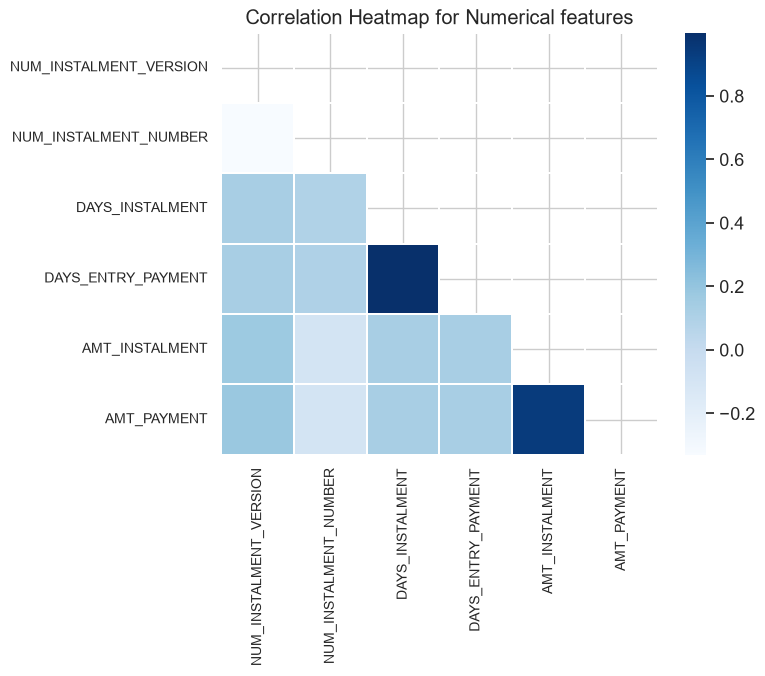

----------------------------------------------------------------------------------------------------


In [ ]:
corr_mat = correlation_matrix(installments_merged, ['SK_ID_CURR','SK_ID_PREV'], figsize = (8,7))
corr_mat.plot_correlation_matrix()

In [ ]:
#Seeing the top columns with highest phik-correlation with the target variable in installments_payments table
top_corr_target_df = corr_mat.target_top_corr()
print("-" * 100)
print("Columns with highest values of Phik-correlation with Target Variable are:")
display(top_corr_target_df)
print("-"*100)

interval columns not set, guessing: ['TARGET', 'NUM_INSTALMENT_VERSION']
interval columns not set, guessing: ['TARGET', 'NUM_INSTALMENT_NUMBER']
interval columns not set, guessing: ['TARGET', 'DAYS_INSTALMENT']
interval columns not set, guessing: ['TARGET', 'DAYS_ENTRY_PAYMENT']
interval columns not set, guessing: ['TARGET', 'AMT_INSTALMENT']
interval columns not set, guessing: ['TARGET', 'AMT_PAYMENT']
----------------------------------------------------------------------------------------------------
Columns with highest values of Phik-correlation with Target Variable are:


,Column Name,Phik-Correlation
3,DAYS_ENTRY_PAYMENT,0.047231
2,DAYS_INSTALMENT,0.046815
1,NUM_INSTALMENT_NUMBER,0.022993
4,AMT_INSTALMENT,0.004125
5,AMT_PAYMENT,0.003084
0,NUM_INSTALMENT_VERSION,0.002198


----------------------------------------------------------------------------------------------------


##### Quan sát và kết luận:

Hai cặp tương quan cao là AMT_INSTALMENT–AMT_PAYMENT và DAYS_INSTALMENT–DAYS_ENTRY_PAYMENT, tương ứng với số tiền/ngày đến hạn so với số tiền/ngày thực trả. Chúng hữu ích để tạo các đặc trưng mới ít tương quan hơn. Tương quan với TARGET không rõ rệt.

#### Trực quan hóa các biến liên tục

Trước tiên, nhóm dữ liệu theo SK_ID_PREV và lấy trung bình để thu được một dòng đại diện cho mỗi khoản vay trước đây.

In [ ]:
installments_merged = installments_merged.groupby('SK_ID_PREV').mean()

<b><u>Phân phối biến liên tục DAYS_INSTALMENT</u></b>

Cột này ghi lại ngày đến hạn của kỳ thanh toán cho khoản tín dụng trước đây.

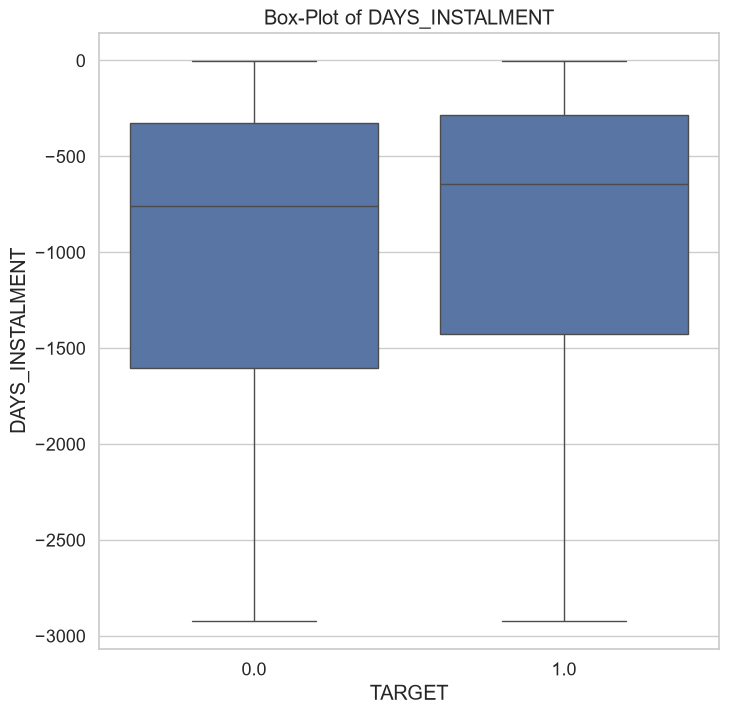

In [ ]:
plot_continuous_variables(installments_merged, 'DAYS_INSTALMENT', plots = ['box'], figsize = (8,8))

<b><u>Phân phối biến liên tục DAYS_ENTRY_PAYMENT</u></b>

Cột này ghi lại ngày khách hàng thực tế thanh toán kỳ trả nợ trước đây.

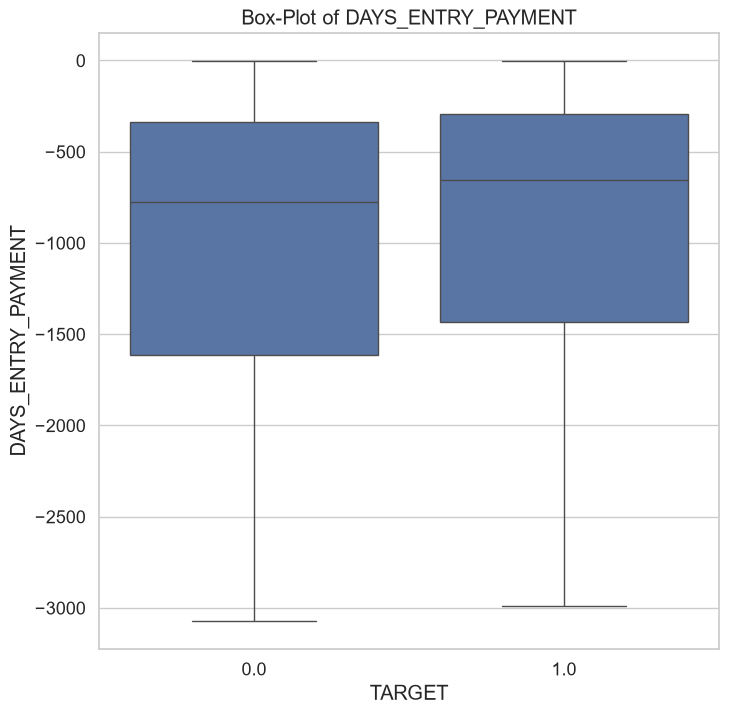

In [ ]:
plot_continuous_variables(installments_merged, 'DAYS_ENTRY_PAYMENT', plots = ['box'], figsize = (8,8))
del installments_merged

##### Quan sát và kết luận

Nhóm vỡ nợ có lần thanh toán gần nhất gần ngày đăng ký hơn ở mọi phân vị. Nhóm không vỡ nợ thường có khoảng cách từ lần thanh toán trước tới ngày đăng ký dài hơn.

### POS_CASH_balance.csv

##### Mô tả

Bảng này chứa ảnh chụp số dư hằng tháng của các khoản vay POS và vay tiền mặt trước đây, gồm trạng thái hợp đồng và số kỳ trả góp còn lại.

# ### Số liệu thống kê cơ bản

In [ ]:
print(f'The shape of POS_CASH_balance.csv is: {POS_CASH_balance.shape}')
print('-'*100)
print(f'Number of unique SK_ID_PREV in POS_CASH_balance.csv are: {len(POS_CASH_balance.SK_ID_PREV.unique())}')
print(f'Number of unique SK_ID_CURR in POS_CASH_balance.csv are: {len(POS_CASH_balance.SK_ID_CURR.unique())}')
print('-'*100)
print(f'Number of overlapping SK_ID_CURR in application_train.csv and POS_CASH_balance.csv are: {len(set(application_train.SK_ID_CURR.unique()).intersection(set(POS_CASH_balance.SK_ID_CURR.unique())))}')
print(f'Number of overlapping SK_ID_CURR in application_test.csv and POS_CASH_balance.csv are: {len(set(application_test.SK_ID_CURR.unique()).intersection(set(POS_CASH_balance.SK_ID_CURR.unique())))}')
print('-'*100)
print(f'Number of duplicate values in POS_CASH_balance: {POS_CASH_balance.shape[0] - POS_CASH_balance.duplicated().shape[0]}')
print('-'*100)
display(POS_CASH_balance.head())

The shape of POS_CASH_balance.csv is: (10001358, 8)
----------------------------------------------------------------------------------------------------
Number of unique SK_ID_PREV in POS_CASH_balance.csv are: 936325
Number of unique SK_ID_CURR in POS_CASH_balance.csv are: 337252
----------------------------------------------------------------------------------------------------
Number of overlapping SK_ID_CURR in application_train.csv and POS_CASH_balance.csv are: 289444
Number of overlapping SK_ID_CURR in application_test.csv and POS_CASH_balance.csv are: 47808
----------------------------------------------------------------------------------------------------
Number of duplicate values in POS_CASH_balance: 0
----------------------------------------------------------------------------------------------------


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


##### Quan sát và kết luận

Bảng có khoảng 10 triệu dòng và 8 cột, mỗi dòng là trạng thái theo tháng của một khoản vay POS hoặc tiền mặt trước đây. Có 936 nghìn khoản vay thuộc 337 nghìn khách hàng; 289 nghìn thuộc tập huấn luyện và 47,8 nghìn thuộc tập kiểm tra.

# ### Cột NaN và tỷ lệ phần trăm

In [ ]:
print('-'*100)
print("Columns with NaN values and their percentages:")
POS_CASH_nan = nan_df_create(POS_CASH_balance)
display(POS_CASH_nan[POS_CASH_nan.percent != 0])
print('-'*100)
del POS_CASH_nan

----------------------------------------------------------------------------------------------------
Columns with NaN values and their percentages:


,column,percent
4,CNT_INSTALMENT_FUTURE,0.260835
3,CNT_INSTALMENT,0.260675


----------------------------------------------------------------------------------------------------


##### Quan sát và kết luận

Chỉ 2 trong 8 cột chứa NaN: số kỳ trả góp còn lại và thời hạn khoản vay. Tỷ lệ thiếu chỉ khoảng 0,26%, nên không đáng lo ngại.

<b>Ghép biến TARGET từ application_train vào bảng POS_CASH_balance.</b>

In [ ]:
print("-"*100)
print("Merging TARGET with POS_CASH_balance Table")
pos_cash_merged = application_train.iloc[:,:2].merge(POS_CASH_balance, on = 'SK_ID_CURR', how = 'left')
print("-"*100)

----------------------------------------------------------------------------------------------------
Merging TARGET with POS_CASH_balance Table
----------------------------------------------------------------------------------------------------


# ### Ma trận tương quan của các tính năng

In [ ]:
corr_mat = correlation_matrix(pos_cash_merged, ['SK_ID_CURR','SK_ID_PREV'], figsize = (7,6))
corr_mat.plot_correlation_matrix()

----------------------------------------------------------------------------------------------------


ValueError: could not convert string to float: 'Active'

In [ ]:
#Seeing the top columns with highest phik-correlation with the target variable in POS_CASH_balance table
top_corr_target_df = corr_mat.target_top_corr()
print("-" * 100)
print("Columns with highest values of Phik-correlation with Target Variable are:")
display(top_corr_target_df)
print("-"*100)

##### Quan sát và kết luận:

CNT_INSTALMENT và CNT_INSTALMENT_FUTURE có tương quan vừa phải. Tương quan của các đặc trưng với TARGET rất thấp, cho thấy không có quan hệ tuyến tính rõ ràng.

#### Trực quan hóa các biến liên tục

Trước tiên, nhóm dữ liệu theo SK_ID_PREV và lấy trung bình để thu được một dòng đại diện cho mỗi khoản vay trước đây.

In [ ]:
pos_cash_merged = pos_cash_merged.groupby('SK_ID_PREV').mean()

<b><u>Phân phối biến liên tục CNT_INSTALMENT_FUTURE</u></b>

Cột này mô tả số kỳ trả góp còn lại của khoản tín dụng trước đây.

In [ ]:
plot_continuous_variables(pos_cash_merged, 'CNT_INSTALMENT_FUTURE', plots = ['box'], figsize = (8,8))
del pos_cash_merged

##### Quan sát và kết luận

Ở các phân vị trên 50%, CNT_INSTALMENT_FUTURE của nhóm vỡ nợ thường cao hơn nhóm không vỡ nợ; râu trên của box plot cũng cao hơn. Nhóm vỡ nợ có xu hướng còn nhiều kỳ phải trả hơn.

### credit_card_balance.csv

##### Mô tả

Bảng này chứa dữ liệu hằng tháng về một hoặc nhiều thẻ tín dụng trước đây của khách hàng tại Home Credit, gồm số dư, hạn mức, số tiền rút và các thông tin liên quan.

<h4>Thống kê cơ bản</h4>

In [ ]:
print(f'The shape of credit_card_balance.csv is: {cc_balance.shape}')
print('-'*100)
print(f'Number of unique SK_ID_PREV in credit_card_balance.csv are: {len(cc_balance.SK_ID_PREV.unique())}')
print(f'Number of unique SK_ID_CURR in credit_card_balance.csv are: {len(cc_balance.SK_ID_CURR.unique())}')
print('-'*100)
print(f'Number of overlapping SK_ID_CURR in application_train.csv and credit_card_balance.csv are: {len(set(application_train.SK_ID_CURR.unique()).intersection(set(cc_balance.SK_ID_CURR.unique())))}')
print(f'Number of overlapping SK_ID_CURR in application_test.csv and credit_card_balance.csv are: {len(set(application_test.SK_ID_CURR.unique()).intersection(set(cc_balance.SK_ID_CURR.unique())))}')
print('-'*100)

print(f'Number of duplicate values in credit_card_balance: {cc_balance.shape[0] - cc_balance.duplicated().shape[0]}')
print('-'*100)
display(cc_balance.head(5))

##### Quan sát và kết luận

Bảng credit_card_balance.csv có khoảng 3,84 triệu dòng và 23 đặc trưng. Có 104,3 nghìn thẻ thuộc 103,5 nghìn khách hàng, cho thấy phần lớn chỉ có một thẻ. Khoảng 86,9 nghìn khách hàng thuộc tập huấn luyện và 16,6 nghìn thuộc tập kiểm tra; chỉ 86,9 nghìn trong 307 nghìn khách hàng huấn luyện từng có thẻ tại Home Credit.

# ### Cột NaN và tỷ lệ phần trăm

In [ ]:
cc_balance_nan = nan_df_create(cc_balance)
print('-'*100)
plot_nan_percent(cc_balance_nan, 'credit_card_balance', tight_layout = False, rotation = 90, figsize = (14,5))
print('-'*100)
del cc_balance_nan

##### Quan sát và kết luận

Trong 23 đặc trưng có 9 cột chứa NaN. Bảy cột có tỷ lệ thiếu gần 20%, chủ yếu liên quan đến số tiền và số lần rút; hai cột còn lại liên quan đến thống kê trả góp.

<b>Ghép biến TARGET từ application_train vào bảng credit_card_balance.</b>

In [ ]:
print("-"*100)
print("Merging TARGET with credit_card_balance Table")
cc_balance_merged = application_train.iloc[:,:2].merge(cc_balance, on = 'SK_ID_CURR', how = 'left')
print("-"*100)

# ### Ma trận tương quan của các tính năng

In [ ]:
corr_mat = correlation_matrix(cc_balance_merged, ['SK_ID_CURR','SK_ID_PREV'], figsize = (13,11))
corr_mat.plot_correlation_matrix()

In [ ]:
#Seeing the top columns with highest phik-correlation with the target variable in credit_card_balance table
top_corr_target_df = corr_mat.target_top_corr()
print("-" * 100)
print("Columns with highest values of Phik-correlation with Target Variable are:")
display(top_corr_target_df)
print("-" * 100)

##### Quan sát và kết luận:

Các nhóm tương quan cao gồm AMT_RECEIVABLE_PRINCIPAL, AMT_RECIVABLE, AMT_TOTAL_RECEIVABLE và AMT_BALANCE; ngoài ra AMT_PAYMENT_TOTAL_CURRENT tương quan cao với AMT_PAYMENT_CURRENT. Đây là các đại lượng gần cùng bản chất. Tương quan với TARGET không đáng kể.

#### Trực quan hóa các biến liên tục

Trước tiên, nhóm dữ liệu theo SK_ID_PREV và lấy trung bình để thu được một dòng đại diện cho mỗi khoản vay trước đây.

In [ ]:
cc_balance_merged = cc_balance_merged.groupby('SK_ID_PREV').mean()

NameError: name 'cc_balance_merged' is not defined

<b><u>Phân phối biến liên tục AMT_BALANCE</u></b>

Cột này biểu thị số dư trung bình mà khách hàng thường có trên tài khoản thẻ tín dụng trước đây.

In [ ]:
plot_continuous_variables(cc_balance_merged, 'AMT_BALANCE', plots = ['box'], figsize = (8,8))

##### Quan sát và kết luận

Nhóm vỡ nợ có AMT_BALANCE cao hơn ở tất cả các phân vị và cả hai râu của box plot. Điều này có thể liên quan tới hạn mức hoặc số tiền tín dụng cao hơn.

##### Quan sát và kết luận:

Nhóm vỡ nợ cũng có khoản trả góp tối thiểu hằng tháng cao hơn, phản ánh xu hướng chi tiêu và vay mượn nhiều hơn nhóm không vỡ nợ.

<b><u>Phân phối biến liên tục AMT_TOTAL_RECEIVABLE</u></b>

Cột này mô tả tổng số tiền phải thu trung bình của khoản tín dụng trước đây.

In [ ]:
plot_continuous_variables(cc_balance_merged, 'AMT_TOTAL_RECEIVABLE', plots = ['violin'], figsize = (8,8))

##### Quan sát và kết luận

Nhóm vỡ nợ thường có tổng số tiền phải thu cao hơn, có thể do từng vay số tiền lớn hơn. Hàm mật độ của nhóm không vỡ nợ đạt đỉnh cao hơn nhiều ở vùng giá trị thấp.

<b><u>Phân phối biến liên tục CNT_INSTALMENT_MATURE_CUM</u></b>

Cột này mô tả số kỳ trả góp trung bình đã thanh toán của các khoản tín dụng trước đây.

In [ ]:
plot_continuous_variables(cc_balance_merged, 'CNT_INSTALMENT_MATURE_CUM', plots = ['box'], figsize = (8,8))

NameError: name 'cc_balance_merged' is not defined

##### Quan sát và kết luận

Nhóm không vỡ nợ thường có phạm vi số kỳ đã thanh toán cao hơn. Điều này có thể phản ánh hành vi vỡ nợ: khách hàng vỡ nợ thường thanh toán ít kỳ hơn cho khoản tín dụng trước đây.

## Kết luận từ EDA

Từ quá trình Phân tích Dữ liệu Khám phá (Exploratory Data Analysis – EDA) toàn diện đã thực hiện, chúng ta có thể rút ra một số kết luận tổng quan về bộ dữ liệu như sau:

1. Trước tiên, toàn bộ các bảng dữ liệu cần được kết hợp (merge) với nhau theo một phương pháp phù hợp để dữ liệu sau khi merge vẫn có ý nghĩa và phản ánh đúng cấu trúc của dữ liệu gốc.

2. Một số nhóm giá trị của các biến phân loại có khả năng phân biệt khá tốt giữa nhóm khách hàng Default và Non-Default. Những biến này có thể đóng vai trò quan trọng đối với bài toán phân loại.

3. Có một số biến số liên tục (Continuous Numerical Variables) chứa các điểm dữ liệu sai hoặc bất hợp lý (erroneous points). Chúng ta cần có phương pháp phù hợp để xử lý những giá trị này.

4. Chúng ta cũng phát hiện một số đặc trưng có tương quan cao với nhau. Những đặc trưng này có thể làm tăng số chiều của dữ liệu mà không bổ sung nhiều thông tin mới. Vì vậy, chúng ta có thể cân nhắc loại bỏ các đặc trưng dư thừa này.

5. Nhìn chung, bộ dữ liệu bị mất cân bằng lớp (imbalanced), do đó cần áp dụng các kỹ thuật phù hợp để xử lý tình trạng mất cân bằng này.

6. Trong bài toán dự đoán rủi ro vỡ nợ (Default Risk Prediction), các khách hàng Default thường có thể biểu hiện những hành vi bất thường so với phần lớn khách hàng. Vì vậy, chúng ta không thể tự động loại bỏ các outlier hoặc những điểm dữ liệu nằm xa phần lớn dữ liệu, bởi chúng có thể chứa những tín hiệu quan trọng liên quan đến xu hướng Default.

7. Dựa trên tất cả những insight thu được, bước tiếp theo sẽ là Làm sạch Dữ liệu (Data Cleaning) và Kỹ thuật Đặc trưng (Feature Engineering).
